In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
3D MLPA TUMOR GROWTH SIMULATION - LUNG1 REAL DATA ONLY
================================================================================
Mô phỏng sự phát triển khối u trong phổi bệnh nhân sử dụng:
- CT volume thực từ DICOM
- Tumor mask thực từ DICOM Segmentation
- Lung boundary từ CT thresholding

Đặc điểm:
- Khối u ban đầu là tế bào u thường (chưa chuyển hóa thành ung thư)
- Tumor phát triển theo 26-neighborhood
- Giới hạn phát triển trong phạm vi phổi bệnh nhân

Author: Paul Nguyen
"""

import numpy as np
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from scipy import ndimage
from scipy.ndimage import gaussian_filter, binary_dilation, binary_erosion, label
from skimage import measure
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import plotly.graph_objects as go

# ============================================================================
# CẤU HÌNH - THAY ĐỔI CÁC GIÁ TRỊ NÀY THEO MÁY CỦA BẠN
# ============================================================================

# Đường dẫn LUNG1 dataset
LUNG1_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")

# Thư mục output
OUTPUT_DIR = Path("./lung1_mlpa_output")

# Patient ID cụ thể (None = chọn patient đầu tiên)
SELECTED_PATIENT_ID = None  # Ví dụ: "LUNG1-001"

# MLPA Parameters
MLPA_CONFIG = {
    'grid_size': 100,           # Kích thước grid cho simulation
    'num_iterations': 100,      # Số iterations
    'alpha': 0.08,              # Growth rate (tốc độ tăng trưởng)
    'beta': 0.05,               # Invasion potential (khả năng xâm lấn)
    'gamma': 0.9,               # Resistance factor
    'mutation_chance': 0.002,   # Xác suất đột biến thành ung thư
    'necrosis_chance': 0.015,   # Xác suất hoại tử ở vùng lõi
    'neighborhood_26': True,    # Sử dụng 26 neighbors
}

# ============================================================================
# CELL STATES & COLORMAP
# ============================================================================

CELL_STATES = {
    0: 'Background (ngoài phổi)',
    1: 'Normal Lung Tissue (mô phổi bình thường)',
    2: 'Tumor (tế bào u thường)',
    3: 'Necrotic (hoại tử)',
    4: 'Proliferating (đang phân chia)',
    5: 'Quiescent (nghỉ ngơi)',
    6: 'Malignant (ung thư - đã đột biến)'
}

CELL_CMAP = ListedColormap([
    (0.1, 0.1, 0.1),    # 0: Background (đen)
    (0.9, 0.85, 0.8),   # 1: Normal lung (be nhạt)
    (0.0, 0.0, 1.0),    # 2: Tumor (xanh dương)
    (0.4, 0.4, 0.4),    # 3: Necrotic (xám)
    (1.0, 0.0, 0.0),    # 4: Proliferating (đỏ)
    (0.5, 0.7, 1.0),    # 5: Quiescent (xanh nhạt)
    (0.8, 0.0, 0.8),    # 6: Malignant (tím)
])


# ============================================================================
# DICOM DATA LOADING
# ============================================================================

def scan_lung1_patients(data_root: Path, max_patients: int = None) -> List[Dict]:
    """Scan LUNG1 dataset để tìm patients có cả CT và segmentation."""
    if not data_root.exists():
        raise FileNotFoundError(f"Data root không tồn tại: {data_root}")
    
    patients = {}
    
    for patient_dir in sorted(data_root.glob("LUNG1-*")):
        if not patient_dir.is_dir():
            continue
        
        patient_id = patient_dir.name
        
        for study_dir in patient_dir.glob("*"):
            if not study_dir.is_dir():
                continue
            
            subdirs = [d for d in study_dir.iterdir() if d.is_dir()]
            seg_dirs = [d for d in subdirs if d.name.startswith("300.")]
            
            ct_dirs = []
            for d in subdirs:
                if d.name.startswith("300."):
                    continue
                dcm_count = len(list(d.glob("*.dcm")))
                if dcm_count >= 10:
                    ct_dirs.append((d, dcm_count))
            
            if ct_dirs and seg_dirs:
                ct_dir = max(ct_dirs, key=lambda x: x[1])[0]
                seg_files = list(seg_dirs[0].glob("*.dcm"))
                
                if seg_files:
                    patient_info = {
                        'patient_id': patient_id,
                        'ct_dir': str(ct_dir),
                        'seg_file': str(seg_files[0]),
                        'n_slices': max(ct_dirs, key=lambda x: x[1])[1]
                    }
                    
                    if patient_id not in patients or \
                       patient_info['n_slices'] > patients[patient_id]['n_slices']:
                        patients[patient_id] = patient_info
    
    result = list(patients.values())
    if max_patients:
        result = result[:max_patients]
    
    if len(result) == 0:
        raise ValueError(f"Không tìm thấy patient nào trong {data_root}")
    
    return result


def load_ct_volume(ct_dir: str) -> Tuple[np.ndarray, Tuple[float, float, float], List]:
    """Load CT volume từ DICOM files."""
    ct_path = Path(ct_dir)
    dcm_files = sorted(ct_path.glob("*.dcm"))
    
    if not dcm_files:
        raise FileNotFoundError(f"Không tìm thấy DICOM files trong {ct_dir}")
    
    slices = []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(str(f))
            if hasattr(ds, 'ImagePositionPatient') and hasattr(ds, 'pixel_array'):
                slices.append(ds)
        except Exception:
            continue
    
    if len(slices) == 0:
        raise ValueError("Không tìm thấy CT slice hợp lệ")
    
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    volume = np.stack([s.pixel_array for s in slices])
    
    if hasattr(slices[0], 'RescaleSlope') and hasattr(slices[0], 'RescaleIntercept'):
        slope = float(slices[0].RescaleSlope)
        intercept = float(slices[0].RescaleIntercept)
        volume = volume * slope + intercept
    
    pixel_spacing = [float(x) for x in slices[0].PixelSpacing]
    if len(slices) > 1:
        z_spacing = abs(float(slices[1].ImagePositionPatient[2]) - 
                       float(slices[0].ImagePositionPatient[2]))
    else:
        z_spacing = float(getattr(slices[0], 'SliceThickness', 1.0))
    
    spacing = (z_spacing, pixel_spacing[0], pixel_spacing[1])
    
    return volume.astype(np.float32), spacing, slices


def load_tumor_mask(seg_file: str, ct_slices: List) -> np.ndarray:
    """Load tumor segmentation từ DICOM SEG file."""
    seg_ds = pydicom.dcmread(str(seg_file))
    
    sop_to_index = {}
    for idx, ds in enumerate(ct_slices):
        sop_to_index[ds.SOPInstanceUID] = idx
    
    tumor_seg_num = 2
    if hasattr(seg_ds, 'SegmentSequence'):
        for seg in seg_ds.SegmentSequence:
            seg_num = int(seg.SegmentNumber)
            label_name = getattr(seg, 'SegmentLabel', "")
            if 'neoplasm' in label_name.lower() or 'primary' in label_name.lower():
                tumor_seg_num = seg_num
                break
    
    frames = seg_ds.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]
    
    num_slices = len(ct_slices)
    rows = int(ct_slices[0].Rows)
    cols = int(ct_slices[0].Columns)
    mask_vol = np.zeros((num_slices, rows, cols), dtype=np.uint8)
    
    if hasattr(seg_ds, 'PerFrameFunctionalGroupsSequence'):
        pffg = seg_ds.PerFrameFunctionalGroupsSequence
        
        for frame_idx in range(frames.shape[0]):
            try:
                seg_id_seq = pffg[frame_idx].SegmentIdentificationSequence[0]
                frame_seg_num = int(seg_id_seq.ReferencedSegmentNumber)
                
                if frame_seg_num != tumor_seg_num:
                    continue
                
                dseq = pffg[frame_idx].DerivationImageSequence[0]
                src = dseq.SourceImageSequence[0]
                ref_uid = src.ReferencedSOPInstanceUID
                
                if ref_uid in sop_to_index:
                    z = sop_to_index[ref_uid]
                    mask_vol[z] = np.maximum(mask_vol[z], 
                                            (frames[frame_idx] > 0).astype(np.uint8))
            except (AttributeError, IndexError):
                continue
    
    tumor_voxels = np.sum(mask_vol > 0)
    if tumor_voxels == 0:
        raise ValueError("Không tìm thấy tumor trong segmentation file")
    
    return mask_vol


def extract_lung_region(ct_volume: np.ndarray) -> np.ndarray:
    """Extract vùng phổi từ CT volume sử dụng HU thresholding."""
    lung_mask = (ct_volume < -400) & (ct_volume > -1000)
    
    for z in range(lung_mask.shape[0]):
        lung_mask[z] = ndimage.binary_fill_holes(lung_mask[z])
    
    labeled, num_features = ndimage.label(lung_mask)
    
    if num_features > 0:
        sizes = ndimage.sum(lung_mask, labeled, range(1, num_features + 1))
        
        if len(sizes) >= 2:
            largest_indices = np.argsort(sizes)[-2:]
            lung_mask = np.isin(labeled, largest_indices + 1)
        elif len(sizes) == 1:
            lung_mask = labeled == (np.argmax(sizes) + 1)
    
    struct = ndimage.generate_binary_structure(3, 1)
    lung_mask = binary_dilation(lung_mask, structure=struct, iterations=2)
    
    return lung_mask.astype(np.uint8)


# ============================================================================
# 3D VISUALIZATION
# ============================================================================

def create_3d_mesh(mask: np.ndarray, spacing: Tuple[float, float, float], 
                   step_size: int = 2) -> Optional[Dict]:
    """Tạo mesh từ binary mask sử dụng marching cubes."""
    try:
        verts, faces, _, _ = measure.marching_cubes(
            mask.astype(float), level=0.5, step_size=step_size
        )
        verts_scaled = verts * np.array(spacing)
        return {'vertices': verts_scaled, 'faces': faces}
    except Exception as e:
        print(f"  ⚠️ Marching cubes error: {e}")
        return None


def visualize_lung_and_tumor_3d(lung_mask: np.ndarray, tumor_mask: np.ndarray,
                                 spacing: Tuple[float, float, float],
                                 patient_id: str, output_dir: Path) -> go.Figure:
    """Visualize phổi và khối u trong không gian 3D."""
    print("  Tạo 3D meshes...")
    
    traces = []
    
    lung_mesh = create_3d_mesh(lung_mask, spacing, step_size=4)
    if lung_mesh:
        traces.append(go.Mesh3d(
            x=lung_mesh['vertices'][:, 0],
            y=lung_mesh['vertices'][:, 1],
            z=lung_mesh['vertices'][:, 2],
            i=lung_mesh['faces'][:, 0],
            j=lung_mesh['faces'][:, 1],
            k=lung_mesh['faces'][:, 2],
            color='lightblue',
            opacity=0.15,
            name='Phổi',
            lighting=dict(ambient=0.5, diffuse=0.8),
            lightposition=dict(x=100, y=200, z=300)
        ))
        print(f"    ✅ Lung mesh: {len(lung_mesh['vertices'])} vertices")
    
    tumor_mesh = create_3d_mesh(tumor_mask, spacing, step_size=2)
    if tumor_mesh:
        traces.append(go.Mesh3d(
            x=tumor_mesh['vertices'][:, 0],
            y=tumor_mesh['vertices'][:, 1],
            z=tumor_mesh['vertices'][:, 2],
            i=tumor_mesh['faces'][:, 0],
            j=tumor_mesh['faces'][:, 1],
            k=tumor_mesh['faces'][:, 2],
            color='red',
            opacity=0.9,
            name='Khối u',
            lighting=dict(ambient=0.5, diffuse=0.8, specular=0.3),
            lightposition=dict(x=100, y=200, z=300)
        ))
        print(f"    ✅ Tumor mesh: {len(tumor_mesh['vertices'])} vertices")
    
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=f"{patient_id} - Phổi và Khối u 3D (trạng thái ban đầu)",
        scene=dict(
            xaxis_title='Z (mm)',
            yaxis_title='Y (mm)',
            zaxis_title='X (mm)',
            aspectmode='data'
        ),
        width=900, height=800,
        showlegend=True
    )
    
    html_path = output_dir / f"{patient_id}_lung_tumor_initial.html"
    fig.write_html(str(html_path), include_plotlyjs=True)
    print(f"    ✅ Saved: {html_path}")
    
    return fig


# ============================================================================
# MLPA 3D SIMULATION ENGINE
# ============================================================================

class MLPA3DSimulator:
    """
    Multi-scale Lattice-based Proliferation Automaton (MLPA) 3D
    
    Đặc điểm:
    - Khối u ban đầu là tế bào u thường (state=2), chưa phải ung thư
    - Có thể đột biến thành tế bào ung thư (malignant, state=6)
    - Growth theo 26-neighborhood (tất cả 26 tế bào xung quanh)
    - Giới hạn phát triển TRONG PHẠM VI PHỔI
    """
    
    def __init__(self, config: Dict):
        self.config = config
        self.grid_size = config['grid_size']
        self.num_iterations = config['num_iterations']
        self.alpha = config['alpha']
        self.beta = config['beta']
        self.gamma = config['gamma']
        self.mutation_chance = config['mutation_chance']
        self.necrosis_chance = config['necrosis_chance']
        self.use_26_neighbors = config['neighborhood_26']
        
        # 26-neighborhood offsets
        self.neighborhood_26 = []
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                for dz in [-1, 0, 1]:
                    if dx == 0 and dy == 0 and dz == 0:
                        continue
                    self.neighborhood_26.append((dx, dy, dz))
        self.neighborhood_26 = np.array(self.neighborhood_26, dtype=int)
    
    def resample_to_grid(self, mask: np.ndarray) -> np.ndarray:
        """Resample mask về kích thước grid simulation."""
        from scipy.ndimage import zoom
        scale = [self.grid_size / s for s in mask.shape]
        resampled = zoom(mask.astype(float), scale, order=0)
        return (resampled > 0.5).astype(np.uint8)
    
    def initialize_grid(self, lung_mask: np.ndarray, tumor_mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Khởi tạo CA grid:
        - 0: Background (ngoài phổi)
        - 1: Normal lung tissue (mô phổi bình thường)
        - 2: Tumor cells (tế bào u thường - CHƯA PHẢI UNG THƯ)
        """
        lung_resampled = self.resample_to_grid(lung_mask)
        tumor_resampled = self.resample_to_grid(tumor_mask)
        
        grid = np.zeros((self.grid_size, self.grid_size, self.grid_size), dtype=np.int8)
        grid[lung_resampled > 0] = 1
        grid[tumor_resampled > 0] = 2  # Tế bào u thường
        
        return grid, lung_resampled
    
    def create_microenvironment(self, ct_volume: np.ndarray, seed: int = 42) -> np.ndarray:
        """Tạo microenvironment map từ CT values."""
        from scipy.ndimage import zoom
        np.random.seed(seed)
        
        scale = [self.grid_size / s for s in ct_volume.shape]
        ct_resampled = zoom(ct_volume, scale, order=1)
        
        ct_norm = np.clip(ct_resampled, -1000, 400)
        ct_norm = (ct_norm + 1000) / 1400
        microenv = 0.5 + ct_norm * 0.5
        
        return microenv.astype(np.float32)
    
    def get_boundary_cells(self, grid: np.ndarray, lung_mask: np.ndarray) -> np.ndarray:
        """Tìm boundary cells: tế bào phổi bình thường kề với tumor."""
        tumor_mask = (grid == 2) | (grid == 4) | (grid == 6)
        
        if self.use_26_neighbors:
            struct = ndimage.generate_binary_structure(3, 3)
        else:
            struct = ndimage.generate_binary_structure(3, 1)
        
        dilated = binary_dilation(tumor_mask, structure=struct)
        boundary = dilated & (grid == 1) & (lung_mask > 0)
        
        return boundary
    
    def run_simulation(self, lung_mask: np.ndarray, tumor_mask: np.ndarray,
                       ct_volume: np.ndarray, seed: int = 42) -> Dict:
        """Chạy MLPA simulation."""
        np.random.seed(seed)
        
        print(f"\n🔄 Bắt đầu MLPA Simulation...")
        print(f"   Grid size: {self.grid_size}³")
        print(f"   Iterations: {self.num_iterations}")
        print(f"   Neighborhood: {'26-connected' if self.use_26_neighbors else '6-connected'}")
        
        grid, lung_resampled = self.initialize_grid(lung_mask, tumor_mask)
        microenv = self.create_microenvironment(ct_volume, seed)
        
        initial_tumor = np.sum((grid == 2) | (grid == 4) | (grid == 6))
        lung_volume = np.sum(lung_resampled > 0)
        
        print(f"   Tumor ban đầu: {initial_tumor} cells (tế bào u thường)")
        print(f"   Phổi volume: {lung_volume} cells")
        
        trajectory = {
            'iteration': [],
            'tumor_count': [],
            'proliferating_count': [],
            'malignant_count': [],
            'necrotic_count': []
        }
        
        snapshots = []
        snapshot_iters = [0, 10, 25, 50, 75, self.num_iterations - 1]
        
        for it in range(self.num_iterations):
            
            if it % 5 == 0 or it in snapshot_iters:
                tumor_cells = np.sum((grid == 2) | (grid == 4) | (grid == 6))
                prolif_cells = np.sum(grid == 4)
                malignant_cells = np.sum(grid == 6)
                necrotic_cells = np.sum(grid == 3)
                
                trajectory['iteration'].append(it)
                trajectory['tumor_count'].append(int(tumor_cells))
                trajectory['proliferating_count'].append(int(prolif_cells))
                trajectory['malignant_count'].append(int(malignant_cells))
                trajectory['necrotic_count'].append(int(necrotic_cells))
            
            if it in snapshot_iters:
                snapshots.append({'iteration': it, 'grid': grid.copy()})
            
            new_grid = grid.copy()
            
            # Rule 1: PROLIFERATION
            boundary = self.get_boundary_cells(grid, lung_resampled)
            boundary_coords = np.argwhere(boundary)
            
            if len(boundary_coords) > 0:
                n_boundary = len(boundary_coords)
                expected_growth = self.alpha * self.gamma * n_boundary * 0.1
                n_new_tumor = max(1, int(expected_growth))
                n_new_tumor = min(n_new_tumor, n_boundary)
                
                weights = np.array([microenv[tuple(c)] for c in boundary_coords])
                weights = weights / (weights.sum() + 1e-8)
                
                grow_indices = np.random.choice(
                    len(boundary_coords), size=n_new_tumor, replace=False, p=weights
                )
                
                for idx in grow_indices:
                    coord = tuple(boundary_coords[idx])
                    new_grid[coord] = 4
            
            # Rule 2: INVASION (26-neighbor)
            if self.beta > 0.01 and it % 3 == 0 and self.use_26_neighbors:
                tumor_current = (grid == 2) | (grid == 4) | (grid == 6)
                
                struct_26 = ndimage.generate_binary_structure(3, 3)
                extended = binary_dilation(tumor_current, structure=struct_26, iterations=2)
                
                invasion_candidates = extended & (grid == 1) & (lung_resampled > 0) & (~boundary)
                
                if invasion_candidates.any():
                    inv_coords = np.argwhere(invasion_candidates)
                    inv_prob = self.beta * self.gamma
                    n_invasion = max(1, int(inv_prob * len(inv_coords) * 0.05))
                    n_invasion = min(n_invasion, len(inv_coords), 10)
                    
                    inv_weights = np.array([microenv[tuple(c)] for c in inv_coords])
                    inv_weights = inv_weights / (inv_weights.sum() + 1e-8)
                    
                    inv_selected = np.random.choice(
                        len(inv_coords), size=n_invasion, replace=False, p=inv_weights
                    )
                    
                    for idx in inv_selected:
                        coord = tuple(inv_coords[idx])
                        new_grid[coord] = 2
            
            # Rule 3: MUTATION (u thường -> ung thư)
            tumor_cells_mask = (grid == 2) | (grid == 4)
            mutation_rand = np.random.rand(*grid.shape)
            mutate_mask = tumor_cells_mask & (mutation_rand < self.mutation_chance)
            new_grid[mutate_mask] = 6
            
            # Rule 4: STATE TRANSITIONS
            prolif_mask = grid == 4
            transition_rand = np.random.rand(*grid.shape)
            transition_mask = prolif_mask & (transition_rand < 0.15)
            new_grid[transition_mask] = 2
            
            # Rule 5: NECROSIS
            if it > 20:
                tumor_current = (grid == 2) | (grid == 4) | (grid == 6)
                eroded = binary_erosion(tumor_current, iterations=2)
                
                necrosis_rand = np.random.rand(*grid.shape)
                necrosis_mask = eroded & (grid == 2) & (necrosis_rand < self.necrosis_chance)
                new_grid[necrosis_mask] = 3
            
            grid = new_grid
            
            if (it + 1) % 20 == 0:
                current_tumor = np.sum((grid == 2) | (grid == 4) | (grid == 6))
                current_malignant = np.sum(grid == 6)
                print(f"   Iteration {it + 1}: {current_tumor} tumor cells ({current_malignant} malignant)")
            
            tumor_volume = np.sum((grid == 2) | (grid == 4) | (grid == 6))
            if tumor_volume > lung_volume * 0.8:
                print(f"   ⚠️ Tumor đạt 80% phổi, dừng simulation")
                break
        
        final_tumor = np.sum((grid == 2) | (grid == 4) | (grid == 6))
        final_malignant = np.sum(grid == 6)
        volume_ratio = final_tumor / (initial_tumor + 1)
        
        print(f"\n✅ Simulation hoàn thành!")
        print(f"   Tumor cuối: {final_tumor} cells")
        print(f"   Malignant (ung thư): {final_malignant} cells")
        print(f"   Tỉ lệ tăng trưởng: {volume_ratio:.2f}x")
        
        return {
            'final_grid': grid,
            'lung_mask': lung_resampled,
            'trajectory': trajectory,
            'snapshots': snapshots,
            'initial_tumor': initial_tumor,
            'final_tumor': final_tumor,
            'final_malignant': final_malignant,
            'volume_ratio': volume_ratio
        }


# ============================================================================
# RESULT VISUALIZATION
# ============================================================================

def visualize_simulation_3d(result: Dict, patient_id: str, output_dir: Path) -> go.Figure:
    """Visualize kết quả simulation trong 3D."""
    grid = result['final_grid']
    lung_mask = result['lung_mask']
    grid_size = grid.shape[0]
    
    print("\n🎨 Tạo 3D visualization kết quả...")
    
    traces = []
    
    lung_coords = np.argwhere(lung_mask > 0)[::15]
    if len(lung_coords) > 0:
        traces.append(go.Scatter3d(
            x=lung_coords[:, 0], y=lung_coords[:, 1], z=lung_coords[:, 2],
            mode='markers',
            marker=dict(size=1, color='lightblue', opacity=0.03),
            name='Phổi'
        ))
    
    tumor_coords = np.argwhere(grid == 2)[::2]
    if len(tumor_coords) > 0:
        traces.append(go.Scatter3d(
            x=tumor_coords[:, 0], y=tumor_coords[:, 1], z=tumor_coords[:, 2],
            mode='markers',
            marker=dict(size=2, color='blue', opacity=0.7),
            name='Tumor (u thường)'
        ))
    
    prolif_coords = np.argwhere(grid == 4)
    if len(prolif_coords) > 0:
        traces.append(go.Scatter3d(
            x=prolif_coords[:, 0], y=prolif_coords[:, 1], z=prolif_coords[:, 2],
            mode='markers',
            marker=dict(size=3, color='red', opacity=0.9),
            name='Proliferating'
        ))
    
    malignant_coords = np.argwhere(grid == 6)
    if len(malignant_coords) > 0:
        traces.append(go.Scatter3d(
            x=malignant_coords[:, 0], y=malignant_coords[:, 1], z=malignant_coords[:, 2],
            mode='markers',
            marker=dict(size=3, color='purple', opacity=0.9),
            name='Malignant (ung thư)'
        ))
    
    necrotic_coords = np.argwhere(grid == 3)
    if len(necrotic_coords) > 0:
        traces.append(go.Scatter3d(
            x=necrotic_coords[:, 0], y=necrotic_coords[:, 1], z=necrotic_coords[:, 2],
            mode='markers',
            marker=dict(size=2, color='gray', opacity=0.5),
            name='Necrotic (hoại tử)'
        ))
    
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=f"{patient_id} - Kết quả MLPA Simulation",
        scene=dict(
            xaxis=dict(title='Z', range=[0, grid_size]),
            yaxis=dict(title='Y', range=[0, grid_size]),
            zaxis=dict(title='X', range=[0, grid_size]),
            aspectmode='cube'
        ),
        width=900, height=800,
        showlegend=True
    )
    
    html_path = output_dir / f"{patient_id}_mlpa_result.html"
    fig.write_html(str(html_path), include_plotlyjs=True)
    print(f"✅ Saved: {html_path}")
    
    return fig


def visualize_growth_trajectory(result: Dict, patient_id: str, output_dir: Path):
    """Vẽ đồ thị tăng trưởng tumor theo thời gian."""
    traj = result['trajectory']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    ax.plot(traj['iteration'], traj['tumor_count'], 'b-', lw=2, label='Tổng Tumor')
    ax.plot(traj['iteration'], traj['proliferating_count'], 'r--', lw=1.5, label='Proliferating')
    ax.plot(traj['iteration'], traj['malignant_count'], 'm:', lw=2, label='Malignant (ung thư)')
    ax.plot(traj['iteration'], traj['necrotic_count'], 'gray', lw=1.5, label='Necrotic')
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Số tế bào')
    ax.set_title(f'{patient_id} - Quá trình phát triển khối u')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    initial = result['initial_tumor']
    if initial > 0:
        volume_ratios = np.array(traj['tumor_count']) / initial
        ax2.plot(traj['iteration'], volume_ratios, 'g-', lw=2)
        ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Tỉ lệ thể tích (so với ban đầu)')
    ax2.set_title(f'{patient_id} - Tỉ lệ tăng trưởng')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    png_path = output_dir / f"{patient_id}_growth_trajectory.png"
    plt.savefig(str(png_path), dpi=150)
    plt.close()
    print(f"✅ Saved: {png_path}")


def visualize_snapshots_2d(result: Dict, patient_id: str, output_dir: Path):
    """Vẽ 2D slices tại các thời điểm khác nhau."""
    snapshots = result['snapshots']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, snapshot in enumerate(snapshots[:6]):
        grid = snapshot['grid']
        iteration = snapshot['iteration']
        
        z_mid = grid.shape[0] // 2
        slice_data = grid[z_mid]
        
        ax = axes[idx]
        ax.imshow(slice_data, origin='lower', cmap=CELL_CMAP, vmin=0, vmax=6)
        ax.set_title(f'Iteration {iteration}')
        ax.axis('off')
        
        tumor_count = np.sum((grid == 2) | (grid == 4) | (grid == 6))
        malignant_count = np.sum(grid == 6)
        ax.text(0.02, 0.98, f'Tumor: {tumor_count}\nMalignant: {malignant_count}', 
                transform=ax.transAxes, fontsize=9, va='top', color='white',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=CELL_CMAP(0), label='Background'),
        Patch(facecolor=CELL_CMAP(1), label='Lung'),
        Patch(facecolor=CELL_CMAP(2), label='Tumor (u thường)'),
        Patch(facecolor=CELL_CMAP(3), label='Necrotic'),
        Patch(facecolor=CELL_CMAP(4), label='Proliferating'),
        Patch(facecolor=CELL_CMAP(6), label='Malignant (ung thư)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=10)
    
    plt.suptitle(f'{patient_id} - Snapshots (Central Slice)', fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    
    png_path = output_dir / f"{patient_id}_snapshots.png"
    plt.savefig(str(png_path), dpi=150)
    plt.close()
    print(f"✅ Saved: {png_path}")


def create_growth_animation(result: Dict, patient_id: str, output_dir: Path) -> go.Figure:
    """Tạo animation 3D của quá trình tumor growth."""
    snapshots = result['snapshots']
    lung_mask = result['lung_mask']
    grid_size = lung_mask.shape[0]
    
    print("\n🎬 Tạo growth animation...")
    
    frames = []
    for snapshot in snapshots:
        grid = snapshot['grid']
        iteration = snapshot['iteration']
        
        traces = []
        tumor_coords = np.argwhere((grid == 2) | (grid == 4) | (grid == 6))
        if len(tumor_coords) > 500:
            tumor_coords = tumor_coords[::max(1, len(tumor_coords)//500)]
        
        if len(tumor_coords) > 0:
            colors = []
            for coord in tumor_coords:
                cell_type = grid[tuple(coord)]
                if cell_type == 4:
                    colors.append('red')
                elif cell_type == 6:
                    colors.append('purple')
                else:
                    colors.append('blue')
            
            traces.append(go.Scatter3d(
                x=tumor_coords[:, 0], y=tumor_coords[:, 1], z=tumor_coords[:, 2],
                mode='markers',
                marker=dict(size=2, color=colors, opacity=0.8),
                name=f'Tumor (iter {iteration})'
            ))
        
        frames.append(go.Frame(
            data=traces, name=str(iteration),
            layout=go.Layout(title=f"{patient_id} - Iteration {iteration}")
        ))
    
    initial_grid = snapshots[0]['grid']
    tumor_coords = np.argwhere((initial_grid == 2) | (initial_grid == 4) | (initial_grid == 6))
    
    fig = go.Figure(
        data=[go.Scatter3d(
            x=tumor_coords[:, 0], y=tumor_coords[:, 1], z=tumor_coords[:, 2],
            mode='markers',
            marker=dict(size=2, color='blue', opacity=0.8),
            name='Tumor'
        )],
        frames=frames
    )
    
    fig.update_layout(
        title=f"{patient_id} - Tumor Growth Animation",
        scene=dict(
            xaxis=dict(title='Z', range=[0, grid_size]),
            yaxis=dict(title='Y', range=[0, grid_size]),
            zaxis=dict(title='X', range=[0, grid_size]),
            aspectmode='cube'
        ),
        width=900, height=800,
        updatemenus=[{
            'type': 'buttons', 'showactive': False, 'y': 0, 'x': 0.1,
            'buttons': [
                {'label': '▶ Play', 'method': 'animate',
                 'args': [None, {'frame': {'duration': 500}, 'fromcurrent': True}]},
                {'label': '⏸ Pause', 'method': 'animate',
                 'args': [[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]}
            ]
        }],
        sliders=[{
            'active': 0,
            'steps': [{'args': [[f.name], {'frame': {'duration': 300}, 'mode': 'immediate'}],
                       'label': f'Iter {f.name}', 'method': 'animate'} for f in frames],
            'x': 0.1, 'len': 0.8, 'y': -0.05,
            'currentvalue': {'prefix': 'Iteration: ', 'visible': True}
        }]
    )
    
    html_path = output_dir / f"{patient_id}_animation.html"
    fig.write_html(str(html_path), include_plotlyjs=True)
    print(f"✅ Saved: {html_path}")
    
    return fig


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_pipeline(patient_info: Dict, config: Dict, output_dir: Path) -> Dict:
    """Chạy toàn bộ pipeline cho một bệnh nhân."""
    patient_id = patient_info['patient_id']
    
    print("\n" + "="*70)
    print(f"🔬 XỬ LÝ BỆNH NHÂN: {patient_id}")
    print("="*70)
    
    print("\n📂 Đang load CT volume...")
    ct_vol, spacing, ct_slices = load_ct_volume(patient_info['ct_dir'])
    print(f"   Shape: {ct_vol.shape}")
    print(f"   Spacing: {spacing} mm")
    print(f"   HU range: [{ct_vol.min():.0f}, {ct_vol.max():.0f}]")
    
    print("\n📂 Đang load tumor mask...")
    tumor_mask = load_tumor_mask(patient_info['seg_file'], ct_slices)
    tumor_voxels = np.sum(tumor_mask > 0)
    print(f"   Tumor voxels: {tumor_voxels}")
    
    print("\n🫁 Đang extract vùng phổi...")
    lung_mask = extract_lung_region(ct_vol)
    lung_voxels = np.sum(lung_mask > 0)
    print(f"   Lung voxels: {lung_voxels}")
    
    print("\n🎨 Tạo visualization ban đầu...")
    visualize_lung_and_tumor_3d(lung_mask, tumor_mask, spacing, patient_id, output_dir)
    
    simulator = MLPA3DSimulator(config)
    result = simulator.run_simulation(
        lung_mask=lung_mask,
        tumor_mask=tumor_mask,
        ct_volume=ct_vol,
        seed=42
    )
    result['patient_id'] = patient_id
    result['spacing'] = spacing
    
    print("\n🎨 Tạo visualizations kết quả...")
    visualize_simulation_3d(result, patient_id, output_dir)
    visualize_growth_trajectory(result, patient_id, output_dir)
    visualize_snapshots_2d(result, patient_id, output_dir)
    create_growth_animation(result, patient_id, output_dir)
    
    return result


# ============================================================================
# MAIN - CHẠY TRỰC TIẾP TRONG JUPYTER NOTEBOOK
# ============================================================================

# Tạo thư mục output
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*70)
print("🧬 LUNG1 3D MLPA TUMOR GROWTH SIMULATION")
print("   CHỈ SỬ DỤNG DỮ LIỆU THỰC - KHÔNG CÓ SYNTHETIC DATA")
print("="*70)

# Scan patients
print(f"\n📂 Đang scan patients trong {LUNG1_ROOT}...")
patients = scan_lung1_patients(LUNG1_ROOT, max_patients=10)
print(f"✅ Tìm thấy {len(patients)} patients có CT + Segmentation")

# Hiển thị danh sách patients
print("\nDanh sách patients:")
for i, p in enumerate(patients[:10]):
    print(f"  [{i}] {p['patient_id']}: {p['n_slices']} slices")

# Chọn patient
if SELECTED_PATIENT_ID:
    patient = None
    for p in patients:
        if p['patient_id'] == SELECTED_PATIENT_ID:
            patient = p
            break
    if patient is None:
        raise ValueError(f"Không tìm thấy patient: {SELECTED_PATIENT_ID}")
else:
    patient = patients[0]

print(f"\n🎯 Chọn: {patient['patient_id']}")

# Chạy pipeline
result = run_pipeline(patient, MLPA_CONFIG, OUTPUT_DIR)

# Tổng kết
print("\n" + "="*70)
print("📊 TỔNG KẾT")
print("="*70)
print(f"Bệnh nhân: {result['patient_id']}")
print(f"Tumor ban đầu: {result['initial_tumor']} cells (u thường)")
print(f"Tumor cuối: {result['final_tumor']} cells")
print(f"  - Malignant (ung thư): {result['final_malignant']} cells")
print(f"Tỉ lệ tăng trưởng: {result['volume_ratio']:.2f}x")
print(f"\n📁 Output: {OUTPUT_DIR.absolute()}")

print("\nCác files đã tạo:")
for f in OUTPUT_DIR.glob("*"):
    size_kb = f.stat().st_size / 1024
    print(f"  - {f.name} ({size_kb:.1f} KB)")


🧬 LUNG1 3D MLPA TUMOR GROWTH SIMULATION
   CHỈ SỬ DỤNG DỮ LIỆU THỰC - KHÔNG CÓ SYNTHETIC DATA

📂 Đang scan patients trong nsclc/manifest-1603198545583/NSCLC-Radiomics...
✅ Tìm thấy 10 patients có CT + Segmentation

Danh sách patients:
  [0] LUNG1-001: 134 slices
  [1] LUNG1-002: 111 slices
  [2] LUNG1-003: 107 slices
  [3] LUNG1-004: 114 slices
  [4] LUNG1-005: 91 slices
  [5] LUNG1-006: 114 slices
  [6] LUNG1-007: 129 slices
  [7] LUNG1-008: 114 slices
  [8] LUNG1-009: 105 slices
  [9] LUNG1-010: 91 slices

🎯 Chọn: LUNG1-001

🔬 XỬ LÝ BỆNH NHÂN: LUNG1-001

📂 Đang load CT volume...
   Shape: (134, 512, 512)
   Spacing: (3.0, 0.9765625, 0.9765625) mm
   HU range: [-1024, 3034]

📂 Đang load tumor mask...
   Tumor voxels: 54639

🫁 Đang extract vùng phổi...
   Lung voxels: 27518484

🎨 Tạo visualization ban đầu...
  Tạo 3D meshes...
    ✅ Lung mesh: 23245 vertices
    ✅ Tumor mesh: 4406 vertices
    ✅ Saved: lung1_mlpa_output/LUNG1-001_lung_tumor_initial.html

🔄 Bắt đầu MLPA Simulation...
 

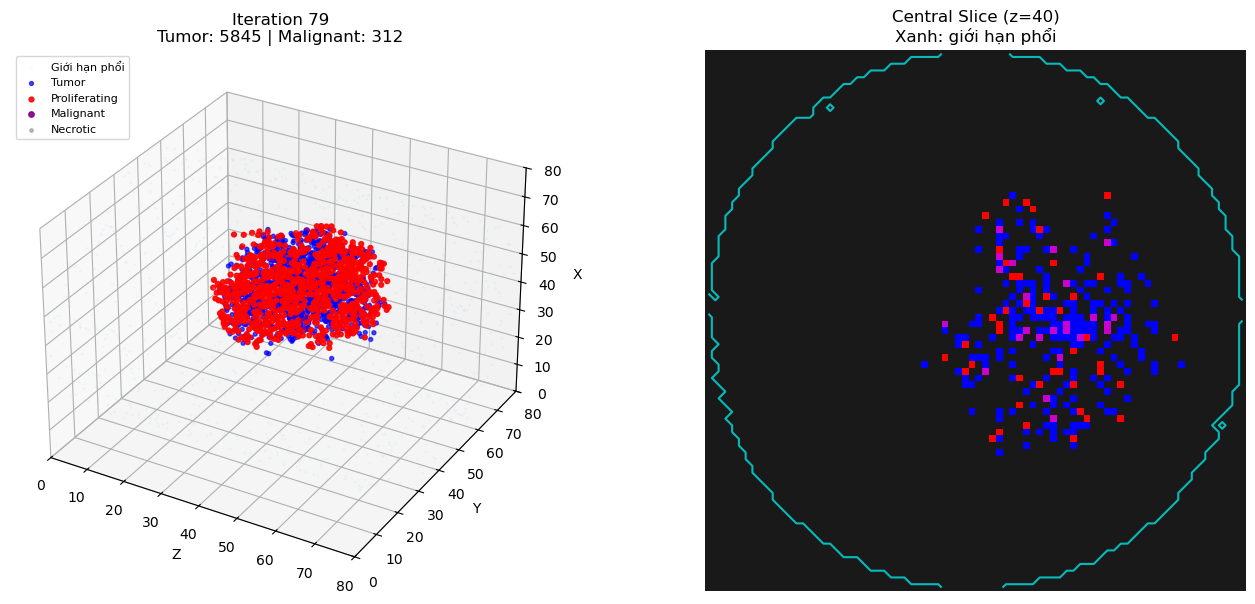


✅ Simulation hoàn thành!
   Tumor cuối: 6005 cells
   Malignant (ung thư): 321 cells
   Tỉ lệ tăng trưởng: 7.86x
   ✅ Tumor ngoài phổi: 0 cells (phải = 0)

🎨 Tạo visualizations kết quả cuối...

🎨 Tạo 3D visualization kết quả cuối...
✅ Saved: lung1_mlpa_output/LUNG1-001_mlpa_result.html


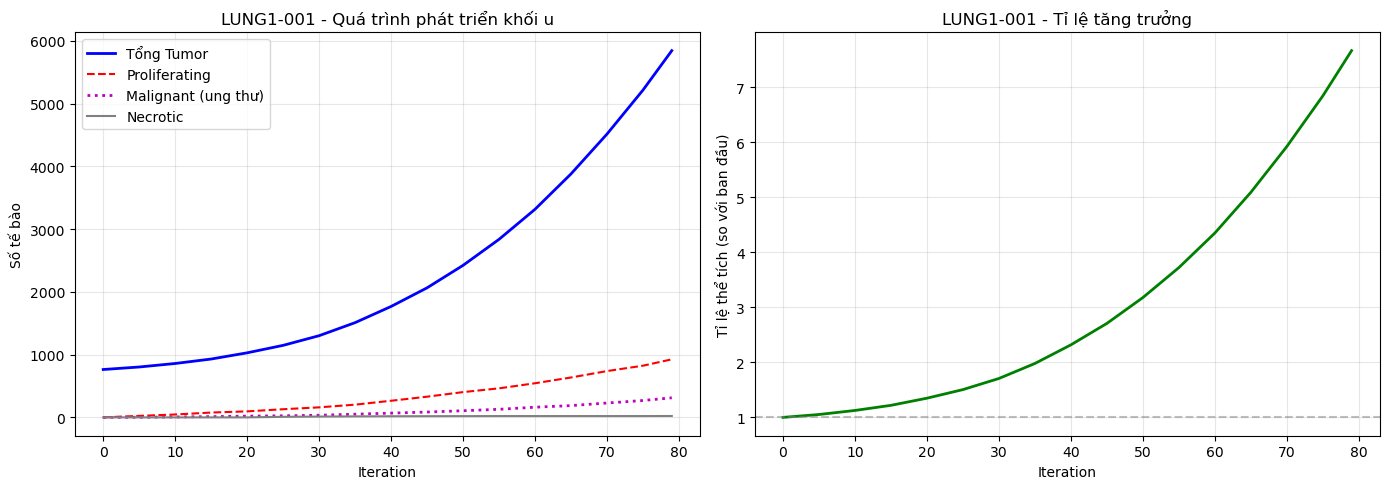

✅ Saved: lung1_mlpa_output/LUNG1-001_growth_trajectory.png


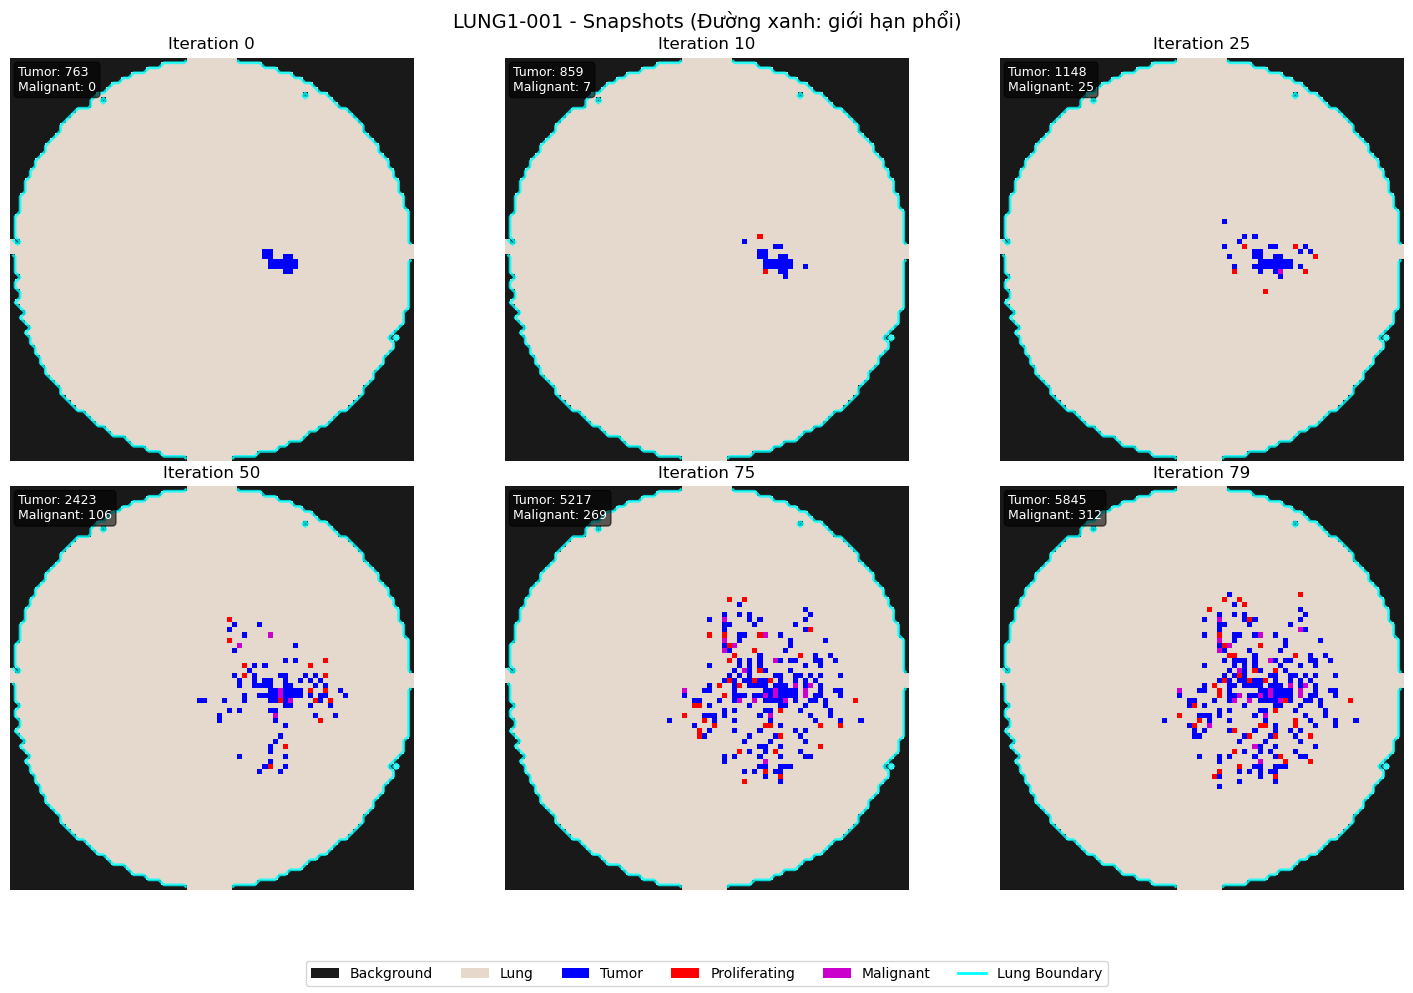

✅ Saved: lung1_mlpa_output/LUNG1-001_snapshots.png

📊 TỔNG KẾT
Bệnh nhân: LUNG1-001
Tumor ban đầu: 763 cells
Tumor cuối: 6005 cells
  - Malignant (ung thư): 321 cells
Tỉ lệ tăng trưởng: 7.86x

📁 Output: /home/hnguye24/digital_twins/lung1_mlpa_output

📄 Files đã tạo:
  - LUNG1-001_animation.html (4775.3 KB)
  - LUNG1-001_snapshots.png (125.1 KB)
  - LUNG1-001_mlpa_result.html (4913.1 KB)
  - LUNG1-001_lung_tumor_initial.html (7822.0 KB)
  - LUNG1-001_growth_trajectory.png (93.1 KB)


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
3D MLPA TUMOR GROWTH SIMULATION - LUNG1 REAL DATA ONLY
================================================================================
Mô phỏng sự phát triển khối u trong phổi bệnh nhân với:
- Hiển thị giới hạn phổi (lung boundary) trong suốt
- Real-time visualization khi tumor phát triển
- Tumor không vượt qua phạm vi phổi

Author: Paul Nguyen
"""

import numpy as np
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from scipy import ndimage
from scipy.ndimage import gaussian_filter, binary_dilation, binary_erosion, label
from skimage import measure
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import plotly.graph_objects as go

# ============================================================================
# CẤU HÌNH - THAY ĐỔI CÁC GIÁ TRỊ NÀY THEO MÁY CỦA BẠN
# ============================================================================

# Đường dẫn LUNG1 dataset
LUNG1_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")

# Thư mục output
OUTPUT_DIR = Path("./lung1_mlpa_output")

# Patient ID cụ thể (None = chọn patient đầu tiên)
SELECTED_PATIENT_ID = None  # Ví dụ: "LUNG1-001"

# MLPA Parameters
MLPA_CONFIG = {
    'grid_size': 80,            # Kích thước grid (giảm để real-time nhanh hơn)
    'num_iterations': 80,       # Số iterations
    'alpha': 0.08,              # Growth rate (tốc độ tăng trưởng)
    'beta': 0.05,               # Invasion potential (khả năng xâm lấn)
    'gamma': 0.9,               # Resistance factor
    'mutation_chance': 0.002,   # Xác suất đột biến thành ung thư
    'necrosis_chance': 0.015,   # Xác suất hoại tử ở vùng lõi
    'neighborhood_26': True,    # Sử dụng 26 neighbors
    'realtime_interval': 5,     # Cập nhật visualization mỗi N iterations
}

# ============================================================================
# CELL STATES & COLORMAP
# ============================================================================

CELL_STATES = {
    0: 'Background (ngoài phổi)',
    1: 'Normal Lung Tissue (mô phổi bình thường)',
    2: 'Tumor (tế bào u thường)',
    3: 'Necrotic (hoại tử)',
    4: 'Proliferating (đang phân chia)',
    5: 'Quiescent (nghỉ ngơi)',
    6: 'Malignant (ung thư - đã đột biến)'
}

CELL_CMAP = ListedColormap([
    (0.1, 0.1, 0.1),    # 0: Background (đen)
    (0.9, 0.85, 0.8),   # 1: Normal lung (be nhạt)
    (0.0, 0.0, 1.0),    # 2: Tumor (xanh dương)
    (0.4, 0.4, 0.4),    # 3: Necrotic (xám)
    (1.0, 0.0, 0.0),    # 4: Proliferating (đỏ)
    (0.5, 0.7, 1.0),    # 5: Quiescent (xanh nhạt)
    (0.8, 0.0, 0.8),    # 6: Malignant (tím)
])


# ============================================================================
# DICOM DATA LOADING
# ============================================================================

def scan_lung1_patients(data_root: Path, max_patients: int = None) -> List[Dict]:
    """Scan LUNG1 dataset để tìm patients có cả CT và segmentation."""
    if not data_root.exists():
        raise FileNotFoundError(f"Data root không tồn tại: {data_root}")
    
    patients = {}
    
    for patient_dir in sorted(data_root.glob("LUNG1-*")):
        if not patient_dir.is_dir():
            continue
        
        patient_id = patient_dir.name
        
        for study_dir in patient_dir.glob("*"):
            if not study_dir.is_dir():
                continue
            
            subdirs = [d for d in study_dir.iterdir() if d.is_dir()]
            seg_dirs = [d for d in subdirs if d.name.startswith("300.")]
            
            ct_dirs = []
            for d in subdirs:
                if d.name.startswith("300."):
                    continue
                dcm_count = len(list(d.glob("*.dcm")))
                if dcm_count >= 10:
                    ct_dirs.append((d, dcm_count))
            
            if ct_dirs and seg_dirs:
                ct_dir = max(ct_dirs, key=lambda x: x[1])[0]
                seg_files = list(seg_dirs[0].glob("*.dcm"))
                
                if seg_files:
                    patient_info = {
                        'patient_id': patient_id,
                        'ct_dir': str(ct_dir),
                        'seg_file': str(seg_files[0]),
                        'n_slices': max(ct_dirs, key=lambda x: x[1])[1]
                    }
                    
                    if patient_id not in patients or \
                       patient_info['n_slices'] > patients[patient_id]['n_slices']:
                        patients[patient_id] = patient_info
    
    result = list(patients.values())
    if max_patients:
        result = result[:max_patients]
    
    if len(result) == 0:
        raise ValueError(f"Không tìm thấy patient nào trong {data_root}")
    
    return result


def load_ct_volume(ct_dir: str) -> Tuple[np.ndarray, Tuple[float, float, float], List]:
    """Load CT volume từ DICOM files."""
    ct_path = Path(ct_dir)
    dcm_files = sorted(ct_path.glob("*.dcm"))
    
    if not dcm_files:
        raise FileNotFoundError(f"Không tìm thấy DICOM files trong {ct_dir}")
    
    slices = []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(str(f))
            if hasattr(ds, 'ImagePositionPatient') and hasattr(ds, 'pixel_array'):
                slices.append(ds)
        except Exception:
            continue
    
    if len(slices) == 0:
        raise ValueError("Không tìm thấy CT slice hợp lệ")
    
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    volume = np.stack([s.pixel_array for s in slices])
    
    if hasattr(slices[0], 'RescaleSlope') and hasattr(slices[0], 'RescaleIntercept'):
        slope = float(slices[0].RescaleSlope)
        intercept = float(slices[0].RescaleIntercept)
        volume = volume * slope + intercept
    
    pixel_spacing = [float(x) for x in slices[0].PixelSpacing]
    if len(slices) > 1:
        z_spacing = abs(float(slices[1].ImagePositionPatient[2]) - 
                       float(slices[0].ImagePositionPatient[2]))
    else:
        z_spacing = float(getattr(slices[0], 'SliceThickness', 1.0))
    
    spacing = (z_spacing, pixel_spacing[0], pixel_spacing[1])
    
    return volume.astype(np.float32), spacing, slices


def load_tumor_mask(seg_file: str, ct_slices: List) -> np.ndarray:
    """Load tumor segmentation từ DICOM SEG file."""
    seg_ds = pydicom.dcmread(str(seg_file))
    
    sop_to_index = {}
    for idx, ds in enumerate(ct_slices):
        sop_to_index[ds.SOPInstanceUID] = idx
    
    tumor_seg_num = 2
    if hasattr(seg_ds, 'SegmentSequence'):
        for seg in seg_ds.SegmentSequence:
            seg_num = int(seg.SegmentNumber)
            label_name = getattr(seg, 'SegmentLabel', "")
            if 'neoplasm' in label_name.lower() or 'primary' in label_name.lower():
                tumor_seg_num = seg_num
                break
    
    frames = seg_ds.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]
    
    num_slices = len(ct_slices)
    rows = int(ct_slices[0].Rows)
    cols = int(ct_slices[0].Columns)
    mask_vol = np.zeros((num_slices, rows, cols), dtype=np.uint8)
    
    if hasattr(seg_ds, 'PerFrameFunctionalGroupsSequence'):
        pffg = seg_ds.PerFrameFunctionalGroupsSequence
        
        for frame_idx in range(frames.shape[0]):
            try:
                seg_id_seq = pffg[frame_idx].SegmentIdentificationSequence[0]
                frame_seg_num = int(seg_id_seq.ReferencedSegmentNumber)
                
                if frame_seg_num != tumor_seg_num:
                    continue
                
                dseq = pffg[frame_idx].DerivationImageSequence[0]
                src = dseq.SourceImageSequence[0]
                ref_uid = src.ReferencedSOPInstanceUID
                
                if ref_uid in sop_to_index:
                    z = sop_to_index[ref_uid]
                    mask_vol[z] = np.maximum(mask_vol[z], 
                                            (frames[frame_idx] > 0).astype(np.uint8))
            except (AttributeError, IndexError):
                continue
    
    tumor_voxels = np.sum(mask_vol > 0)
    if tumor_voxels == 0:
        raise ValueError("Không tìm thấy tumor trong segmentation file")
    
    return mask_vol


def extract_lung_region(ct_volume: np.ndarray) -> np.ndarray:
    """Extract vùng phổi từ CT volume sử dụng HU thresholding."""
    lung_mask = (ct_volume < -400) & (ct_volume > -1000)
    
    for z in range(lung_mask.shape[0]):
        lung_mask[z] = ndimage.binary_fill_holes(lung_mask[z])
    
    labeled, num_features = ndimage.label(lung_mask)
    
    if num_features > 0:
        sizes = ndimage.sum(lung_mask, labeled, range(1, num_features + 1))
        
        if len(sizes) >= 2:
            largest_indices = np.argsort(sizes)[-2:]
            lung_mask = np.isin(labeled, largest_indices + 1)
        elif len(sizes) == 1:
            lung_mask = labeled == (np.argmax(sizes) + 1)
    
    struct = ndimage.generate_binary_structure(3, 1)
    lung_mask = binary_dilation(lung_mask, structure=struct, iterations=2)
    
    return lung_mask.astype(np.uint8)


# ============================================================================
# 3D VISUALIZATION WITH LUNG BOUNDARY
# ============================================================================

def create_3d_mesh(mask: np.ndarray, spacing: Tuple[float, float, float], 
                   step_size: int = 2) -> Optional[Dict]:
    """Tạo mesh từ binary mask sử dụng marching cubes."""
    try:
        verts, faces, _, _ = measure.marching_cubes(
            mask.astype(float), level=0.5, step_size=step_size
        )
        verts_scaled = verts * np.array(spacing)
        return {'vertices': verts_scaled, 'faces': faces}
    except Exception as e:
        print(f"  ⚠️ Marching cubes error: {e}")
        return None


def visualize_lung_and_tumor_3d(lung_mask: np.ndarray, tumor_mask: np.ndarray,
                                 spacing: Tuple[float, float, float],
                                 patient_id: str, output_dir: Path,
                                 show_in_notebook: bool = True) -> go.Figure:
    """
    Visualize phổi và khối u trong không gian 3D.
    - Phổi: transparent mesh (giới hạn rõ ràng)
    - Tumor: solid surface
    """
    print("  Tạo 3D meshes...")
    
    traces = []
    
    # ========== LUNG BOUNDARY MESH (trong suốt, mờ) ==========
    lung_mesh = create_3d_mesh(lung_mask, spacing, step_size=3)
    if lung_mesh:
        traces.append(go.Mesh3d(
            x=lung_mesh['vertices'][:, 0],
            y=lung_mesh['vertices'][:, 1],
            z=lung_mesh['vertices'][:, 2],
            i=lung_mesh['faces'][:, 0],
            j=lung_mesh['faces'][:, 1],
            k=lung_mesh['faces'][:, 2],
            color='rgba(173, 216, 230, 0.3)',  # Light blue, trong suốt
            opacity=0.2,
            name='Giới hạn Phổi',
            lighting=dict(ambient=0.6, diffuse=0.5, specular=0.1),
            lightposition=dict(x=100, y=200, z=300),
            hoverinfo='name'
        ))
        print(f"    ✅ Lung boundary mesh: {len(lung_mesh['vertices'])} vertices")
    
    # ========== TUMOR MESH (solid) ==========
    tumor_mesh = create_3d_mesh(tumor_mask, spacing, step_size=2)
    if tumor_mesh:
        traces.append(go.Mesh3d(
            x=tumor_mesh['vertices'][:, 0],
            y=tumor_mesh['vertices'][:, 1],
            z=tumor_mesh['vertices'][:, 2],
            i=tumor_mesh['faces'][:, 0],
            j=tumor_mesh['faces'][:, 1],
            k=tumor_mesh['faces'][:, 2],
            color='red',
            opacity=0.9,
            name='Khối u ban đầu',
            lighting=dict(ambient=0.5, diffuse=0.8, specular=0.3),
            lightposition=dict(x=100, y=200, z=300)
        ))
        print(f"    ✅ Tumor mesh: {len(tumor_mesh['vertices'])} vertices")
    
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=dict(
            text=f"{patient_id} - Phổi và Khối u 3D<br><sub>Vùng xanh nhạt: giới hạn phổi | Vùng đỏ: khối u</sub>",
            x=0.5
        ),
        scene=dict(
            xaxis_title='Z (mm)',
            yaxis_title='Y (mm)',
            zaxis_title='X (mm)',
            aspectmode='data',
            bgcolor='rgb(20, 20, 30)'
        ),
        width=900, height=700,
        showlegend=True,
        legend=dict(x=0.02, y=0.98)
    )
    
    # Save HTML
    html_path = output_dir / f"{patient_id}_lung_tumor_initial.html"
    fig.write_html(str(html_path), include_plotlyjs=True)
    print(f"    ✅ Saved: {html_path}")
    
    # Hiển thị trong notebook
    if show_in_notebook:
        fig.show()
    
    return fig


# ============================================================================
# REAL-TIME 3D VISUALIZATION CLASS
# ============================================================================

class RealtimeVisualizer:
    """
    Hiển thị real-time tumor growth trong Jupyter notebook.
    Sử dụng matplotlib cho hiển thị nhanh.
    """
    
    def __init__(self, lung_mask: np.ndarray, grid_size: int):
        self.lung_mask = lung_mask
        self.grid_size = grid_size
        self.fig = None
        self.ax = None
        
        # Precompute lung boundary points (downsampled)
        lung_coords = np.argwhere(lung_mask > 0)
        step = max(1, len(lung_coords) // 500)
        self.lung_coords = lung_coords[::step]
        
        # Extract lung surface for visualization
        self._compute_lung_surface()
    
    def _compute_lung_surface(self):
        """Compute lung surface points for visualization."""
        # Get surface by erosion
        eroded = binary_erosion(self.lung_mask, iterations=1)
        surface = self.lung_mask.astype(bool) & ~eroded
        
        surface_coords = np.argwhere(surface)
        step = max(1, len(surface_coords) // 800)
        self.lung_surface = surface_coords[::step]
    
    def setup_figure(self):
        """Khởi tạo figure cho real-time display."""
        plt.ion()  # Interactive mode
        self.fig = plt.figure(figsize=(14, 6))
        
        # 3D subplot
        self.ax_3d = self.fig.add_subplot(121, projection='3d')
        
        # 2D slice subplot
        self.ax_2d = self.fig.add_subplot(122)
        
        plt.tight_layout()
    
    def update_display(self, grid: np.ndarray, iteration: int, 
                       tumor_count: int, malignant_count: int):
        """
        Cập nhật hiển thị real-time.
        """
        if self.fig is None:
            self.setup_figure()
        
        # Clear axes
        self.ax_3d.clear()
        self.ax_2d.clear()
        
        # ========== 3D VIEW ==========
        # Vẽ giới hạn phổi (trong suốt, mờ)
        self.ax_3d.scatter(
            self.lung_surface[:, 0],
            self.lung_surface[:, 1],
            self.lung_surface[:, 2],
            c='lightblue', alpha=0.1, s=1,
            label='Giới hạn phổi'
        )
        
        # Vẽ tumor cells
        tumor_coords = np.argwhere(grid == 2)
        prolif_coords = np.argwhere(grid == 4)
        malignant_coords = np.argwhere(grid == 6)
        necrotic_coords = np.argwhere(grid == 3)
        
        # Downsample nếu quá nhiều points
        def downsample(coords, max_points=1000):
            if len(coords) > max_points:
                step = len(coords) // max_points
                return coords[::step]
            return coords
        
        # Tumor thường (xanh dương)
        if len(tumor_coords) > 0:
            tc = downsample(tumor_coords)
            self.ax_3d.scatter(tc[:, 0], tc[:, 1], tc[:, 2],
                              c='blue', alpha=0.7, s=8, label='Tumor')
        
        # Proliferating (đỏ)
        if len(prolif_coords) > 0:
            pc = downsample(prolif_coords)
            self.ax_3d.scatter(pc[:, 0], pc[:, 1], pc[:, 2],
                              c='red', alpha=0.9, s=12, label='Proliferating')
        
        # Malignant (tím)
        if len(malignant_coords) > 0:
            mc = downsample(malignant_coords)
            self.ax_3d.scatter(mc[:, 0], mc[:, 1], mc[:, 2],
                              c='purple', alpha=0.9, s=15, label='Malignant')
        
        # Necrotic (xám)
        if len(necrotic_coords) > 0:
            nc = downsample(necrotic_coords)
            self.ax_3d.scatter(nc[:, 0], nc[:, 1], nc[:, 2],
                              c='gray', alpha=0.5, s=6, label='Necrotic')
        
        self.ax_3d.set_xlabel('Z')
        self.ax_3d.set_ylabel('Y')
        self.ax_3d.set_zlabel('X')
        self.ax_3d.set_title(f'Iteration {iteration}\nTumor: {tumor_count} | Malignant: {malignant_count}')
        self.ax_3d.legend(loc='upper left', fontsize=8)
        
        # Set axis limits
        self.ax_3d.set_xlim(0, self.grid_size)
        self.ax_3d.set_ylim(0, self.grid_size)
        self.ax_3d.set_zlim(0, self.grid_size)
        
        # ========== 2D SLICE VIEW ==========
        z_mid = self.grid_size // 2
        slice_grid = grid[z_mid].copy()
        slice_lung = self.lung_mask[z_mid]
        
        # Hiển thị lung boundary
        lung_boundary = slice_lung.astype(float) * 0.3
        
        # Overlay grid lên lung
        display_slice = lung_boundary.copy()
        display_slice[slice_grid == 2] = 2  # Tumor
        display_slice[slice_grid == 3] = 3  # Necrotic
        display_slice[slice_grid == 4] = 4  # Proliferating
        display_slice[slice_grid == 6] = 6  # Malignant
        
        self.ax_2d.imshow(display_slice, origin='lower', cmap=CELL_CMAP, vmin=0, vmax=6)
        self.ax_2d.contour(slice_lung, levels=[0.5], colors='cyan', linewidths=1.5, alpha=0.7)
        self.ax_2d.set_title(f'Central Slice (z={z_mid})\nXanh: giới hạn phổi')
        self.ax_2d.axis('off')
        
        # Update display
        clear_output(wait=True)
        display(self.fig)
        plt.pause(0.01)
    
    def close(self):
        """Đóng figure."""
        if self.fig is not None:
            plt.ioff()
            plt.close(self.fig)


# ============================================================================
# MLPA 3D SIMULATION ENGINE WITH REALTIME VISUALIZATION
# ============================================================================

class MLPA3DSimulator:
    """
    Multi-scale Lattice-based Proliferation Automaton (MLPA) 3D
    
    Đặc điểm:
    - Khối u ban đầu là tế bào u thường (state=2), chưa phải ung thư
    - Tumor KHÔNG VƯỢT QUÁ phạm vi phổi
    - Real-time visualization trong Jupyter notebook
    """
    
    def __init__(self, config: Dict):
        self.config = config
        self.grid_size = config['grid_size']
        self.num_iterations = config['num_iterations']
        self.alpha = config['alpha']
        self.beta = config['beta']
        self.gamma = config['gamma']
        self.mutation_chance = config['mutation_chance']
        self.necrosis_chance = config['necrosis_chance']
        self.use_26_neighbors = config['neighborhood_26']
        self.realtime_interval = config.get('realtime_interval', 5)
        
        # 26-neighborhood offsets
        self.neighborhood_26 = []
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                for dz in [-1, 0, 1]:
                    if dx == 0 and dy == 0 and dz == 0:
                        continue
                    self.neighborhood_26.append((dx, dy, dz))
        self.neighborhood_26 = np.array(self.neighborhood_26, dtype=int)
    
    def resample_to_grid(self, mask: np.ndarray) -> np.ndarray:
        """Resample mask về kích thước grid simulation."""
        from scipy.ndimage import zoom
        scale = [self.grid_size / s for s in mask.shape]
        resampled = zoom(mask.astype(float), scale, order=0)
        return (resampled > 0.5).astype(np.uint8)
    
    def initialize_grid(self, lung_mask: np.ndarray, tumor_mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Khởi tạo CA grid:
        - 0: Background (NGOÀI PHỔI - tumor không được vào)
        - 1: Normal lung tissue (mô phổi bình thường)
        - 2: Tumor cells (tế bào u thường - CHƯA PHẢI UNG THƯ)
        """
        lung_resampled = self.resample_to_grid(lung_mask)
        tumor_resampled = self.resample_to_grid(tumor_mask)
        
        grid = np.zeros((self.grid_size, self.grid_size, self.grid_size), dtype=np.int8)
        grid[lung_resampled > 0] = 1
        
        # QUAN TRỌNG: Tumor chỉ đặt ở vị trí TRONG PHỔI
        tumor_in_lung = tumor_resampled & lung_resampled
        grid[tumor_in_lung > 0] = 2
        
        return grid, lung_resampled
    
    def create_microenvironment(self, ct_volume: np.ndarray, seed: int = 42) -> np.ndarray:
        """Tạo microenvironment map từ CT values."""
        from scipy.ndimage import zoom
        np.random.seed(seed)
        
        scale = [self.grid_size / s for s in ct_volume.shape]
        ct_resampled = zoom(ct_volume, scale, order=1)
        
        ct_norm = np.clip(ct_resampled, -1000, 400)
        ct_norm = (ct_norm + 1000) / 1400
        microenv = 0.5 + ct_norm * 0.5
        
        return microenv.astype(np.float32)
    
    def get_boundary_cells(self, grid: np.ndarray, lung_mask: np.ndarray) -> np.ndarray:
        """
        Tìm boundary cells: tế bào phổi bình thường kề với tumor.
        QUAN TRỌNG: Chỉ cells TRONG PHỔI mới có thể bị xâm lấn.
        """
        tumor_mask = (grid == 2) | (grid == 4) | (grid == 6)
        
        if self.use_26_neighbors:
            struct = ndimage.generate_binary_structure(3, 3)
        else:
            struct = ndimage.generate_binary_structure(3, 1)
        
        dilated = binary_dilation(tumor_mask, structure=struct)
        
        # CONSTRAINT: Chỉ xâm lấn TRONG PHỔI (lung_mask > 0)
        boundary = dilated & (grid == 1) & (lung_mask > 0)
        
        return boundary
    
    def run_simulation(self, lung_mask: np.ndarray, tumor_mask: np.ndarray,
                       ct_volume: np.ndarray, seed: int = 42,
                       realtime_display: bool = True) -> Dict:
        """
        Chạy MLPA simulation với real-time visualization.
        
        Args:
            lung_mask: Binary mask của phổi
            tumor_mask: Binary mask của tumor ban đầu
            ct_volume: CT volume để tạo microenvironment
            seed: Random seed
            realtime_display: Hiển thị real-time trong notebook
        """
        np.random.seed(seed)
        
        print(f"\n🔄 Bắt đầu MLPA Simulation...")
        print(f"   Grid size: {self.grid_size}³")
        print(f"   Iterations: {self.num_iterations}")
        print(f"   Neighborhood: {'26-connected' if self.use_26_neighbors else '6-connected'}")
        print(f"   Real-time display: {'ON' if realtime_display else 'OFF'}")
        
        # Initialize
        grid, lung_resampled = self.initialize_grid(lung_mask, tumor_mask)
        microenv = self.create_microenvironment(ct_volume, seed)
        
        initial_tumor = np.sum((grid == 2) | (grid == 4) | (grid == 6))
        lung_volume = np.sum(lung_resampled > 0)
        
        print(f"   Tumor ban đầu: {initial_tumor} cells (tế bào u thường)")
        print(f"   Phổi volume: {lung_volume} cells")
        print(f"\n   ⚠️ CONSTRAINT: Tumor chỉ phát triển TRONG phạm vi phổi")
        
        # Setup realtime visualizer
        visualizer = None
        if realtime_display:
            visualizer = RealtimeVisualizer(lung_resampled, self.grid_size)
        
        # Trajectory tracking
        trajectory = {
            'iteration': [],
            'tumor_count': [],
            'proliferating_count': [],
            'malignant_count': [],
            'necrotic_count': []
        }
        
        # Snapshots
        snapshots = []
        snapshot_iters = [0, 10, 25, 50, 75, self.num_iterations - 1]
        
        # Main simulation loop
        for it in range(self.num_iterations):
            
            # Record trajectory
            tumor_cells = np.sum((grid == 2) | (grid == 4) | (grid == 6))
            prolif_cells = np.sum(grid == 4)
            malignant_cells = np.sum(grid == 6)
            necrotic_cells = np.sum(grid == 3)
            
            if it % 5 == 0 or it in snapshot_iters:
                trajectory['iteration'].append(it)
                trajectory['tumor_count'].append(int(tumor_cells))
                trajectory['proliferating_count'].append(int(prolif_cells))
                trajectory['malignant_count'].append(int(malignant_cells))
                trajectory['necrotic_count'].append(int(necrotic_cells))
            
            # Save snapshot
            if it in snapshot_iters:
                snapshots.append({'iteration': it, 'grid': grid.copy()})
            
            # ========== REAL-TIME VISUALIZATION ==========
            if realtime_display and (it % self.realtime_interval == 0 or it == self.num_iterations - 1):
                visualizer.update_display(grid, it, tumor_cells, malignant_cells)
            
            # ========== CA UPDATE RULES ==========
            new_grid = grid.copy()
            
            # --- Rule 1: PROLIFERATION ---
            boundary = self.get_boundary_cells(grid, lung_resampled)
            boundary_coords = np.argwhere(boundary)
            
            if len(boundary_coords) > 0:
                n_boundary = len(boundary_coords)
                expected_growth = self.alpha * self.gamma * n_boundary * 0.1
                n_new_tumor = max(1, int(expected_growth))
                n_new_tumor = min(n_new_tumor, n_boundary)
                
                weights = np.array([microenv[tuple(c)] for c in boundary_coords])
                weights = weights / (weights.sum() + 1e-8)
                
                grow_indices = np.random.choice(
                    len(boundary_coords), size=n_new_tumor, replace=False, p=weights
                )
                
                for idx in grow_indices:
                    coord = tuple(boundary_coords[idx])
                    # DOUBLE CHECK: Chỉ grow trong phổi
                    if lung_resampled[coord] > 0:
                        new_grid[coord] = 4
            
            # --- Rule 2: INVASION (26-neighbor) ---
            if self.beta > 0.01 and it % 3 == 0 and self.use_26_neighbors:
                tumor_current = (grid == 2) | (grid == 4) | (grid == 6)
                
                struct_26 = ndimage.generate_binary_structure(3, 3)
                extended = binary_dilation(tumor_current, structure=struct_26, iterations=2)
                
                # CONSTRAINT: Chỉ xâm lấn TRONG PHỔI
                invasion_candidates = extended & (grid == 1) & (lung_resampled > 0) & (~boundary)
                
                if invasion_candidates.any():
                    inv_coords = np.argwhere(invasion_candidates)
                    inv_prob = self.beta * self.gamma
                    n_invasion = max(1, int(inv_prob * len(inv_coords) * 0.05))
                    n_invasion = min(n_invasion, len(inv_coords), 10)
                    
                    inv_weights = np.array([microenv[tuple(c)] for c in inv_coords])
                    inv_weights = inv_weights / (inv_weights.sum() + 1e-8)
                    
                    inv_selected = np.random.choice(
                        len(inv_coords), size=n_invasion, replace=False, p=inv_weights
                    )
                    
                    for idx in inv_selected:
                        coord = tuple(inv_coords[idx])
                        # DOUBLE CHECK: Chỉ invasion trong phổi
                        if lung_resampled[coord] > 0:
                            new_grid[coord] = 2
            
            # --- Rule 3: MUTATION (u thường -> ung thư) ---
            tumor_cells_mask = (grid == 2) | (grid == 4)
            mutation_rand = np.random.rand(*grid.shape)
            mutate_mask = tumor_cells_mask & (mutation_rand < self.mutation_chance)
            new_grid[mutate_mask] = 6
            
            # --- Rule 4: STATE TRANSITIONS ---
            prolif_mask = grid == 4
            transition_rand = np.random.rand(*grid.shape)
            transition_mask = prolif_mask & (transition_rand < 0.15)
            new_grid[transition_mask] = 2
            
            # --- Rule 5: NECROSIS ---
            if it > 20:
                tumor_current = (grid == 2) | (grid == 4) | (grid == 6)
                eroded = binary_erosion(tumor_current, iterations=2)
                
                necrosis_rand = np.random.rand(*grid.shape)
                necrosis_mask = eroded & (grid == 2) & (necrosis_rand < self.necrosis_chance)
                new_grid[necrosis_mask] = 3
            
            # ========== VERIFY CONSTRAINT ==========
            # Đảm bảo không có tumor ngoài phổi
            tumor_outside_lung = ((new_grid == 2) | (new_grid == 4) | (new_grid == 6)) & (lung_resampled == 0)
            if tumor_outside_lung.any():
                new_grid[tumor_outside_lung] = 0  # Reset về background
            
            grid = new_grid
            
            # Check constraint: tumor không vượt quá 80% phổi
            tumor_volume = np.sum((grid == 2) | (grid == 4) | (grid == 6))
            if tumor_volume > lung_volume * 0.8:
                print(f"\n   ⚠️ Tumor đạt 80% phổi, dừng simulation")
                break
        
        # Close visualizer
        if visualizer is not None:
            visualizer.close()
        
        # Final metrics
        final_tumor = np.sum((grid == 2) | (grid == 4) | (grid == 6))
        final_malignant = np.sum(grid == 6)
        volume_ratio = final_tumor / (initial_tumor + 1)
        
        print(f"\n✅ Simulation hoàn thành!")
        print(f"   Tumor cuối: {final_tumor} cells")
        print(f"   Malignant (ung thư): {final_malignant} cells")
        print(f"   Tỉ lệ tăng trưởng: {volume_ratio:.2f}x")
        
        # Verify no tumor outside lung
        tumor_outside = np.sum(((grid == 2) | (grid == 4) | (grid == 6)) & (lung_resampled == 0))
        print(f"   ✅ Tumor ngoài phổi: {tumor_outside} cells (phải = 0)")
        
        return {
            'final_grid': grid,
            'lung_mask': lung_resampled,
            'trajectory': trajectory,
            'snapshots': snapshots,
            'initial_tumor': initial_tumor,
            'final_tumor': final_tumor,
            'final_malignant': final_malignant,
            'volume_ratio': volume_ratio
        }


# ============================================================================
# FINAL VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_final_result_3d(result: Dict, patient_id: str, output_dir: Path,
                               show_in_notebook: bool = True) -> go.Figure:
    """
    Visualize kết quả cuối cùng trong 3D với lung boundary.
    """
    grid = result['final_grid']
    lung_mask = result['lung_mask']
    grid_size = grid.shape[0]
    
    print("\n🎨 Tạo 3D visualization kết quả cuối...")
    
    traces = []
    
    # ========== LUNG BOUNDARY (trong suốt) ==========
    try:
        lung_mesh = create_3d_mesh(lung_mask, (1, 1, 1), step_size=3)
        if lung_mesh:
            traces.append(go.Mesh3d(
                x=lung_mesh['vertices'][:, 0],
                y=lung_mesh['vertices'][:, 1],
                z=lung_mesh['vertices'][:, 2],
                i=lung_mesh['faces'][:, 0],
                j=lung_mesh['faces'][:, 1],
                k=lung_mesh['faces'][:, 2],
                color='rgba(173, 216, 230, 0.25)',
                opacity=0.15,
                name='Giới hạn Phổi',
                lighting=dict(ambient=0.6, diffuse=0.5),
                hoverinfo='name'
            ))
    except:
        # Fallback to scatter
        lung_coords = np.argwhere(lung_mask > 0)[::20]
        if len(lung_coords) > 0:
            traces.append(go.Scatter3d(
                x=lung_coords[:, 0], y=lung_coords[:, 1], z=lung_coords[:, 2],
                mode='markers',
                marker=dict(size=1, color='lightblue', opacity=0.05),
                name='Giới hạn Phổi'
            ))
    
    # ========== TUMOR CELLS ==========
    # Tumor thường (xanh dương)
    tumor_coords = np.argwhere(grid == 2)
    if len(tumor_coords) > 0:
        step = max(1, len(tumor_coords) // 2000)
        tc = tumor_coords[::step]
        traces.append(go.Scatter3d(
            x=tc[:, 0], y=tc[:, 1], z=tc[:, 2],
            mode='markers',
            marker=dict(size=2, color='blue', opacity=0.7),
            name=f'Tumor ({len(tumor_coords)})'
        ))
    
    # Proliferating (đỏ)
    prolif_coords = np.argwhere(grid == 4)
    if len(prolif_coords) > 0:
        traces.append(go.Scatter3d(
            x=prolif_coords[:, 0], y=prolif_coords[:, 1], z=prolif_coords[:, 2],
            mode='markers',
            marker=dict(size=3, color='red', opacity=0.9),
            name=f'Proliferating ({len(prolif_coords)})'
        ))
    
    # Malignant (tím)
    malignant_coords = np.argwhere(grid == 6)
    if len(malignant_coords) > 0:
        traces.append(go.Scatter3d(
            x=malignant_coords[:, 0], y=malignant_coords[:, 1], z=malignant_coords[:, 2],
            mode='markers',
            marker=dict(size=3, color='purple', opacity=0.9),
            name=f'Malignant ({len(malignant_coords)})'
        ))
    
    # Necrotic (xám)
    necrotic_coords = np.argwhere(grid == 3)
    if len(necrotic_coords) > 0:
        step = max(1, len(necrotic_coords) // 500)
        nc = necrotic_coords[::step]
        traces.append(go.Scatter3d(
            x=nc[:, 0], y=nc[:, 1], z=nc[:, 2],
            mode='markers',
            marker=dict(size=2, color='gray', opacity=0.5),
            name=f'Necrotic ({len(necrotic_coords)})'
        ))
    
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=dict(
            text=f"{patient_id} - Kết quả MLPA Simulation<br><sub>Tumor: {result['final_tumor']} | Malignant: {result['final_malignant']} | Tỉ lệ: {result['volume_ratio']:.1f}x</sub>",
            x=0.5
        ),
        scene=dict(
            xaxis=dict(title='Z', range=[0, grid_size]),
            yaxis=dict(title='Y', range=[0, grid_size]),
            zaxis=dict(title='X', range=[0, grid_size]),
            aspectmode='cube',
            bgcolor='rgb(20, 20, 30)'
        ),
        width=900, height=700,
        showlegend=True,
        legend=dict(x=0.02, y=0.98)
    )
    
    html_path = output_dir / f"{patient_id}_mlpa_result.html"
    fig.write_html(str(html_path), include_plotlyjs=True)
    print(f"✅ Saved: {html_path}")
    
    if show_in_notebook:
        fig.show()
    
    return fig


def visualize_growth_trajectory(result: Dict, patient_id: str, output_dir: Path):
    """Vẽ đồ thị tăng trưởng tumor theo thời gian."""
    traj = result['trajectory']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    ax.plot(traj['iteration'], traj['tumor_count'], 'b-', lw=2, label='Tổng Tumor')
    ax.plot(traj['iteration'], traj['proliferating_count'], 'r--', lw=1.5, label='Proliferating')
    ax.plot(traj['iteration'], traj['malignant_count'], 'm:', lw=2, label='Malignant (ung thư)')
    ax.plot(traj['iteration'], traj['necrotic_count'], 'gray', lw=1.5, label='Necrotic')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Số tế bào')
    ax.set_title(f'{patient_id} - Quá trình phát triển khối u')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    initial = result['initial_tumor']
    if initial > 0:
        volume_ratios = np.array(traj['tumor_count']) / initial
        ax2.plot(traj['iteration'], volume_ratios, 'g-', lw=2)
        ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Tỉ lệ thể tích (so với ban đầu)')
    ax2.set_title(f'{patient_id} - Tỉ lệ tăng trưởng')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    png_path = output_dir / f"{patient_id}_growth_trajectory.png"
    plt.savefig(str(png_path), dpi=150)
    plt.show()
    print(f"✅ Saved: {png_path}")


def visualize_snapshots_2d(result: Dict, patient_id: str, output_dir: Path):
    """Vẽ 2D slices tại các thời điểm khác nhau với lung boundary."""
    snapshots = result['snapshots']
    lung_mask = result['lung_mask']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, snapshot in enumerate(snapshots[:6]):
        grid = snapshot['grid']
        iteration = snapshot['iteration']
        
        z_mid = grid.shape[0] // 2
        slice_data = grid[z_mid]
        slice_lung = lung_mask[z_mid]
        
        ax = axes[idx]
        ax.imshow(slice_data, origin='lower', cmap=CELL_CMAP, vmin=0, vmax=6)
        # Vẽ lung boundary
        ax.contour(slice_lung, levels=[0.5], colors='cyan', linewidths=2, alpha=0.8)
        ax.set_title(f'Iteration {iteration}')
        ax.axis('off')
        
        tumor_count = np.sum((grid == 2) | (grid == 4) | (grid == 6))
        malignant_count = np.sum(grid == 6)
        ax.text(0.02, 0.98, f'Tumor: {tumor_count}\nMalignant: {malignant_count}', 
                transform=ax.transAxes, fontsize=9, va='top', color='white',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))
    
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor=CELL_CMAP(0), label='Background'),
        Patch(facecolor=CELL_CMAP(1), label='Lung'),
        Patch(facecolor=CELL_CMAP(2), label='Tumor'),
        Patch(facecolor=CELL_CMAP(4), label='Proliferating'),
        Patch(facecolor=CELL_CMAP(6), label='Malignant'),
        Line2D([0], [0], color='cyan', lw=2, label='Lung Boundary'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=10)
    
    plt.suptitle(f'{patient_id} - Snapshots (Đường xanh: giới hạn phổi)', fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    
    png_path = output_dir / f"{patient_id}_snapshots.png"
    plt.savefig(str(png_path), dpi=150)
    plt.show()
    print(f"✅ Saved: {png_path}")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_pipeline(patient_info: Dict, config: Dict, output_dir: Path,
                 realtime_display: bool = True) -> Dict:
    """Chạy toàn bộ pipeline cho một bệnh nhân."""
    patient_id = patient_info['patient_id']
    
    print("\n" + "="*70)
    print(f"🔬 XỬ LÝ BỆNH NHÂN: {patient_id}")
    print("="*70)
    
    print("\n📂 Đang load CT volume...")
    ct_vol, spacing, ct_slices = load_ct_volume(patient_info['ct_dir'])
    print(f"   Shape: {ct_vol.shape}")
    print(f"   Spacing: {spacing} mm")
    
    print("\n📂 Đang load tumor mask...")
    tumor_mask = load_tumor_mask(patient_info['seg_file'], ct_slices)
    print(f"   Tumor voxels: {np.sum(tumor_mask > 0)}")
    
    print("\n🫁 Đang extract vùng phổi...")
    lung_mask = extract_lung_region(ct_vol)
    print(f"   Lung voxels: {np.sum(lung_mask > 0)}")
    
    print("\n🎨 Tạo visualization ban đầu (Phổi + Tumor)...")
    visualize_lung_and_tumor_3d(lung_mask, tumor_mask, spacing, patient_id, output_dir)
    
    # Run simulation với real-time display
    simulator = MLPA3DSimulator(config)
    result = simulator.run_simulation(
        lung_mask=lung_mask,
        tumor_mask=tumor_mask,
        ct_volume=ct_vol,
        seed=42,
        realtime_display=realtime_display
    )
    result['patient_id'] = patient_id
    result['spacing'] = spacing
    
    # Final visualizations
    print("\n🎨 Tạo visualizations kết quả cuối...")
    visualize_final_result_3d(result, patient_id, output_dir)
    visualize_growth_trajectory(result, patient_id, output_dir)
    visualize_snapshots_2d(result, patient_id, output_dir)
    
    return result


# ============================================================================
# MAIN - CHẠY TRỰC TIẾP TRONG JUPYTER NOTEBOOK
# ============================================================================

# Tạo thư mục output
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*70)
print("🧬 LUNG1 3D MLPA TUMOR GROWTH SIMULATION")
print("   ✅ Hiển thị giới hạn phổi (lung boundary)")
print("   ✅ Real-time visualization")  
print("   ✅ Tumor không vượt qua phạm vi phổi")
print("="*70)

# Scan patients
print(f"\n📂 Đang scan patients trong {LUNG1_ROOT}...")
patients = scan_lung1_patients(LUNG1_ROOT, max_patients=10)
print(f"✅ Tìm thấy {len(patients)} patients có CT + Segmentation")

# Hiển thị danh sách
print("\nDanh sách patients:")
for i, p in enumerate(patients[:10]):
    print(f"  [{i}] {p['patient_id']}: {p['n_slices']} slices")

# Chọn patient
if SELECTED_PATIENT_ID:
    patient = None
    for p in patients:
        if p['patient_id'] == SELECTED_PATIENT_ID:
            patient = p
            break
    if patient is None:
        raise ValueError(f"Không tìm thấy patient: {SELECTED_PATIENT_ID}")
else:
    patient = patients[0]

print(f"\n🎯 Chọn: {patient['patient_id']}")

# Chạy pipeline với real-time display
result = run_pipeline(patient, MLPA_CONFIG, OUTPUT_DIR, realtime_display=True)

# Tổng kết
print("\n" + "="*70)
print("📊 TỔNG KẾT")
print("="*70)
print(f"Bệnh nhân: {result['patient_id']}")
print(f"Tumor ban đầu: {result['initial_tumor']} cells")
print(f"Tumor cuối: {result['final_tumor']} cells")
print(f"  - Malignant (ung thư): {result['final_malignant']} cells")
print(f"Tỉ lệ tăng trưởng: {result['volume_ratio']:.2f}x")
print(f"\n📁 Output: {OUTPUT_DIR.absolute()}")

print("\n📄 Files đã tạo:")
for f in OUTPUT_DIR.glob("*"):
    size_kb = f.stat().st_size / 1024
    print(f"  - {f.name} ({size_kb:.1f} KB)")

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
3D MLPA TUMOR GROWTH - GROUND TRUTH LUNG CONSTRAINTS
================================================================================
Mô phỏng phát triển khối u dựa trên cấu trúc giải phẫu CHUẨN từ DICOM SEG.
- Tumor: Lấy từ Segment 1 (Neoplasm)
- Lung Boundary: Gộp từ Segment 2 & 3 (Lung Left/Right)
- Simulation: Khối u chỉ được phép phát triển trong vùng pixel của Segment 2 & 3.

Author: Paul Nguyen
"""

import numpy as np
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from scipy.ndimage import zoom, binary_erosion, binary_dilation
from scipy import ndimage
from skimage import measure
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display, clear_output
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

# ============================================================================
# CẤU HÌNH
# ============================================================================

LUNG1_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")
OUTPUT_DIR = Path("./lung1_mlpa_output_groundtruth")
SELECTED_PATIENT_ID = None # None = Auto pick first patient

MLPA_CONFIG = {
    'grid_size': 100,           
    'num_iterations': 80,       
    'alpha': 0.08,              
    'beta': 0.05,               
    'gamma': 0.9,               
    'mutation_chance': 0.002,   
    'necrosis_chance': 0.015,   
    'neighborhood_26': True,    
    'realtime_interval': 5,     
}

# ============================================================================
# DATA LOADING (CT & SEGMENTATION)
# ============================================================================

def scan_lung1_patients(data_root: Path, max_patients: int = None) -> List[Dict]:
    """Scan dataset."""
    if not data_root.exists(): raise FileNotFoundError(f"Path not found: {data_root}")
    patients = {}
    for patient_dir in sorted(data_root.glob("LUNG1-*")):
        if not patient_dir.is_dir(): continue
        patient_id = patient_dir.name
        for study_dir in patient_dir.glob("*"):
            if not study_dir.is_dir(): continue
            subdirs = [d for d in study_dir.iterdir() if d.is_dir()]
            seg_dirs = [d for d in subdirs if d.name.startswith("300.")]
            ct_dirs = []
            for d in subdirs:
                if d.name.startswith("300."): continue
                if len(list(d.glob("*.dcm"))) >= 10: ct_dirs.append((d, len(list(d.glob("*.dcm")))))
            
            if ct_dirs and seg_dirs:
                ct_dir = max(ct_dirs, key=lambda x: x[1])[0]
                seg_files = list(seg_dirs[0].glob("*.dcm"))
                if seg_files:
                    patients[patient_id] = {
                        'patient_id': patient_id,
                        'ct_dir': str(ct_dir),
                        'seg_file': str(seg_files[0]),
                        'n_slices': max(ct_dirs, key=lambda x: x[1])[1]
                    }
    return list(patients.values())[:max_patients] if max_patients else list(patients.values())

def load_ct_volume(ct_dir: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List]:
    """Load CT volume."""
    slices = [pydicom.dcmread(str(f)) for f in sorted(Path(ct_dir).glob("*.dcm"))]
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    
    # Metadata
    pixel_spacing = [float(x) for x in slices[0].PixelSpacing]
    z_spacing = abs(float(slices[1].ImagePositionPatient[2]) - float(slices[0].ImagePositionPatient[2]))
    spacing = np.array([z_spacing, pixel_spacing[0], pixel_spacing[1]])
    
    origin_xyz = [float(x) for x in slices[0].ImagePositionPatient]
    origin = np.array([origin_xyz[2], origin_xyz[1], origin_xyz[0]]) # z, y, x
    
    # Volume constructing
    volume = np.stack([s.pixel_array for s in slices])
    slope = float(getattr(slices[0], 'RescaleSlope', 1))
    intercept = float(getattr(slices[0], 'RescaleIntercept', 0))
    volume = volume * slope + intercept
    
    return volume.astype(np.float32), spacing, origin, slices

def load_masks_from_dicom_seg(seg_file: str, ct_slices: List) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load chính xác các segments từ file SEG.
    - Tumor: Segment 1
    - Lung: Segment 2 + Segment 3
    """
    print(f"📖 Đọc segmentation từ: {Path(seg_file).name}")
    seg_ds = pydicom.dcmread(str(seg_file))
    
    # Map UID to Z-index
    sop_to_index = {ds.SOPInstanceUID: idx for idx, ds in enumerate(ct_slices)}
    
    shape = (len(ct_slices), int(ct_slices[0].Rows), int(ct_slices[0].Columns))
    tumor_mask = np.zeros(shape, dtype=np.uint8)
    lung_mask = np.zeros(shape, dtype=np.uint8)
    
    # Check segment info
    if hasattr(seg_ds, 'SegmentSequence'):
        for seg in seg_ds.SegmentSequence:
            print(f"   found Segment {seg.SegmentNumber}: {getattr(seg, 'SegmentLabel', 'Unknown')}")

    # Process frames
    frames = seg_ds.pixel_array
    if frames.ndim == 2: frames = frames[np.newaxis, ...]
    
    print("   🔨 Đang trích xuất dữ liệu mask...")
    if hasattr(seg_ds, 'PerFrameFunctionalGroupsSequence'):
        pffg = seg_ds.PerFrameFunctionalGroupsSequence
        for i, frame_meta in enumerate(pffg):
            # Lấy số hiệu segment của frame hiện tại
            seg_num = int(frame_meta.SegmentIdentificationSequence[0].ReferencedSegmentNumber)
            
            # Lấy vị trí slice tương ứng
            ref_uid = frame_meta.DerivationImageSequence[0].SourceImageSequence[0].ReferencedSOPInstanceUID
            if ref_uid in sop_to_index:
                z = sop_to_index[ref_uid]
                mask_slice = (frames[i] > 0).astype(np.uint8)
                
                # SEGMENT 1: TUMOR
                if seg_num == 1:
                    tumor_mask[z] = np.maximum(tumor_mask[z], mask_slice)
                
                # SEGMENT 2 & 3: LUNGS (Trái & Phải)
                elif seg_num in [2, 3]:
                    lung_mask[z] = np.maximum(lung_mask[z], mask_slice)

    if np.sum(lung_mask) == 0:
        raise ValueError("⚠️ Không tìm thấy dữ liệu Phổi (Segment 2, 3). Kiểm tra lại file SEG!")
    
    # Lấp đầy các lỗ nhỏ trong phổi (mạch máu) để tạo khối liền mạch cho mô phỏng
    print("   🔨 Đang xử lý morphology để làm liền mạch phổi...")
    for z in range(lung_mask.shape[0]):
        lung_mask[z] = ndimage.binary_fill_holes(lung_mask[z])
        
    return tumor_mask, lung_mask

# ============================================================================
# COORDINATE TRANSFORM
# ============================================================================

class RealSpaceTransform:
    def __init__(self, spacing, origin, original_shape, grid_size):
        self.spacing = spacing
        self.origin = origin
        self.scale = np.array(original_shape) / grid_size
        self.real_dimensions = np.array(original_shape) * spacing
        
    def grid_to_mm(self, grid_coords):
        return (grid_coords * self.scale) * self.spacing + self.origin
        
    def get_real_extent(self):
        return {
            'x_min': self.origin[2], 'x_max': self.origin[2] + self.real_dimensions[2],
            'y_min': self.origin[1], 'y_max': self.origin[1] + self.real_dimensions[1],
            'z_min': self.origin[0], 'z_max': self.origin[0] + self.real_dimensions[0],
        }

def extract_surface_mesh(mask, spacing, origin, step_size=2):
    try:
        verts, faces, _, _ = measure.marching_cubes(mask.astype(float), level=0.5, step_size=step_size)
        return verts * spacing + origin, faces
    except: return None, None

# ============================================================================
# VISUALIZATION
# ============================================================================

def visualize_interactive_state(lung_mask, tumor_mask, grid, spacing, origin, patient_id, title_prefix, filename):
    """
    Hàm vẽ chung cho cả trạng thái đầu và cuối.
    Có slider điều chỉnh độ trong suốt của phổi.
    """
    print(f"🎨 Tạo visualization: {title_prefix}...")
    
    # Xác định shape để transform
    if grid is not None:
        shape = (lung_mask.shape[0], lung_mask.shape[1], lung_mask.shape[2]) # grid shape logic handled inside transform
        grid_size = grid.shape[0]
        transform = RealSpaceTransform(spacing, origin, lung_mask.shape, grid_size)
    else:
        # Initial state (no grid yet)
        transform = None
        
    traces = []
    
    # 1. LUNG SURFACE (Ground Truth)
    verts, faces = extract_surface_mesh(lung_mask, spacing, origin, step_size=4)
    if verts is not None:
        traces.append(go.Mesh3d(
            x=verts[:, 2], y=verts[:, 1], z=verts[:, 0],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color='rgba(100, 180, 220, 1.0)',
            opacity=0.15, # Mặc định
            name='Phổi (Ground Truth)',
            flatshading=True,
            lighting=dict(ambient=0.8, diffuse=0.2)
        ))
    
    # 2. TUMOR
    if grid is None:
        # Initial state (Mask gốc)
        t_coords = np.argwhere(tumor_mask > 0)
        if len(t_coords) > 0:
            t_mm = t_coords * spacing + origin
            step = max(1, len(t_mm) // 3000)
            t_mm = t_mm[::step]
            traces.append(go.Scatter3d(
                x=t_mm[:, 2], y=t_mm[:, 1], z=t_mm[:, 0],
                mode='markers', marker=dict(size=3, color='blue', opacity=0.8),
                name='Khối u ban đầu'
            ))
    else:
        # Final state (Grid mô phỏng)
        def plot_cells(state, color, name):
            coords = np.argwhere(grid == state)
            if len(coords) > 0:
                cm = transform.grid_to_mm(coords)
                step = max(1, len(cm) // 2500)
                cm = cm[::step]
                traces.append(go.Scatter3d(
                    x=cm[:, 2], y=cm[:, 1], z=cm[:, 0],
                    mode='markers', marker=dict(size=3, color=color, opacity=0.8),
                    name=name
                ))
        plot_cells(2, 'blue', 'Tumor Core')
        plot_cells(4, 'red', 'Proliferating (Active)')
        plot_cells(6, 'purple', 'Malignant (Invasive)')
        plot_cells(3, 'gray', 'Necrotic')

    # 3. SLIDER CONFIG
    sliders = [dict(
        active=3,
        currentvalue={"prefix": "Độ trong suốt Phổi: "},
        pad={"t": 50},
        steps=[dict(method="restyle", args=[{"opacity": [op]}, [0]], label=f"{op:.2f}") 
               for op in np.arange(0, 0.8, 0.05)]
    )]

    fig = go.Figure(data=traces)
    
    # Calculate extent based on Lung Mask
    l_coords = np.argwhere(lung_mask)
    z_min, z_max = (l_coords[:,0].min()*spacing[0]+origin[0]), (l_coords[:,0].max()*spacing[0]+origin[0])
    y_min, y_max = (l_coords[:,1].min()*spacing[1]+origin[1]), (l_coords[:,1].max()*spacing[1]+origin[1])
    x_min, x_max = (l_coords[:,2].min()*spacing[2]+origin[2]), (l_coords[:,2].max()*spacing[2]+origin[2])

    fig.update_layout(
        title=dict(text=f"{patient_id} - {title_prefix}", x=0.5),
        scene=dict(
            xaxis=dict(title='X (mm)', range=[x_min, x_max]),
            yaxis=dict(title='Y (mm)', range=[y_min, y_max]),
            zaxis=dict(title='Z (mm)', range=[z_min, z_max]),
            aspectmode='data', bgcolor='rgb(245, 245, 250)'
        ),
        width=1000, height=800, sliders=sliders, margin=dict(b=100)
    )
    
    path = OUTPUT_DIR / filename
    fig.write_html(str(path))
    print(f"✅ Đã lưu: {path}")
    fig.show()

# ============================================================================
# SIMULATION ENGINE
# ============================================================================

class MLPA3DRealSpace:
    def __init__(self, config):
        self.cfg = config
        self.grid_size = config['grid_size']
        
    def resample(self, mask, shape):
        scale = np.array([self.grid_size]*3) / np.array(shape)
        return zoom(mask.astype(float), scale, order=0) > 0.5
        
    def run(self, lung_mask, tumor_mask, ct_volume, spacing, origin):
        print(f"\n🔄 Bắt đầu mô phỏng (Grid: {self.grid_size}^3)...")
        
        # Resample về grid size để chạy cho nhanh
        lung_grid = self.resample(lung_mask, lung_mask.shape)
        tumor_grid = self.resample(tumor_mask, tumor_mask.shape)
        
        # Chỉ giữ tumor nằm TRONG phổi (Safety check)
        tumor_grid = tumor_grid & lung_grid
        
        # Init state
        grid = np.zeros_like(lung_grid, dtype=np.int8)
        grid[lung_grid] = 1        # 1: Normal Lung
        grid[tumor_grid] = 2       # 2: Tumor
        
        # Microenvironment (CT density based)
        scale = np.array([self.grid_size]*3) / np.array(ct_volume.shape)
        ct_small = zoom(ct_volume, scale, order=1)
        # Normalize HU (-1000 to 400) -> 0 to 1
        microenv = np.clip((ct_small + 1000) / 1400, 0, 1)
        
        vol_lung = np.sum(lung_grid)
        
        # Simulation Loop
        for it in range(self.cfg['num_iterations']):
            # 1. Tìm biên giới (Tumor giáp Lung)
            tumor_cells = (grid == 2) | (grid == 4) | (grid == 6)
            dilated = binary_dilation(tumor_cells)
            boundary = dilated & (grid == 1) & lung_grid # CHỈ PHÁT TRIỂN NƠI CÓ LUNG_GRID
            
            # 2. Proliferation (Sinh sản)
            candidates = np.argwhere(boundary)
            if len(candidates) > 0:
                n_grow = int(len(candidates) * self.cfg['alpha'])
                # Chọn ngẫu nhiên dựa trên mật độ CT (tế bào thích nơi giàu dinh dưỡng/mạch máu)
                weights = microenv[tuple(candidates.T)]
                weights /= (weights.sum() + 1e-9)
                
                indices = np.random.choice(len(candidates), size=n_grow, p=weights)
                for idx in indices:
                    grid[tuple(candidates[idx])] = 4 # Chuyển thành Proliferating
            
            # 3. State update
            # Proliferating (4) -> Tumor (2)
            mask_4 = (grid == 4)
            change_mask = mask_4 & (np.random.rand(*grid.shape) < 0.2)
            grid[change_mask] = 2
            
            # Mutation (-> 6)
            mask_2 = (grid == 2)
            mut_mask = mask_2 & (np.random.rand(*grid.shape) < self.cfg['mutation_chance'])
            grid[mut_mask] = 6
            
            # Necrosis (-> 3) at center
            if it > 15:
                eroded = binary_erosion(tumor_cells, iterations=2)
                nec_mask = eroded & (grid == 2) & (np.random.rand(*grid.shape) < self.cfg['necrosis_chance'])
                grid[nec_mask] = 3
                
            # SAFETY CHECK: Tuyệt đối không để rò rỉ
            grid[~lung_grid] = 0
            
            if it % 10 == 0:
                count = np.sum(tumor_cells)
                print(f"   Iter {it}: Tumor voxels = {count} ({(count/vol_lung)*100:.2f}% volume)")
                
        return grid

# ============================================================================
# MAIN PIPELINE
# ============================================================================

if __name__ == "__main__":
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print("🚀 BẮT ĐẦU QUY TRÌNH MÔ PHỎNG VỚI GROUND TRUTH SEGMENTATION")
    
    # 1. Tìm bệnh nhân
    patients = scan_lung1_patients(LUNG1_ROOT, max_patients=5)
    p = patients[0] if not SELECTED_PATIENT_ID else next(x for x in patients if x['patient_id'] == SELECTED_PATIENT_ID)
    print(f"👤 Patient: {p['patient_id']}")
    
    # 2. Load CT
    ct_vol, spacing, origin, ct_slices = load_ct_volume(p['ct_dir'])
    
    # 3. Load Segmentation (QUAN TRỌNG: Load đúng Seg 1, 2, 3)
    tumor_mask, lung_mask = load_masks_from_dicom_seg(p['seg_file'], ct_slices)
    
    print(f"📊 Thống kê dữ liệu:")
    print(f"   - Tumor voxels: {np.sum(tumor_mask)}")
    print(f"   - Lung voxels : {np.sum(lung_mask)} (Đã gộp Seg 2 & 3)")
    
    # 4. Visualize Bước 1: Khởi tạo
    visualize_interactive_state(
        lung_mask, tumor_mask, None, spacing, origin, 
        p['patient_id'], "1. Trang thai khoi tao (Ground Truth)", 
        f"{p['patient_id']}_step1_initial.html"
    )
    
    # 5. Chạy mô phỏng
    simulator = MLPA3DRealSpace(MLPA_CONFIG)
    final_grid = simulator.run(lung_mask, tumor_mask, ct_vol, spacing, origin)
    
    # 6. Visualize Bước 2: Kết quả
    visualize_interactive_state(
        lung_mask, tumor_mask, final_grid, spacing, origin, 
        p['patient_id'], "2. Ket qua mo phong (Lung Constrained)", 
        f"{p['patient_id']}_step2_result.html"
    )
    
    print("\n✅ HOÀN THÀNH TOÀN BỘ!")

🚀 BẮT ĐẦU QUY TRÌNH MÔ PHỎNG VỚI GROUND TRUTH SEGMENTATION
👤 Patient: LUNG1-001
📖 Đọc segmentation từ: 1-1.dcm
   found Segment 1: Neoplasm, Primary
   found Segment 2: Lung
   found Segment 3: Lung
   found Segment 4: Spinal cord
   🔨 Đang trích xuất dữ liệu mask...
   🔨 Đang xử lý morphology để làm liền mạch phổi...
📊 Thống kê dữ liệu:
   - Tumor voxels: 54639
   - Lung voxels : 1833414 (Đã gộp Seg 2 & 3)
🎨 Tạo visualization: 1. Trang thai khoi tao (Ground Truth)...
✅ Đã lưu: lung1_mlpa_output_groundtruth/LUNG1-001_step1_initial.html



🔄 Bắt đầu mô phỏng (Grid: 100^3)...
   Iter 0: Tumor voxels = 144 (0.28% volume)
   Iter 10: Tumor voxels = 468 (0.91% volume)
   Iter 20: Tumor voxels = 1108 (2.16% volume)
   Iter 30: Tumor voxels = 2135 (4.16% volume)
   Iter 40: Tumor voxels = 3615 (7.04% volume)
   Iter 50: Tumor voxels = 5576 (10.86% volume)
   Iter 60: Tumor voxels = 7984 (15.55% volume)
   Iter 70: Tumor voxels = 10554 (20.56% volume)
🎨 Tạo visualization: 2. Ket qua mo phong (Lung Constrained)...
✅ Đã lưu: lung1_mlpa_output_groundtruth/LUNG1-001_step2_result.html



✅ HOÀN THÀNH TOÀN BỘ!


In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
3D MLPA TUMOR GROWTH - GROUND TRUTH LUNG CONSTRAINTS + GIF EXPORT
================================================================================
Cập nhật:
- Thêm chức năng xuất file .gif minh họa quá trình phát triển.
- Sử dụng lát cắt ngang (Axial Slice) qua tâm khối u để làm GIF.

Author: Paul Nguyen
"""

import numpy as np
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from scipy.ndimage import zoom, binary_erosion, binary_dilation, center_of_mass
from scipy import ndimage
from skimage import measure
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import io
import imageio.v2 as imageio  # Cần cài: pip install imageio
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

# ============================================================================
# CẤU HÌNH
# ============================================================================

LUNG1_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")
OUTPUT_DIR = Path("./lung1_mlpa_output_gif")
SELECTED_PATIENT_ID = None 

MLPA_CONFIG = {
    'grid_size': 100,           
    'num_iterations': 80,       
    'alpha': 0.08,              
    'beta': 0.05,               
    'gamma': 0.9,               
    'mutation_chance': 0.002,   
    'necrosis_chance': 0.015,   
    'neighborhood_26': True,    
    'gif_interval': 2,          # Lưu frame cho GIF mỗi 2 vòng lặp
}

# Định nghĩa màu cho GIF (Matplotlib)
# 0:Bg, 1:Lung, 2:Tumor, 3:Necrotic, 4:Prolif, 5:Quiescent, 6:Malignant
CMAP_COLORS = [
    (0, 0, 0, 1),           # 0: Black (Background)
    (0.8, 0.9, 0.9, 0.3),   # 1: Pale Cyan (Lung - Transparent)
    (0.0, 0.0, 0.8, 1),     # 2: Blue (Tumor Core)
    (0.5, 0.5, 0.5, 1),     # 3: Gray (Necrotic)
    (1.0, 0.2, 0.2, 1),     # 4: Red (Proliferating)
    (0.0, 0.0, 0.0, 0),     # 5: (Unused)
    (0.6, 0.0, 0.6, 1),     # 6: Purple (Malignant)
]
CUSTOM_CMAP = ListedColormap(CMAP_COLORS)

# ============================================================================
# DATA LOADING & TRANSFORMS (GIỮ NGUYÊN)
# ============================================================================

def scan_lung1_patients(data_root: Path, max_patients: int = None) -> List[Dict]:
    if not data_root.exists(): raise FileNotFoundError(f"Path not found: {data_root}")
    patients = {}
    for patient_dir in sorted(data_root.glob("LUNG1-*")):
        if not patient_dir.is_dir(): continue
        patient_id = patient_dir.name
        for study_dir in patient_dir.glob("*"):
            if not study_dir.is_dir(): continue
            subdirs = [d for d in study_dir.iterdir() if d.is_dir()]
            seg_dirs = [d for d in subdirs if d.name.startswith("300.")]
            ct_dirs = []
            for d in subdirs:
                if d.name.startswith("300."): continue
                if len(list(d.glob("*.dcm"))) >= 10: ct_dirs.append((d, len(list(d.glob("*.dcm")))))
            if ct_dirs and seg_dirs:
                ct_dir = max(ct_dirs, key=lambda x: x[1])[0]
                seg_files = list(seg_dirs[0].glob("*.dcm"))
                if seg_files:
                    patients[patient_id] = {'patient_id': patient_id, 'ct_dir': str(ct_dir), 'seg_file': str(seg_files[0]), 'n_slices': max(ct_dirs, key=lambda x: x[1])[1]}
    return list(patients.values())[:max_patients] if max_patients else list(patients.values())

def load_ct_volume(ct_dir: str):
    slices = [pydicom.dcmread(str(f)) for f in sorted(Path(ct_dir).glob("*.dcm"))]
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    pixel_spacing = [float(x) for x in slices[0].PixelSpacing]
    z_spacing = abs(float(slices[1].ImagePositionPatient[2]) - float(slices[0].ImagePositionPatient[2]))
    spacing = np.array([z_spacing, pixel_spacing[0], pixel_spacing[1]])
    origin = np.array([float(slices[0].ImagePositionPatient[2]), float(slices[0].ImagePositionPatient[1]), float(slices[0].ImagePositionPatient[0])])
    volume = np.stack([s.pixel_array for s in slices]) * float(getattr(slices[0], 'RescaleSlope', 1)) + float(getattr(slices[0], 'RescaleIntercept', 0))
    return volume.astype(np.float32), spacing, origin, slices

def load_masks_from_dicom_seg(seg_file: str, ct_slices: List):
    print(f"📖 Đọc segmentation từ: {Path(seg_file).name}")
    seg_ds = pydicom.dcmread(str(seg_file))
    sop_to_index = {ds.SOPInstanceUID: idx for idx, ds in enumerate(ct_slices)}
    shape = (len(ct_slices), int(ct_slices[0].Rows), int(ct_slices[0].Columns))
    tumor_mask = np.zeros(shape, dtype=np.uint8)
    lung_mask = np.zeros(shape, dtype=np.uint8)
    
    frames = seg_ds.pixel_array
    if frames.ndim == 2: frames = frames[np.newaxis, ...]
    
    if hasattr(seg_ds, 'PerFrameFunctionalGroupsSequence'):
        pffg = seg_ds.PerFrameFunctionalGroupsSequence
        for i, frame_meta in enumerate(pffg):
            try:
                seg_num = int(frame_meta.SegmentIdentificationSequence[0].ReferencedSegmentNumber)
                ref_uid = frame_meta.DerivationImageSequence[0].SourceImageSequence[0].ReferencedSOPInstanceUID
                if ref_uid in sop_to_index:
                    z = sop_to_index[ref_uid]
                    mask_slice = (frames[i] > 0).astype(np.uint8)
                    if seg_num == 1: tumor_mask[z] = np.maximum(tumor_mask[z], mask_slice)
                    elif seg_num in [2, 3]: lung_mask[z] = np.maximum(lung_mask[z], mask_slice)
            except: continue

    if np.sum(lung_mask) == 0: raise ValueError("⚠️ Không tìm thấy dữ liệu Phổi (Segment 2, 3).")
    print("   🔨 Đang xử lý morphology làm liền mạch phổi...")
    for z in range(lung_mask.shape[0]): lung_mask[z] = ndimage.binary_fill_holes(lung_mask[z])
    return tumor_mask, lung_mask

class RealSpaceTransform:
    def __init__(self, spacing, origin, original_shape, grid_size):
        self.spacing, self.origin = spacing, origin
        self.scale = np.array(original_shape) / grid_size
        self.real_dimensions = np.array(original_shape) * spacing
    def grid_to_mm(self, grid_coords): return (grid_coords * self.scale) * self.spacing + self.origin
    def get_real_extent(self):
        return {'x_min': self.origin[2], 'x_max': self.origin[2] + self.real_dimensions[2],
                'y_min': self.origin[1], 'y_max': self.origin[1] + self.real_dimensions[1],
                'z_min': self.origin[0], 'z_max': self.origin[0] + self.real_dimensions[0]}

def extract_surface_mesh(mask, spacing, origin, step_size=2):
    try:
        verts, faces, _, _ = measure.marching_cubes(mask.astype(float), level=0.5, step_size=step_size)
        return verts * spacing + origin, faces
    except: return None, None

# ============================================================================
# VISUALIZATION (PLOTLY & GIF)
# ============================================================================

def visualize_interactive_state(lung_mask, tumor_mask, grid, spacing, origin, patient_id, title_prefix, filename):
    print(f"🎨 Tạo visualization 3D: {title_prefix}...")
    if grid is not None:
        grid_size = grid.shape[0]
        transform = RealSpaceTransform(spacing, origin, lung_mask.shape, grid_size)
    else: transform = None
        
    traces = []
    verts, faces = extract_surface_mesh(lung_mask, spacing, origin, step_size=4)
    if verts is not None:
        traces.append(go.Mesh3d(x=verts[:,2], y=verts[:,1], z=verts[:,0], i=faces[:,0], j=faces[:,1], k=faces[:,2], color='rgba(100, 180, 220, 1.0)', opacity=0.15, name='Phổi (Ground Truth)', flatshading=True))
    
    if grid is None:
        t_coords = np.argwhere(tumor_mask > 0)
        if len(t_coords) > 0:
            t_mm = t_coords * spacing + origin
            t_mm = t_mm[::max(1, len(t_mm)//3000)]
            traces.append(go.Scatter3d(x=t_mm[:,2], y=t_mm[:,1], z=t_mm[:,0], mode='markers', marker=dict(size=3, color='blue', opacity=0.8), name='Khối u ban đầu'))
    else:
        def plot_cells(state, color, name):
            coords = np.argwhere(grid == state)
            if len(coords) > 0:
                cm = transform.grid_to_mm(coords)
                cm = cm[::max(1, len(cm)//2500)]
                traces.append(go.Scatter3d(x=cm[:,2], y=cm[:,1], z=cm[:,0], mode='markers', marker=dict(size=3, color=color, opacity=0.8), name=name))
        plot_cells(2, 'blue', 'Tumor Core')
        plot_cells(4, 'red', 'Proliferating')
        plot_cells(6, 'purple', 'Malignant')
        plot_cells(3, 'gray', 'Necrotic')

    sliders = [dict(active=3, currentvalue={"prefix": "Độ trong suốt Phổi: "}, pad={"t": 50}, steps=[dict(method="restyle", args=[{"opacity": [op]}, [0]], label=f"{op:.2f}") for op in np.arange(0, 0.8, 0.05)])]
    
    l_coords = np.argwhere(lung_mask)
    # Safe bounds check
    if len(l_coords) > 0:
        z_min, z_max = (l_coords[:,0].min()*spacing[0]+origin[0]), (l_coords[:,0].max()*spacing[0]+origin[0])
        y_min, y_max = (l_coords[:,1].min()*spacing[1]+origin[1]), (l_coords[:,1].max()*spacing[1]+origin[1])
        x_min, x_max = (l_coords[:,2].min()*spacing[2]+origin[2]), (l_coords[:,2].max()*spacing[2]+origin[2])
    else:
        # Fallback if lung mask is empty (unlikely)
        z_min, z_max = origin[0], origin[0]+100
        y_min, y_max = origin[1], origin[1]+100
        x_min, x_max = origin[2], origin[2]+100

    fig = go.Figure(data=traces)
    fig.update_layout(title=dict(text=f"{patient_id} - {title_prefix}", x=0.5), scene=dict(xaxis=dict(title='X (mm)', range=[x_min, x_max]), yaxis=dict(title='Y (mm)', range=[y_min, y_max]), zaxis=dict(title='Z (mm)', range=[z_min, z_max]), aspectmode='data', bgcolor='rgb(245, 245, 250)'), width=1000, height=800, sliders=sliders, margin=dict(b=100))
    path = OUTPUT_DIR / filename
    fig.write_html(str(path))
    print(f"✅ Đã lưu HTML: {path}")

# ============================================================================
# SIMULATION ENGINE
# ============================================================================

class MLPA3DRealSpace:
    def __init__(self, config):
        self.cfg = config
        self.grid_size = config['grid_size']
        self.frames = [] # Chứa các frame cho GIF
        
    def resample(self, mask, shape):
        scale = np.array([self.grid_size]*3) / np.array(shape)
        return zoom(mask.astype(float), scale, order=0) > 0.5
    
    def capture_frame(self, grid, lung_grid, iteration, center_z):
        """Chụp ảnh lát cắt 2D tại center_z để làm GIF"""
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # Lấy slice
        slice_grid = grid[center_z, :, :].copy()
        slice_lung = lung_grid[center_z, :, :]
        
        # Vẽ
        ax.imshow(slice_grid, cmap=CUSTOM_CMAP, vmin=0, vmax=6, origin='lower')
        # Vẽ viền phổi
        ax.contour(slice_lung, levels=[0.5], colors='cyan', linewidths=1.5, alpha=0.7)
        
        # Trang trí
        ax.set_title(f"Iteration: {iteration}", fontsize=12, color='white', backgroundcolor='black')
        ax.axis('off')
        
        # Legend giả
        legend_elements = [
            Patch(facecolor='cyan', edgecolor='cyan', label='Lung Boundary'),
            Patch(facecolor='blue', label='Tumor'),
            Patch(facecolor='red', label='Proliferating'),
            Patch(facecolor='purple', label='Malignant')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.8)
        
        # Lưu vào buffer
        buf = io.BytesIO()
        plt.tight_layout()
        plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        
        # Đọc lại bằng imageio
        image = imageio.imread(buf)
        self.frames.append(image)
        
        plt.close(fig)
        buf.close()

    def run(self, lung_mask, tumor_mask, ct_volume, spacing, origin, patient_id):
        print(f"\n🔄 Bắt đầu mô phỏng (Grid: {self.grid_size}^3)...")
        
        lung_grid = self.resample(lung_mask, lung_mask.shape)
        tumor_grid = self.resample(tumor_mask, tumor_mask.shape)
        tumor_grid = tumor_grid & lung_grid
        
        grid = np.zeros_like(lung_grid, dtype=np.int8)
        grid[lung_grid] = 1        
        grid[tumor_grid] = 2       
        
        # Tìm tâm khối u ban đầu (theo trục Z grid) để cắt lát GIF
        tumor_coords = np.argwhere(tumor_grid)
        if len(tumor_coords) > 0:
            center_z = int(np.mean(tumor_coords[:, 0]))
        else:
            center_z = self.grid_size // 2
            
        print(f"   🎥 GIF sẽ được tạo từ lát cắt Z = {center_z}")

        scale = np.array([self.grid_size]*3) / np.array(ct_volume.shape)
        ct_small = zoom(ct_volume, scale, order=1)
        microenv = np.clip((ct_small + 1000) / 1400, 0, 1)
        
        vol_lung = np.sum(lung_grid)
        
        # Lưu frame đầu tiên
        self.capture_frame(grid, lung_grid, 0, center_z)

        for it in range(self.cfg['num_iterations']):
            # --- LOGIC MLPA (Giữ nguyên) ---
            tumor_cells = (grid == 2) | (grid == 4) | (grid == 6)
            dilated = binary_dilation(tumor_cells)
            boundary = dilated & (grid == 1) & lung_grid 
            
            candidates = np.argwhere(boundary)
            if len(candidates) > 0:
                n_grow = int(len(candidates) * self.cfg['alpha'])
                weights = microenv[tuple(candidates.T)]
                weights /= (weights.sum() + 1e-9)
                indices = np.random.choice(len(candidates), size=n_grow, p=weights)
                for idx in indices: grid[tuple(candidates[idx])] = 4 
            
            mask_4 = (grid == 4)
            grid[mask_4 & (np.random.rand(*grid.shape) < 0.2)] = 2
            mask_2 = (grid == 2)
            grid[mask_2 & (np.random.rand(*grid.shape) < self.cfg['mutation_chance'])] = 6
            
            if it > 15:
                eroded = binary_erosion(tumor_cells, iterations=2)
                grid[eroded & (grid == 2) & (np.random.rand(*grid.shape) < self.cfg['necrosis_chance'])] = 3
                
            grid[~lung_grid] = 0
            # -------------------------------
            
            # --- GIF CAPTURE ---
            if (it + 1) % self.cfg['gif_interval'] == 0:
                self.capture_frame(grid, lung_grid, it + 1, center_z)
            
            if it % 10 == 0:
                print(f"   Iter {it}: Tumor voxels = {np.sum(tumor_cells)}")
        
        # Lưu GIF ra file
        gif_path = OUTPUT_DIR / f"{patient_id}_growth_animation.gif"
        print(f"   💾 Đang lưu GIF: {gif_path} ...")
        imageio.mimsave(gif_path, self.frames, fps=8, loop=0) # fps=8, loop forever
        print(f"   ✅ Đã lưu GIF thành công!")
                
        return grid

# ============================================================================
# MAIN PIPELINE
# ============================================================================

if __name__ == "__main__":
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print("🚀 BẮT ĐẦU QUY TRÌNH MÔ PHỎNG (LUNG CONST + GIF)")
    
    patients = scan_lung1_patients(LUNG1_ROOT, max_patients=5)
    p = patients[0] if not SELECTED_PATIENT_ID else next(x for x in patients if x['patient_id'] == SELECTED_PATIENT_ID)
    print(f"👤 Patient: {p['patient_id']}")
    
    ct_vol, spacing, origin, ct_slices = load_ct_volume(p['ct_dir'])
    tumor_mask, lung_mask = load_masks_from_dicom_seg(p['seg_file'], ct_slices)
    
    # 1. Visualize Bước 1
    visualize_interactive_state(lung_mask, tumor_mask, None, spacing, origin, p['patient_id'], "1. Initial State", f"{p['patient_id']}_initial.html")
    
    # 2. Chạy mô phỏng & Tạo GIF
    simulator = MLPA3DRealSpace(MLPA_CONFIG)
    final_grid = simulator.run(lung_mask, tumor_mask, ct_vol, spacing, origin, p['patient_id'])
    
    # 3. Visualize Bước 2
    visualize_interactive_state(lung_mask, tumor_mask, final_grid, spacing, origin, p['patient_id'], "2. Final Result", f"{p['patient_id']}_result.html")
    
    print("\n✅ HOÀN THÀNH! Kiểm tra thư mục output để xem file .gif")

🚀 BẮT ĐẦU QUY TRÌNH MÔ PHỎNG (LUNG CONST + GIF)
👤 Patient: LUNG1-001
📖 Đọc segmentation từ: 1-1.dcm
   🔨 Đang xử lý morphology làm liền mạch phổi...
🎨 Tạo visualization 3D: 1. Initial State...
✅ Đã lưu HTML: lung1_mlpa_output_gif/LUNG1-001_initial.html

🔄 Bắt đầu mô phỏng (Grid: 100^3)...
   🎥 GIF sẽ được tạo từ lát cắt Z = 56
   Iter 0: Tumor voxels = 144
   Iter 10: Tumor voxels = 484
   Iter 20: Tumor voxels = 1133
   Iter 30: Tumor voxels = 2185
   Iter 40: Tumor voxels = 3646
   Iter 50: Tumor voxels = 5561
   Iter 60: Tumor voxels = 7833
   Iter 70: Tumor voxels = 10323
   💾 Đang lưu GIF: lung1_mlpa_output_gif/LUNG1-001_growth_animation.gif ...
   ✅ Đã lưu GIF thành công!
🎨 Tạo visualization 3D: 2. Final Result...
✅ Đã lưu HTML: lung1_mlpa_output_gif/LUNG1-001_result.html

✅ HOÀN THÀNH! Kiểm tra thư mục output để xem file .gif


In [11]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
3D MLPA TUMOR GROWTH - GROUND TRUTH LUNG CONST + 3D GIF ANIMATION
================================================================================
Cập nhật:
- Xóa bỏ toàn bộ hiển thị 2D.
- Tạo file .gif dạng 3D xoay chiều mô tả quá trình lớn lên của khối u.
- Sử dụng Matplotlib 3D cho việc tạo frame ảnh động.

Author: Paul Nguyen
"""

import numpy as np
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple
from scipy.ndimage import zoom, binary_erosion, binary_dilation
from scipy import ndimage
from skimage import measure
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import io
import imageio.v2 as imageio
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

# ============================================================================
# CẤU HÌNH
# ============================================================================

LUNG1_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")
OUTPUT_DIR = Path("./lung1_mlpa_output_3d_gif")
SELECTED_PATIENT_ID = None 

MLPA_CONFIG = {
    'grid_size': 80,            # Giảm nhẹ grid size để render 3D GIF nhanh hơn (hoặc để 100 nếu máy mạnh)
    'num_iterations': 60,       
    'alpha': 0.08,              
    'beta': 0.05,               
    'gamma': 0.9,               
    'mutation_chance': 0.002,   
    'necrosis_chance': 0.015,   
    'neighborhood_26': True,    
    'gif_interval': 3,          # Lưu frame mỗi 3 vòng lặp (để giảm dung lượng GIF)
}

# ============================================================================
# DATA LOADING (GIỮ NGUYÊN)
# ============================================================================

def scan_lung1_patients(data_root: Path, max_patients: int = None) -> List[Dict]:
    if not data_root.exists(): raise FileNotFoundError(f"Path not found: {data_root}")
    patients = {}
    for patient_dir in sorted(data_root.glob("LUNG1-*")):
        if not patient_dir.is_dir(): continue
        patient_id = patient_dir.name
        for study_dir in patient_dir.glob("*"):
            if not study_dir.is_dir(): continue
            subdirs = [d for d in study_dir.iterdir() if d.is_dir()]
            seg_dirs = [d for d in subdirs if d.name.startswith("300.")]
            ct_dirs = []
            for d in subdirs:
                if d.name.startswith("300."): continue
                if len(list(d.glob("*.dcm"))) >= 10: ct_dirs.append((d, len(list(d.glob("*.dcm")))))
            if ct_dirs and seg_dirs:
                ct_dir = max(ct_dirs, key=lambda x: x[1])[0]
                seg_files = list(seg_dirs[0].glob("*.dcm"))
                if seg_files:
                    patients[patient_id] = {'patient_id': patient_id, 'ct_dir': str(ct_dir), 'seg_file': str(seg_files[0]), 'n_slices': max(ct_dirs, key=lambda x: x[1])[1]}
    return list(patients.values())[:max_patients] if max_patients else list(patients.values())

def load_ct_volume(ct_dir: str):
    slices = [pydicom.dcmread(str(f)) for f in sorted(Path(ct_dir).glob("*.dcm"))]
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    pixel_spacing = [float(x) for x in slices[0].PixelSpacing]
    z_spacing = abs(float(slices[1].ImagePositionPatient[2]) - float(slices[0].ImagePositionPatient[2]))
    spacing = np.array([z_spacing, pixel_spacing[0], pixel_spacing[1]])
    origin = np.array([float(slices[0].ImagePositionPatient[2]), float(slices[0].ImagePositionPatient[1]), float(slices[0].ImagePositionPatient[0])])
    volume = np.stack([s.pixel_array for s in slices]) * float(getattr(slices[0], 'RescaleSlope', 1)) + float(getattr(slices[0], 'RescaleIntercept', 0))
    return volume.astype(np.float32), spacing, origin, slices

def load_masks_from_dicom_seg(seg_file: str, ct_slices: List):
    print(f"📖 Đọc segmentation từ: {Path(seg_file).name}")
    seg_ds = pydicom.dcmread(str(seg_file))
    sop_to_index = {ds.SOPInstanceUID: idx for idx, ds in enumerate(ct_slices)}
    shape = (len(ct_slices), int(ct_slices[0].Rows), int(ct_slices[0].Columns))
    tumor_mask = np.zeros(shape, dtype=np.uint8)
    lung_mask = np.zeros(shape, dtype=np.uint8)
    frames = seg_ds.pixel_array
    if frames.ndim == 2: frames = frames[np.newaxis, ...]
    if hasattr(seg_ds, 'PerFrameFunctionalGroupsSequence'):
        pffg = seg_ds.PerFrameFunctionalGroupsSequence
        for i, frame_meta in enumerate(pffg):
            try:
                seg_num = int(frame_meta.SegmentIdentificationSequence[0].ReferencedSegmentNumber)
                ref_uid = frame_meta.DerivationImageSequence[0].SourceImageSequence[0].ReferencedSOPInstanceUID
                if ref_uid in sop_to_index:
                    z = sop_to_index[ref_uid]
                    mask_slice = (frames[i] > 0).astype(np.uint8)
                    if seg_num == 1: tumor_mask[z] = np.maximum(tumor_mask[z], mask_slice)
                    elif seg_num in [2, 3]: lung_mask[z] = np.maximum(lung_mask[z], mask_slice)
            except: continue
    if np.sum(lung_mask) == 0: raise ValueError("⚠️ Không tìm thấy dữ liệu Phổi (Segment 2, 3).")
    print("   🔨 Đang xử lý morphology làm liền mạch phổi...")
    for z in range(lung_mask.shape[0]): lung_mask[z] = ndimage.binary_fill_holes(lung_mask[z])
    return tumor_mask, lung_mask

class RealSpaceTransform:
    def __init__(self, spacing, origin, original_shape, grid_size):
        self.spacing, self.origin = spacing, origin
        self.scale = np.array(original_shape) / grid_size
        self.real_dimensions = np.array(original_shape) * spacing
    def grid_to_mm(self, grid_coords): return (grid_coords * self.scale) * self.spacing + self.origin
    def get_real_extent(self):
        return {'x_min': self.origin[2], 'x_max': self.origin[2] + self.real_dimensions[2],
                'y_min': self.origin[1], 'y_max': self.origin[1] + self.real_dimensions[1],
                'z_min': self.origin[0], 'z_max': self.origin[0] + self.real_dimensions[0]}

def extract_surface_mesh(mask, spacing, origin, step_size=2):
    try:
        verts, faces, _, _ = measure.marching_cubes(mask.astype(float), level=0.5, step_size=step_size)
        return verts * spacing + origin, faces
    except: return None, None

# ============================================================================
# VISUALIZATION (PLOTLY & 3D GIF)
# ============================================================================

def visualize_interactive_html(lung_mask, tumor_mask, grid, spacing, origin, patient_id, title_prefix, filename):
    """Lưu file HTML tương tác cho trạng thái đầu/cuối"""
    print(f"🎨 Tạo HTML 3D: {title_prefix}...")
    if grid is not None:
        grid_size = grid.shape[0]
        transform = RealSpaceTransform(spacing, origin, lung_mask.shape, grid_size)
    else: transform = None
    traces = []
    verts, faces = extract_surface_mesh(lung_mask, spacing, origin, step_size=4)
    if verts is not None:
        traces.append(go.Mesh3d(x=verts[:,2], y=verts[:,1], z=verts[:,0], i=faces[:,0], j=faces[:,1], k=faces[:,2], color='rgba(100, 180, 220, 1.0)', opacity=0.15, name='Lung Boundary', flatshading=True))
    if grid is None:
        t_coords = np.argwhere(tumor_mask > 0)
        if len(t_coords) > 0:
            t_mm = t_coords * spacing + origin
            t_mm = t_mm[::max(1, len(t_mm)//3000)]
            traces.append(go.Scatter3d(x=t_mm[:,2], y=t_mm[:,1], z=t_mm[:,0], mode='markers', marker=dict(size=3, color='blue', opacity=0.8), name='Initial Tumor'))
    else:
        def plot_cells(state, color, name):
            coords = np.argwhere(grid == state)
            if len(coords) > 0:
                cm = transform.grid_to_mm(coords)
                cm = cm[::max(1, len(cm)//2500)]
                traces.append(go.Scatter3d(x=cm[:,2], y=cm[:,1], z=cm[:,0], mode='markers', marker=dict(size=3, color=color, opacity=0.8), name=name))
        plot_cells(2, 'blue', 'Core')
        plot_cells(4, 'red', 'Proliferating')
        plot_cells(6, 'purple', 'Malignant')
        plot_cells(3, 'gray', 'Necrotic')
    
    # Tính toán extent để set range cố định
    l_coords = np.argwhere(lung_mask)
    if len(l_coords) > 0:
        z_min, z_max = (l_coords[:,0].min()*spacing[0]+origin[0]), (l_coords[:,0].max()*spacing[0]+origin[0])
        y_min, y_max = (l_coords[:,1].min()*spacing[1]+origin[1]), (l_coords[:,1].max()*spacing[1]+origin[1])
        x_min, x_max = (l_coords[:,2].min()*spacing[2]+origin[2]), (l_coords[:,2].max()*spacing[2]+origin[2])
    else: z_min, z_max, y_min, y_max, x_min, x_max = 0, 100, 0, 100, 0, 100

    sliders = [dict(active=3, currentvalue={"prefix": "Lung Opacity: "}, pad={"t": 50}, steps=[dict(method="restyle", args=[{"opacity": [op]}, [0]], label=f"{op:.2f}") for op in np.arange(0, 0.8, 0.05)])]
    fig = go.Figure(data=traces)
    fig.update_layout(title=dict(text=f"{patient_id} - {title_prefix}", x=0.5), scene=dict(xaxis=dict(title='X', range=[x_min, x_max]), yaxis=dict(title='Y', range=[y_min, y_max]), zaxis=dict(title='Z', range=[z_min, z_max]), aspectmode='data', bgcolor='rgb(245, 245, 250)'), width=1000, height=800, sliders=sliders, margin=dict(b=100))
    path = OUTPUT_DIR / filename
    fig.write_html(str(path))
    print(f"✅ Đã lưu HTML: {path}")

# ============================================================================
# SIMULATION ENGINE
# ============================================================================

#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# ... (GIỮ NGUYÊN CÁC IMPORT VÀ DATA LOADING Ở TRÊN) ...
# Copy lại phần import và các hàm load data từ code trước nếu bạn chạy file mới
# Dưới đây là đoạn Class cần sửa:

class MLPA3DRealSpace:
    def __init__(self, config):
        self.cfg = config
        self.grid_size = config['grid_size']
        self.frames = []
        self.transform = None
        
        # Dữ liệu để vẽ background cố định cho GIF
        self.lung_surface_mm = None 
        self.plot_limits = None # Để cố định khung hình
        
    def resample(self, mask, shape):
        """Chuyển mask gốc về grid size của mô phỏng"""
        scale = np.array([self.grid_size]*3) / np.array(shape)
        # Order=0 (Nearest Neighbor) để giữ nguyên tính chất binary mask
        return zoom(mask.astype(float), scale, order=0) > 0.5
    
    def prepare_visualization_data(self, lung_grid):
        """
        Chuẩn bị dữ liệu vẽ Phổi (Constraint) MỘT LẦN DUY NHẤT từ chính grid mô phỏng.
        Điều này đảm bảo tính CONSISTENT: Simulation dùng gì, Visualization vẽ cái đó.
        """
        print("   🔨 Đang trích xuất bề mặt phổi từ Grid mô phỏng...")
        
        # 1. Tìm bề mặt của phổi (Lớp vỏ bao quanh)
        # Logic: Voxel thuộc phổi VÀ có ít nhất 1 hàng xóm là không khí
        eroded = binary_erosion(lung_grid, iterations=1)
        surface_grid = lung_grid & ~eroded
        
        coords = np.argwhere(surface_grid)
        
        if len(coords) > 0:
            # 2. Chuyển đổi sang không gian thực (mm)
            mm_coords = self.transform.grid_to_mm(coords)
            
            # 3. Downsample để vẽ cho nhẹ (nhưng vẫn giữ được hình dáng)
            # Lấy khoảng 2000-3000 điểm để tạo hình rõ ràng
            step = max(1, len(mm_coords) // 2500)
            self.lung_surface_mm = mm_coords[::step]
            
            # 4. Tính toán giới hạn khung hình (Limits) dựa trên PHỔI
            # Để camera không bị zoom ra zoom vào khi u to lên
            self.plot_limits = {
                'x': (mm_coords[:, 2].min(), mm_coords[:, 2].max()),
                'y': (mm_coords[:, 1].min(), mm_coords[:, 1].max()),
                'z': (mm_coords[:, 0].min(), mm_coords[:, 0].max())
            }
        else:
            print("⚠️ Cảnh báo: Không tìm thấy bề mặt phổi trong grid!")

    def capture_3d_frame(self, grid, iteration):
        """
        Vẽ frame 3D:
        - Lớp 1 (Nền): Bề mặt phổi (Màu nhạt, cố định)
        - Lớp 2 (Nhân): Khối u (Màu đậm, thay đổi)
        """
        # Tạo Figure với kích thước CỐ ĐỊNH (Quan trọng cho GIF)
        fig = plt.figure(figsize=(8, 8), dpi=80) 
        ax = fig.add_subplot(111, projection='3d')
        
        # --- LỚP 1: VẼ LUNG CONSTRAINT (Bức tường giới hạn) ---
        if self.lung_surface_mm is not None:
            # Vẽ các điểm bề mặt phổi màu xám nhạt/xanh nhạt
            ax.scatter(
                self.lung_surface_mm[:, 2], # X
                self.lung_surface_mm[:, 1], # Y
                self.lung_surface_mm[:, 0], # Z
                c='teal',       # Màu xanh cổ vịt
                s=1.5,          # Kích thước điểm nhỏ
                alpha=0.08,     # Rất trong suốt để nhìn xuyên thấu
                marker='.',
                label='Lung Limit'
            )
            
        # --- LỚP 2: VẼ KHỐI U ---
        def plot_points(state, color, alpha=0.8, size=5):
            coords = np.argwhere(grid == state)
            if len(coords) > 0:
                mm = self.transform.grid_to_mm(coords)
                # Downsample tumor nhẹ hơn để thấy rõ chi tiết
                step = max(1, len(mm) // 800) 
                mm = mm[::step]
                ax.scatter(mm[:, 2], mm[:, 1], mm[:, 0], 
                           c=color, s=size, alpha=alpha, depthshade=True)

        # Vẽ các trạng thái tế bào
        plot_points(2, 'blue', alpha=0.5, size=4)       # Tumor Core
        plot_points(4, 'red', alpha=1.0, size=10)       # Proliferating (Vẽ to, đậm để thấy rõ nó lan ra)
        plot_points(6, 'purple', alpha=0.9, size=6)     # Malignant
        plot_points(3, 'black', alpha=0.2, size=4)      # Necrotic

        # --- CẤU HÌNH CAMERA & KHUNG HÌNH ---
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title(f"Simulation Iteration: {iteration}", fontsize=12, fontweight='bold')
        
        # Xoay camera nhẹ
        ax.view_init(elev=25, azim=30 + iteration * 1.5) 
        
        # CỐ ĐỊNH KHUNG HÌNH THEO KÍCH THƯỚC PHỔI
        # Nếu không có dòng này, matplotlib sẽ tự resize theo khối u -> Mất cảm giác khối u to lên
        if self.plot_limits:
            ax.set_xlim(self.plot_limits['x'])
            ax.set_ylim(self.plot_limits['y'])
            ax.set_zlim(self.plot_limits['z'])
            
        # Bỏ nền xám của matplotlib cho sạch
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.grid(False)
        
        # Lưu vào buffer (KHÔNG dùng bbox_inches='tight' để tránh lỗi shape)
        buf = io.BytesIO()
        plt.savefig(buf, format='png') 
        buf.seek(0)
        
        # Đọc ảnh từ buffer
        image = imageio.imread(buf)
        self.frames.append(image)
        
        plt.close(fig)
        buf.close()

    def run(self, lung_mask, tumor_mask, ct_volume, spacing, origin, patient_id):
        print(f"\n🔄 Bắt đầu mô phỏng 3D (Grid: {self.grid_size}^3)...")
        
        # 1. Khởi tạo Transform
        self.transform = RealSpaceTransform(spacing, origin, lung_mask.shape, self.grid_size)
        
        # 2. Resample Mask về Grid (Đây là dữ liệu chính xác dùng cho simulation)
        lung_grid = self.resample(lung_mask, lung_mask.shape)
        tumor_grid = self.resample(tumor_mask, tumor_mask.shape)
        
        # Constraint check ngay từ đầu: Tumor phải nằm trong Lung
        tumor_grid = tumor_grid & lung_grid
        
        # 3. Chuẩn bị Visual Data từ chính lung_grid vừa tạo
        # -> Đảm bảo tính NHẤT QUÁN (Consistency)
        self.prepare_visualization_data(lung_grid)
        
        # 4. Khởi tạo Grid trạng thái
        grid = np.zeros_like(lung_grid, dtype=np.int8)
        grid[lung_grid] = 1        # 1: Phổi lành
        grid[tumor_grid] = 2       # 2: Tumor
        
        # Microenvironment
        scale = np.array([self.grid_size]*3) / np.array(ct_volume.shape)
        ct_small = zoom(ct_volume, scale, order=1)
        microenv = np.clip((ct_small + 1000) / 1400, 0, 1)
        
        # Chụp frame đầu tiên (Iter 0)
        self.capture_3d_frame(grid, 0)

        # 5. Vòng lặp chính
        for it in range(self.cfg['num_iterations']):
            # --- LOGIC MLPA ---
            tumor_cells = (grid == 2) | (grid == 4) | (grid == 6)
            
            # Tìm biên giới phát triển
            dilated = binary_dilation(tumor_cells)
            
            # ĐÂY LÀ DÒNG QUAN TRỌNG NHẤT VỀ LOGIC:
            # Tế bào chỉ mọc ra ở nơi (grid == 1) VÀ (lung_grid là True)
            boundary = dilated & (grid == 1) & lung_grid 
            
            # Sinh sản (Proliferation)
            candidates = np.argwhere(boundary)
            if len(candidates) > 0:
                n_grow = int(len(candidates) * self.cfg['alpha'])
                weights = microenv[tuple(candidates.T)]
                weights /= (weights.sum() + 1e-9)
                indices = np.random.choice(len(candidates), size=n_grow, p=weights)
                for idx in indices: 
                    grid[tuple(candidates[idx])] = 4 
            
            # Cập nhật trạng thái (State Update)
            mask_4 = (grid == 4)
            grid[mask_4 & (np.random.rand(*grid.shape) < 0.2)] = 2 # Prolif -> Core
            
            mask_2 = (grid == 2)
            grid[mask_2 & (np.random.rand(*grid.shape) < self.cfg['mutation_chance'])] = 6 # Mutate
            
            if it > 15:
                eroded = binary_erosion(tumor_cells, iterations=2)
                grid[eroded & (grid == 2) & (np.random.rand(*grid.shape) < self.cfg['necrosis_chance'])] = 3 # Necrosis
            
            # Enforce Constraint (Dọn dẹp rác nếu có)
            grid[~lung_grid] = 0
            
            # --- VISUALIZATION ---
            # Lưu frame cho GIF
            if (it + 1) % self.cfg['gif_interval'] == 0:
                print(f"   📸 Chụp frame 3D: Iteration {it+1}")
                self.capture_3d_frame(grid, it + 1)
            
            if it % 10 == 0:
                print(f"   Iter {it}: Tumor voxels = {np.sum(tumor_cells)}")
        
        # Xuất file GIF
        gif_path = OUTPUT_DIR / f"{patient_id}_3d_growth.gif"
        print(f"   💾 Đang render file GIF 3D: {gif_path} ...")
        
        if len(self.frames) > 0:
            imageio.mimsave(gif_path, self.frames, fps=6, loop=0)
            print(f"   ✅ Đã lưu GIF 3D thành công!")
        else:
            print("   ⚠️ Không có frame nào được lưu!")
            
        return grid
    
# ============================================================================
# MAIN PIPELINE
# ============================================================================

if __name__ == "__main__":
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print("🚀 BẮT ĐẦU QUY TRÌNH (3D VISUALIZATION ONLY)")
    
    patients = scan_lung1_patients(LUNG1_ROOT, max_patients=5)
    p = patients[0] if not SELECTED_PATIENT_ID else next(x for x in patients if x['patient_id'] == SELECTED_PATIENT_ID)
    print(f"👤 Patient: {p['patient_id']}")
    
    ct_vol, spacing, origin, ct_slices = load_ct_volume(p['ct_dir'])
    tumor_mask, lung_mask = load_masks_from_dicom_seg(p['seg_file'], ct_slices)
    
    # 1. HTML Tương tác ban đầu (Để soi chi tiết)
    visualize_interactive_html(lung_mask, tumor_mask, None, spacing, origin, p['patient_id'], "Start State", f"{p['patient_id']}_start.html")
    
    # 2. Chạy mô phỏng + Xuất GIF 3D
    simulator = MLPA3DRealSpace(MLPA_CONFIG)
    final_grid = simulator.run(lung_mask, tumor_mask, ct_vol, spacing, origin, p['patient_id'])
    
    # 3. HTML Tương tác kết thúc
    visualize_interactive_html(lung_mask, tumor_mask, final_grid, spacing, origin, p['patient_id'], "Final State", f"{p['patient_id']}_end.html")
    
    print("\n✅ HOÀN THÀNH! Mở thư mục output để xem file GIF 3D.")

🚀 BẮT ĐẦU QUY TRÌNH (3D VISUALIZATION ONLY)
👤 Patient: LUNG1-001
📖 Đọc segmentation từ: 1-1.dcm
   🔨 Đang xử lý morphology làm liền mạch phổi...
🎨 Tạo HTML 3D: Start State...
✅ Đã lưu HTML: lung1_mlpa_output_3d_gif/LUNG1-001_start.html

🔄 Bắt đầu mô phỏng 3D (Grid: 80^3)...
   🔨 Đang trích xuất bề mặt phổi từ Grid mô phỏng...
   Iter 0: Tumor voxels = 87
   📸 Chụp frame 3D: Iteration 3
   📸 Chụp frame 3D: Iteration 6
   📸 Chụp frame 3D: Iteration 9
   Iter 10: Tumor voxels = 280
   📸 Chụp frame 3D: Iteration 12
   📸 Chụp frame 3D: Iteration 15
   📸 Chụp frame 3D: Iteration 18
   📸 Chụp frame 3D: Iteration 21
   Iter 20: Tumor voxels = 683
   📸 Chụp frame 3D: Iteration 24
   📸 Chụp frame 3D: Iteration 27
   📸 Chụp frame 3D: Iteration 30
   Iter 30: Tumor voxels = 1327
   📸 Chụp frame 3D: Iteration 33
   📸 Chụp frame 3D: Iteration 36
   📸 Chụp frame 3D: Iteration 39
   Iter 40: Tumor voxels = 2253
   📸 Chụp frame 3D: Iteration 42
   📸 Chụp frame 3D: Iteration 45
   📸 Chụp frame 3D: Itera

In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# (GIỮ NGUYÊN CÁC IMPORT VÀ DATA LOADING CŨ)
# ... [Phần import và hàm load_ct_volume, load_masks_from_dicom_seg giữ nguyên như cũ] ...
# Để chạy được, hãy đảm bảo bạn đã copy phần Import và Data Loading từ cell trước.

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import io
import imageio.v2 as imageio
from scipy.ndimage import zoom, binary_erosion, binary_dilation
import plotly.graph_objects as go
from pathlib import Path

# ============================================================================
# CẤU HÌNH 3 KỊCH BẢN (SCENARIOS)
# ============================================================================

# Cấu hình chung
BASE_CONFIG = {
    'grid_size': 80,
    'num_iterations': 60,
    'neighborhood_26': True,
    'gif_interval': 3,
}

# Định nghĩa 3 trường hợp
SCENARIOS = {
    '1_Control': {
        **BASE_CONFIG,
        'alpha': 0.08,              # Tốc độ lớn trung bình
        'beta': 0.05,               # Xâm lấn trung bình
        'mutation_chance': 0.002,
        'necrosis_chance': 0.015,
        'desc': 'Phát triển tự nhiên'
    },
    '2_Aggressive': {
        **BASE_CONFIG,
        'alpha': 0.18,              # Lớn rất nhanh
        'beta': 0.20,               # Xâm lấn mạnh
        'mutation_chance': 0.05,    # Đột biến cao (nhiều tế bào tím)
        'necrosis_chance': 0.05,    # Hoại tử lõi nhanh do thiếu oxy
        'desc': 'Ác tính: Lớn nhanh, Xâm lấn mạnh, Đột biến cao'
    },
    '3_Under_Treatment': {
        **BASE_CONFIG,
        'alpha': 0.08,
        'beta': 0.05,
        'mutation_chance': 0.002,
        'necrosis_chance': 0.015,
        'treatment_start': 25,      # Bắt đầu điều trị tại vòng lặp 25
        'treatment_effect': {       # Tác dụng của thuốc
            'alpha': 0.01,          # Ức chế sinh sản (giảm alpha)
            'necrosis_chance': 0.30 # Tăng hoại tử mạnh (tế bào chết)
        },
        'desc': 'Điều trị: Phát triển tự nhiên -> Vòng 25 bị ức chế'
    }
}

# ============================================================================
# CLASS MÔ PHỎNG NÂNG CẤP (Hỗ trợ Treatment & Snapshots)
# ============================================================================

class MLPA3DScenarios(MLPA3DRealSpace): # Kế thừa từ class đã sửa ở bước trước
    def __init__(self, config, scenario_name, output_dir):
        super().__init__(config) # Gọi init của class cha
        self.scenario_name = scenario_name
        self.output_dir = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
    def save_static_snapshot(self, grid, iteration, label):
        """Lưu ảnh tĩnh chất lượng cao tại thời điểm chỉ định"""
        fig = plt.figure(figsize=(10, 10), dpi=100)
        ax = fig.add_subplot(111, projection='3d')
        
        # 1. Vẽ Phổi (Consistent Background)
        if self.lung_surface_mm is not None:
            ax.scatter(self.lung_surface_mm[:,2], self.lung_surface_mm[:,1], self.lung_surface_mm[:,0],
                       c='teal', s=1.5, alpha=0.08, marker='.', label='Lung Limit')
            
        # 2. Vẽ Tumor
        def plot_points(state, color, alpha, size):
            coords = np.argwhere(grid == state)
            if len(coords) > 0:
                mm = self.transform.grid_to_mm(coords)
                step = max(1, len(mm) // 1000) # Vẽ chi tiết hơn GIF một chút
                mm = mm[::step]
                ax.scatter(mm[:,2], mm[:,1], mm[:,0], c=color, s=size, alpha=alpha, depthshade=True)

        plot_points(2, 'blue', 0.6, 5)    # Core
        plot_points(4, 'red', 1.0, 12)    # Proliferating (Nổi bật)
        plot_points(6, 'purple', 0.9, 8)  # Malignant
        plot_points(3, 'black', 0.3, 5)   # Necrotic

        # 3. Setup
        ax.set_title(f"Scenario: {self.scenario_name}\nTimepoint: {label} (Iter {iteration})", fontsize=14, fontweight='bold')
        ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
        
        # Góc nhìn đẹp để chụp ảnh
        ax.view_init(elev=25, azim=45)
        
        # Cố định khung hình
        if self.plot_limits:
            ax.set_xlim(self.plot_limits['x'])
            ax.set_ylim(self.plot_limits['y'])
            ax.set_zlim(self.plot_limits['z'])
            
        ax.grid(False)
        ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False

        # Lưu file
        filename = self.output_dir / f"{self.scenario_name}_snapshot_{label}.png"
        plt.tight_layout()
        plt.savefig(str(filename), dpi=150)
        plt.close(fig)
        print(f"      📸 Đã lưu snapshot: {filename.name}")

    def run_scenario(self, lung_mask, tumor_mask, ct_volume, spacing, origin, patient_id):
        print(f"\n⚡ KỊCH BẢN: {self.scenario_name}")
        print(f"   ℹ️ Mô tả: {self.cfg['desc']}")
        
        # --- KHỞI TẠO (Sử dụng lại logic của class cha) ---
        self.transform = RealSpaceTransform(spacing, origin, lung_mask.shape, self.grid_size)
        lung_grid = self.resample(lung_mask, lung_mask.shape)
        tumor_grid = self.resample(tumor_mask, tumor_mask.shape) & lung_grid
        self.prepare_visualization_data(lung_grid) # Tạo background consistent
        
        grid = np.zeros_like(lung_grid, dtype=np.int8)
        grid[lung_grid] = 1; grid[tumor_grid] = 2
        
        scale = np.array([self.grid_size]*3) / np.array(ct_volume.shape)
        microenv = np.clip((zoom(ct_volume, scale, order=1) + 1000) / 1400, 0, 1)
        
        # Định nghĩa các mốc thời gian để chụp snapshot
        total_iters = self.cfg['num_iterations']
        snapshot_points = {
            0: 'Start',
            total_iters // 2: 'Middle',
            total_iters - 1: 'End'
        }

        # --- VÒNG LẶP MÔ PHỎNG ---
        for it in range(total_iters):
            
            # >>> LOGIC TREATMENT (Điều trị) <<<
            if 'treatment_start' in self.cfg and it == self.cfg['treatment_start']:
                print(f"   💊 BẮT ĐẦU ĐIỀU TRỊ tại Iteration {it}!")
                print("      -> Giảm tốc độ sinh sản (Alpha)")
                print("      -> Tăng tốc độ hoại tử (Necrosis)")
                # Cập nhật tham số nóng (Live update)
                effect = self.cfg['treatment_effect']
                if 'alpha' in effect: self.cfg['alpha'] = effect['alpha']
                if 'necrosis_chance' in effect: self.cfg['necrosis_chance'] = effect['necrosis_chance']
            # >>> END LOGIC TREATMENT <<<

            # Logic MLPA chuẩn (Giữ nguyên)
            tumor_cells = (grid == 2) | (grid == 4) | (grid == 6)
            dilated = binary_dilation(tumor_cells)
            boundary = dilated & (grid == 1) & lung_grid
            
            candidates = np.argwhere(boundary)
            if len(candidates) > 0:
                n_grow = int(len(candidates) * self.cfg['alpha'])
                if n_grow > 0:
                    weights = microenv[tuple(candidates.T)]
                    indices = np.random.choice(len(candidates), size=n_grow, p=weights/(weights.sum()+1e-9))
                    for idx in indices: grid[tuple(candidates[idx])] = 4
            
            mask_4 = (grid == 4)
            grid[mask_4 & (np.random.rand(*grid.shape) < 0.2)] = 2
            mask_2 = (grid == 2)
            grid[mask_2 & (np.random.rand(*grid.shape) < self.cfg['mutation_chance'])] = 6
            
            if it > 15:
                eroded = binary_erosion(tumor_cells, iterations=2)
                # Necrosis phụ thuộc vào config hiện tại (có thể đã bị thay đổi do treatment)
                grid[eroded & (grid == 2) & (np.random.rand(*grid.shape) < self.cfg['necrosis_chance'])] = 3
                
            grid[~lung_grid] = 0 # Constraint check
            
            # --- VISUALIZATION OUTPUTS ---
            
            # 1. Snapshot tĩnh (3 thời điểm)
            if it in snapshot_points:
                self.save_static_snapshot(grid, it, snapshot_points[it])
                
            # 2. GIF Frame (Như cũ)
            if (it + 1) % self.cfg['gif_interval'] == 0:
                self.capture_3d_frame(grid, it + 1)
        
        # Lưu GIF
        gif_path = self.output_dir / f"{patient_id}_{self.scenario_name}.gif"
        if len(self.frames) > 0:
            imageio.mimsave(gif_path, self.frames, fps=6, loop=0)
            print(f"   🎬 Đã lưu GIF: {gif_path.name}")
            
        return grid

# ============================================================================
# MAIN RUNNER
# ============================================================================

if __name__ == "__main__":
    # Setup
    OUTPUT_DIR = Path("./lung1_scenarios_output")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print("🚀 BẮT ĐẦU CHẠY 3 KỊCH BẢN KHÁC NHAU")
    
    # Load Data (1 lần duy nhất)
    patients = scan_lung1_patients(LUNG1_ROOT, max_patients=5)
    p = patients[0] if not SELECTED_PATIENT_ID else next(x for x in patients if x['patient_id'] == SELECTED_PATIENT_ID)
    print(f"👤 Patient: {p['patient_id']}")
    
    ct_vol, spacing, origin, ct_slices = load_ct_volume(p['ct_dir'])
    tumor_mask, lung_mask = load_masks_from_dicom_seg(p['seg_file'], ct_slices)

    # Chạy lần lượt 3 Scenarios
    for name, config in SCENARIOS.items():
        print("-" * 60)
        
        # Khởi tạo Simulator cho Scenario này
        sim = MLPA3DScenarios(config, name, OUTPUT_DIR)
        
        # Chạy
        final_grid = sim.run_scenario(lung_mask, tumor_mask, ct_vol, spacing, origin, p['patient_id'])
        
        # Lưu HTML 3D tương tác kết quả
        visualize_interactive_html(
            lung_mask, tumor_mask, final_grid, spacing, origin, 
            p['patient_id'], f"Result: {name}", 
            f"{p['patient_id']}_{name}_interactive.html"
        )
        
    print("\n✅ HOÀN THÀNH TẤT CẢ KỊCH BẢN!")
    print(f"📂 Kiểm tra thư mục: {OUTPUT_DIR.absolute()}")

🚀 BẮT ĐẦU CHẠY 3 KỊCH BẢN KHÁC NHAU
👤 Patient: LUNG1-001
📖 Đọc segmentation từ: 1-1.dcm
   🔨 Đang xử lý morphology làm liền mạch phổi...
------------------------------------------------------------

⚡ KỊCH BẢN: 1_Control
   ℹ️ Mô tả: Phát triển tự nhiên
   🔨 Đang trích xuất bề mặt phổi từ Grid mô phỏng...
      📸 Đã lưu snapshot: 1_Control_snapshot_Start.png
      📸 Đã lưu snapshot: 1_Control_snapshot_Middle.png
      📸 Đã lưu snapshot: 1_Control_snapshot_End.png
   🎬 Đã lưu GIF: LUNG1-001_1_Control.gif
🎨 Tạo HTML 3D: Result: 1_Control...
✅ Đã lưu HTML: lung1_scenarios_output/LUNG1-001_1_Control_interactive.html
------------------------------------------------------------

⚡ KỊCH BẢN: 2_Aggressive
   ℹ️ Mô tả: Ác tính: Lớn nhanh, Xâm lấn mạnh, Đột biến cao
   🔨 Đang trích xuất bề mặt phổi từ Grid mô phỏng...
      📸 Đã lưu snapshot: 2_Aggressive_snapshot_Start.png
      📸 Đã lưu snapshot: 2_Aggressive_snapshot_Middle.png
      📸 Đã lưu snapshot: 2_Aggressive_snapshot_End.png
   🎬 Đã lư

📖 Đọc segmentation từ: 1-1.dcm
   🔨 Đang xử lý morphology làm liền mạch phổi...

📈 KỊCH BẢN: 1_Control
   🔨 Đang trích xuất bề mặt phổi từ Grid mô phỏng...
   🎬 Saved Dashboard GIF: LUNG1-001_1_Control_dashboard.gif
   📸 Saved snapshot: Start
   📸 Saved snapshot: Middle
   📸 Saved snapshot: End

📈 KỊCH BẢN: 2_Aggressive
   🔨 Đang trích xuất bề mặt phổi từ Grid mô phỏng...
   🎬 Saved Dashboard GIF: LUNG1-001_2_Aggressive_dashboard.gif
   📸 Saved snapshot: Start
   📸 Saved snapshot: Middle
   📸 Saved snapshot: End

📈 KỊCH BẢN: 3_Under_Treatment
   🔨 Đang trích xuất bề mặt phổi từ Grid mô phỏng...
   ⚠️ STARTING TREATMENT at Iter 25
   🎬 Saved Dashboard GIF: LUNG1-001_3_Under_Treatment_dashboard.gif
   📸 Saved snapshot: Start
   📸 Saved snapshot: Middle
   📸 Saved snapshot: End

📊 Creating Final Comparison Report...
✅ Report saved: lung1_scenarios_stats/FINAL_COMPARISON_REPORT.png


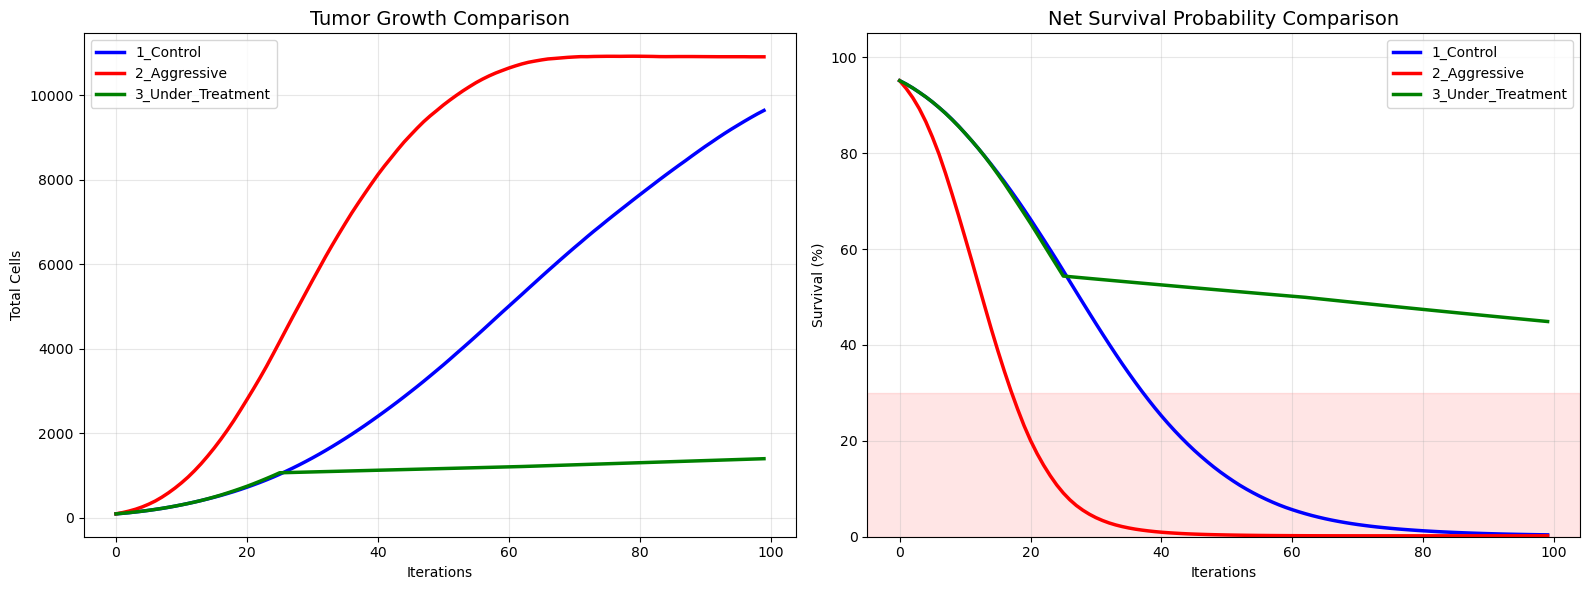

In [16]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# --- GIỮ NGUYÊN CÁC IMPORT VÀ DATA LOADING TỪ CÁC BƯỚC TRƯỚC ---
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import io
import imageio.v2 as imageio
from scipy.ndimage import zoom, binary_erosion, binary_dilation
import plotly.graph_objects as go
from pathlib import Path
import matplotlib.gridspec as gridspec

# --- CẤU HÌNH ---
BASE_CONFIG = {
    'grid_size': 80,
    'num_iterations': 100,
    'neighborhood_26': True,
    'gif_interval': 2, # Lưu frame thường xuyên hơn để biểu đồ mượt
}

SCENARIOS = {
    '1_Control': {
        **BASE_CONFIG,
        'alpha': 0.08, 'beta': 0.05, 'mutation_chance': 0.002, 'necrosis_chance': 0.015,
        'color': 'blue', 'desc': 'Phát triển tự nhiên'
    },
    '2_Aggressive': {
        **BASE_CONFIG,
        'alpha': 0.18, 'beta': 0.20, 'mutation_chance': 0.05, 'necrosis_chance': 0.05,
        'color': 'red', 'desc': 'Ác tính cao'
    },
    '3_Under_Treatment': {
        **BASE_CONFIG,
        'alpha': 0.08, 'beta': 0.05, 'mutation_chance': 0.002, 'necrosis_chance': 0.015,
        'treatment_start': 25,
        'treatment_effect': {'alpha': 0.005, 'necrosis_chance': 0.30},
        'color': 'green', 'desc': 'Có điều trị (từ iter 25)'
    }
}

# --- CLASS MÔ PHỎNG NÂNG CAO (VISUALIZATION DASHBOARD) ---

class MLPA3DWithStats(MLPA3DRealSpace): # Kế thừa class cơ bản
    def __init__(self, config, scenario_name, output_dir):
        super().__init__(config)
        self.scenario_name = scenario_name
        self.output_dir = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        # Kho chứa dữ liệu thống kê
        self.stats = {
            'iterations': [],
            'total_cells': [],
            'malignant_cells': [],
            'survival_prob': []
        }
        self.vol_lung_voxels = 0 # Tổng thể tích phổi (để tính burden)

    def calculate_net_survival(self, current_tumor_vol):
        """
        Ước tính Net Survival dựa trên Tumor Burden (Gánh nặng khối u).
        Công thức giả định: Survival giảm theo hàm mũ của tỷ lệ khối u/phổi.
        """
        if self.vol_lung_voxels == 0: return 100.0
        # Tỷ lệ phần trăm phổi bị chiếm đóng
        burden = current_tumor_vol / self.vol_lung_voxels
        
        # Hệ số nhạy cảm (k): Burden 10% -> Survival giảm mạnh
        k = 15.0 
        survival = 100.0 * np.exp(-k * burden)
        return max(0.0, min(100.0, survival))

    def capture_dashboard_frame(self, grid, iteration):
        """
        Vẽ Frame Dashboard:
        - Trái: 3D Tumor View
        - Phải trên: Growth Curve
        - Phải dưới: Survival Curve
        """
        # Tạo khung hình chữ nhật rộng (1400x700 px)
        fig = plt.figure(figsize=(14, 7), dpi=80)
        gs = gridspec.GridSpec(2, 2, width_ratios=[1.5, 1]) # Cột trái to hơn cột phải
        
        # --- 1. VÙNG 3D (BÊN TRÁI, CHIẾM 2 HÀNG) ---
        ax3d = fig.add_subplot(gs[:, 0], projection='3d')
        
        # Vẽ Phổi (Background)
        if self.lung_surface_mm is not None:
            ax3d.scatter(self.lung_surface_mm[:,2], self.lung_surface_mm[:,1], self.lung_surface_mm[:,0],
                         c='teal', s=1, alpha=0.06, marker='.', label='Lung')

        # Vẽ Khối u (Downsampled)
        def plot_cloud(state, color, alpha, size):
            coords = np.argwhere(grid == state)
            if len(coords) > 0:
                mm = self.transform.grid_to_mm(coords)
                mm = mm[::max(1, len(mm)//1000)] # Downsample
                ax3d.scatter(mm[:,2], mm[:,1], mm[:,0], c=color, s=size, alpha=alpha, depthshade=True)
        
        plot_cloud(2, 'blue', 0.5, 4)   # Tumor
        plot_cloud(4, 'red', 0.9, 8)    # Proliferating
        plot_cloud(6, 'purple', 0.8, 6) # Malignant
        plot_cloud(3, 'black', 0.3, 4)  # Necrotic

        ax3d.set_title(f"SCENARIO: {self.scenario_name}\nIteration: {iteration}", fontsize=14, fontweight='bold')
        ax3d.view_init(elev=20, azim=30 + iteration) # Xoay nhẹ
        if self.plot_limits: # Cố định khung hình
            ax3d.set_xlim(self.plot_limits['x']); ax3d.set_ylim(self.plot_limits['y']); ax3d.set_zlim(self.plot_limits['z'])
        ax3d.axis('off') # Tắt trục toạ độ cho sạch

        # --- 2. BIỂU ĐỒ GROWTH (BÊN PHẢI TRÊN) ---
        ax_growth = fig.add_subplot(gs[0, 1])
        ax_growth.plot(self.stats['iterations'], self.stats['total_cells'], 'b-', lw=2, label='Total Tumor')
        ax_growth.plot(self.stats['iterations'], self.stats['malignant_cells'], 'm--', lw=1.5, label='Malignant')
        
        ax_growth.set_xlim(0, self.cfg['num_iterations'])
        # Y-limit dynamic nhưng không bị giật (tăng dần)
        current_max = max(self.stats['total_cells']) if self.stats['total_cells'] else 100
        ax_growth.set_ylim(0, current_max * 1.2) 
        
        ax_growth.set_ylabel('Cell Count')
        ax_growth.set_title('Tumor Growth Over Time', fontsize=10)
        ax_growth.grid(True, alpha=0.3)
        ax_growth.legend(loc='upper left', fontsize=8)
        
        # Vẽ vạch Treatment nếu có
        if 'treatment_start' in self.cfg:
            ax_growth.axvline(x=self.cfg['treatment_start'], color='green', linestyle=':', label='Treatment Start')

        # --- 3. BIỂU ĐỒ SURVIVAL (BÊN PHẢI DƯỚI) ---
        ax_surv = fig.add_subplot(gs[1, 1])
        ax_surv.plot(self.stats['iterations'], self.stats['survival_prob'], 'g-', lw=2, label='Net Survival')
        
        ax_surv.set_xlim(0, self.cfg['num_iterations'])
        ax_surv.set_ylim(0, 105)
        ax_surv.set_xlabel('Iteration (Time)')
        ax_surv.set_ylabel('Prob. (%)')
        ax_surv.set_title('Estimated Net Survival Probability', fontsize=10)
        ax_surv.grid(True, alpha=0.3)
        
        # Fill màu đỏ dưới đường survival để cảnh báo
        ax_surv.fill_between(self.stats['iterations'], 0, self.stats['survival_prob'], color='green', alpha=0.1)

        # --- LƯU FRAME ---
        plt.tight_layout()
        buf = io.BytesIO()
        plt.savefig(buf, format='png') # Kích thước cố định theo figsize
        buf.seek(0)
        self.frames.append(imageio.imread(buf))
        plt.close(fig)
        buf.close()

    def run_scenario(self, lung_mask, tumor_mask, ct_volume, spacing, origin, patient_id):
        print(f"\n📈 KỊCH BẢN: {self.scenario_name}")
        
        # 1. Khởi tạo dữ liệu (Init Visualization Data)
        self.transform = RealSpaceTransform(spacing, origin, lung_mask.shape, self.grid_size)
        lung_grid = self.resample(lung_mask, lung_mask.shape)
        tumor_grid = self.resample(tumor_mask, tumor_mask.shape) & lung_grid
        self.prepare_visualization_data(lung_grid)
        self.vol_lung_voxels = np.sum(lung_grid) # Lấy thể tích phổi để tính Survival
        
        # 2. Khởi tạo Grid trạng thái
        grid = np.zeros_like(lung_grid, dtype=np.int8)
        grid[lung_grid] = 1        # 1: Phổi lành
        grid[tumor_grid] = 2       # 2: Tumor gốc
        
        # 3. Khởi tạo Môi trường (Microenvironment)
        scale = np.array([self.grid_size]*3) / np.array(ct_volume.shape)
        microenv = np.clip((zoom(ct_volume, scale, order=1) + 1000) / 1400, 0, 1)

        # 4. Cấu hình Snapshots
        snapshots = {}
        total_iters = self.cfg['num_iterations']
        checkpoints = [0, total_iters // 2, total_iters - 1]

        # --- VÒNG LẶP CHÍNH (MAIN LOOP) ---
        for it in range(total_iters):
            
            # A. Thu thập thống kê (Statistics)
            current_total = np.sum((grid == 2) | (grid == 4) | (grid == 6))
            current_malignant = np.sum(grid == 6)
            current_survival = self.calculate_net_survival(current_total)
            
            self.stats['iterations'].append(it)
            self.stats['total_cells'].append(current_total)
            self.stats['malignant_cells'].append(current_malignant)
            self.stats['survival_prob'].append(current_survival)
            
            # B. Logic Điều trị (Treatment)
            if 'treatment_start' in self.cfg and it == self.cfg['treatment_start']:
                print(f"   ⚠️ STARTING TREATMENT at Iter {it}")
                eff = self.cfg['treatment_effect']
                if 'alpha' in eff: self.cfg['alpha'] = eff['alpha']
                if 'necrosis_chance' in eff: self.cfg['necrosis_chance'] = eff['necrosis_chance']

            # C. Logic MLPA (Mô phỏng phát triển)
            # Tìm biên giới: Chỉ nơi có Phổi (1) và nằm trong Lung Grid mới được mọc
            tumor_cells = (grid == 2) | (grid == 4) | (grid == 6)
            boundary = binary_dilation(tumor_cells) & (grid == 1) & lung_grid
            
            candidates = np.argwhere(boundary)
            
            # --- [SỬA LỖI VALUE ERROR TẠI ĐÂY] ---
            if len(candidates) > 0:
                # Tính số lượng tế bào sẽ mọc
                n_grow = int(len(candidates) * self.cfg['alpha'])
                
                if n_grow > 0:
                    # Đảm bảo không chọn quá số lượng candidate đang có
                    n_grow = min(n_grow, len(candidates))
                    
                    # Lấy trọng số từ môi trường (CT Density)
                    weights = microenv[tuple(candidates.T)]
                    w_sum = weights.sum()
                    
                    # Xử lý xác suất an toàn
                    if w_sum > 1e-9:
                        p_vals = weights / w_sum
                        # Quan trọng: Chuẩn hóa lại lần nữa để tổng bằng đúng 1.0
                        p_vals = p_vals / p_vals.sum()
                    else:
                        # Nếu trọng số không hợp lệ (ví dụ vùng không khí), dùng xác suất đều
                        p_vals = None 
                    
                    # Chọn ngẫu nhiên không lặp lại (replace=False)
                    indices = np.random.choice(len(candidates), size=n_grow, p=p_vals, replace=False)
                    
                    for idx in indices: 
                        grid[tuple(candidates[idx])] = 4 # Chuyển thành tế bào sinh sản
            # -------------------------------------
            
            # Cập nhật trạng thái (State Update)
            # 1. Proliferating (4) -> Tumor Core (2)
            mask_4 = (grid == 4)
            grid[mask_4 & (np.random.rand(*grid.shape) < 0.2)] = 2
            
            # 2. Mutation: Tumor (2) -> Malignant (6)
            mask_2 = (grid == 2)
            grid[mask_2 & (np.random.rand(*grid.shape) < self.cfg['mutation_chance'])] = 6
            
            # 3. Necrosis: Chết hoại tử ở tâm (chỉ xảy ra sau iter 15)
            if it > 15:
                eroded = binary_erosion(tumor_cells, iterations=2)
                # Tỷ lệ hoại tử phụ thuộc vào config (có thể tăng cao nếu đang điều trị)
                grid[eroded & (grid == 2) & (np.random.rand(*grid.shape) < self.cfg['necrosis_chance'])] = 3
            
            # D. Ràng buộc biên (Constraint Enforce)
            grid[~lung_grid] = 0

            # E. Lưu Snapshots (Lưu lại grid để vẽ sau)
            if it in checkpoints:
                snapshots[it] = grid.copy()

            # F. Chụp ảnh Dashboard cho GIF
            if (it) % self.cfg['gif_interval'] == 0: 
                self.capture_dashboard_frame(grid, it)

        # Lưu GIF sau khi chạy xong
        gif_path = self.output_dir / f"{patient_id}_{self.scenario_name}_dashboard.gif"
        if self.frames:
            # Clear frames cũ để tránh bị dính frame của scenario trước
            imageio.mimsave(gif_path, self.frames, fps=5, loop=0)
            print(f"   🎬 Saved Dashboard GIF: {gif_path.name}")
            self.frames = [] # Reset list frames cho lần chạy sau
            
        return self.stats, snapshots

    def save_snapshot_image(self, grid, iteration, label):
        """Hàm lưu ảnh tĩnh chất lượng cao (Re-render)"""
        fig = plt.figure(figsize=(10, 10), dpi=100)
        ax = fig.add_subplot(111, projection='3d')
        if self.lung_surface_mm is not None:
            ax.scatter(self.lung_surface_mm[:,2], self.lung_surface_mm[:,1], self.lung_surface_mm[:,0], c='teal', s=1.5, alpha=0.08, marker='.')
        
        def plot_pts(s, c, a, sz):
            coord = np.argwhere(grid == s)
            if len(coord) > 0:
                mm = self.transform.grid_to_mm(coord); mm=mm[::max(1, len(mm)//1500)]
                ax.scatter(mm[:,2], mm[:,1], mm[:,0], c=c, s=sz, alpha=a)
        
        plot_pts(2,'blue',0.6,5); plot_pts(4,'red',1,10); plot_pts(6,'purple',0.9,8); plot_pts(3,'black',0.3,5)
        
        ax.set_title(f"{self.scenario_name} - {label}", fontsize=15)
        ax.view_init(25, 45); ax.axis('off')
        if self.plot_limits: ax.set_xlim(self.plot_limits['x']); ax.set_ylim(self.plot_limits['y']); ax.set_zlim(self.plot_limits['z'])
        
        plt.tight_layout()
        path = self.output_dir / f"{self.scenario_name}_snapshot_{label}.png"
        plt.savefig(path); plt.close(fig)
        print(f"   📸 Saved snapshot: {label}")

# --- COMPARISON PLOT FUNCTION ---

def plot_final_comparison(all_stats, output_dir):
    """Vẽ biểu đồ so sánh 3 kịch bản trên cùng 1 hình"""
    print("\n📊 Creating Final Comparison Report...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Growth Comparison
    for name, stats in all_stats.items():
        cfg = SCENARIOS[name]
        ax1.plot(stats['iterations'], stats['total_cells'], linewidth=2.5, 
                 color=cfg.get('color', 'black'), label=f"{name}")
        
    ax1.set_title("Tumor Growth Comparison", fontsize=14)
    ax1.set_xlabel("Iterations"); ax1.set_ylabel("Total Cells")
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    # 2. Survival Comparison
    for name, stats in all_stats.items():
        cfg = SCENARIOS[name]
        ax2.plot(stats['iterations'], stats['survival_prob'], linewidth=2.5,
                 color=cfg.get('color', 'black'), label=f"{name}")
        
    ax2.set_title("Net Survival Probability Comparison", fontsize=14)
    ax2.set_xlabel("Iterations"); ax2.set_ylabel("Survival (%)")
    ax2.set_ylim(0, 105)
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    # Đánh dấu vùng nguy hiểm
    ax2.axhspan(0, 30, color='red', alpha=0.1, label='Critical Zone')
    
    plt.tight_layout()
    path = output_dir / "FINAL_COMPARISON_REPORT.png"
    plt.savefig(path, dpi=150)
    print(f"✅ Report saved: {path}")
    plt.show()

# --- MAIN EXECUTION ---

if __name__ == "__main__":
    OUTPUT_DIR = Path("./lung1_scenarios_stats")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # 1. Load Data
    patients = scan_lung1_patients(LUNG1_ROOT, max_patients=5)
    p = patients[0] if not SELECTED_PATIENT_ID else next(x for x in patients if x['patient_id'] == SELECTED_PATIENT_ID)
    ct_vol, spacing, origin, ct_slices = load_ct_volume(p['ct_dir'])
    tumor_mask, lung_mask = load_masks_from_dicom_seg(p['seg_file'], ct_slices)
    
    all_scenario_stats = {}

    # 2. Run Scenarios
    for name, config in SCENARIOS.items():
        sim = MLPA3DWithStats(config, name, OUTPUT_DIR)
        stats, snapshots = sim.run_scenario(lung_mask, tumor_mask, ct_vol, spacing, origin, p['patient_id'])
        
        all_scenario_stats[name] = stats
        
        # Save high-res snapshots
        sim.save_snapshot_image(snapshots[0], 0, "Start")
        sim.save_snapshot_image(snapshots[config['num_iterations']//2], config['num_iterations']//2, "Middle")
        sim.save_snapshot_image(snapshots[config['num_iterations']-1], config['num_iterations']-1, "End")

    # 3. Final Report
    plot_final_comparison(all_scenario_stats, OUTPUT_DIR)

🎬 Đang tải và hiển thị so sánh 3 kịch bản cho bệnh nhân: LUNG1-001...



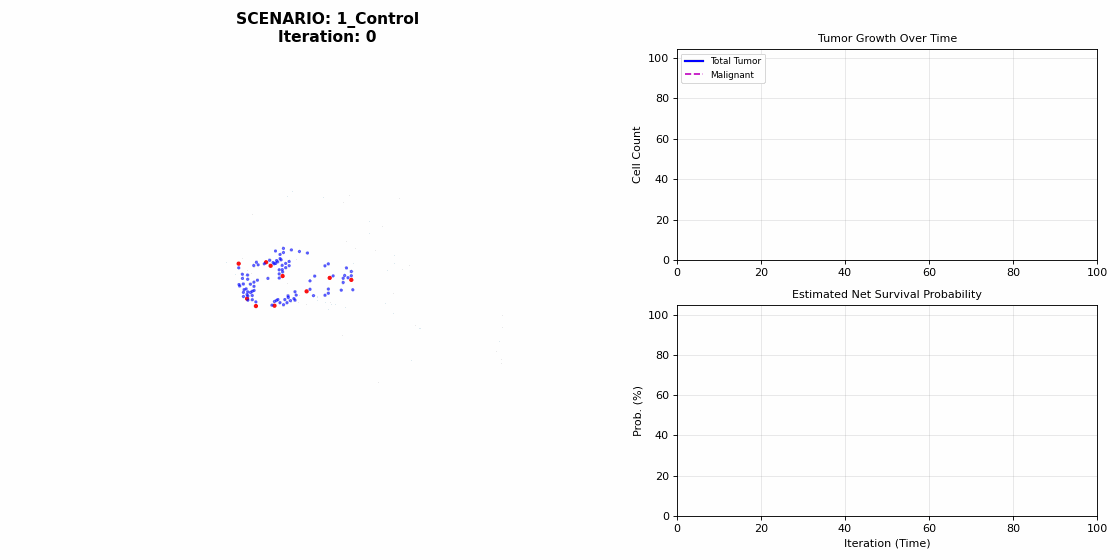
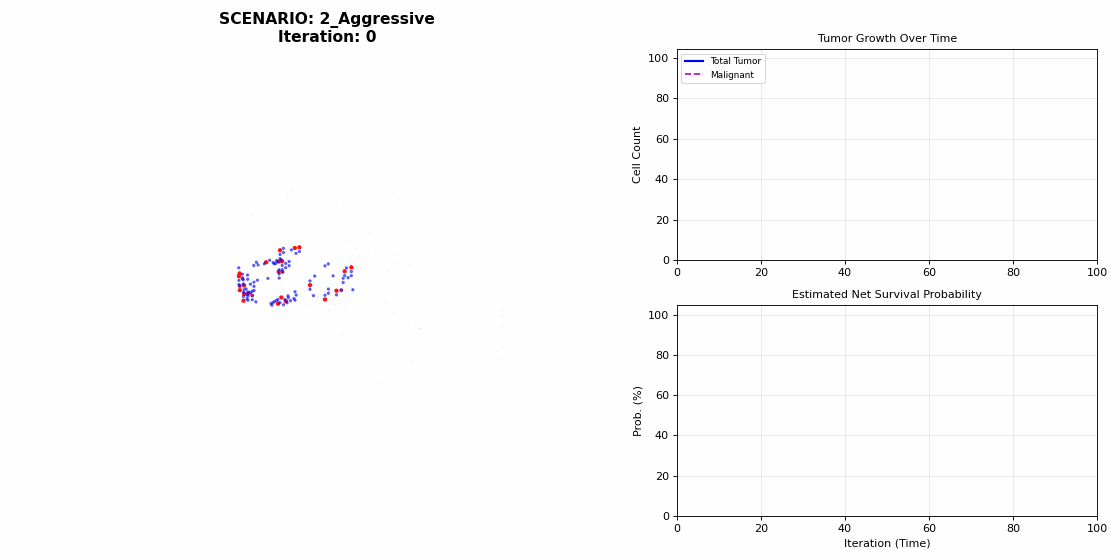
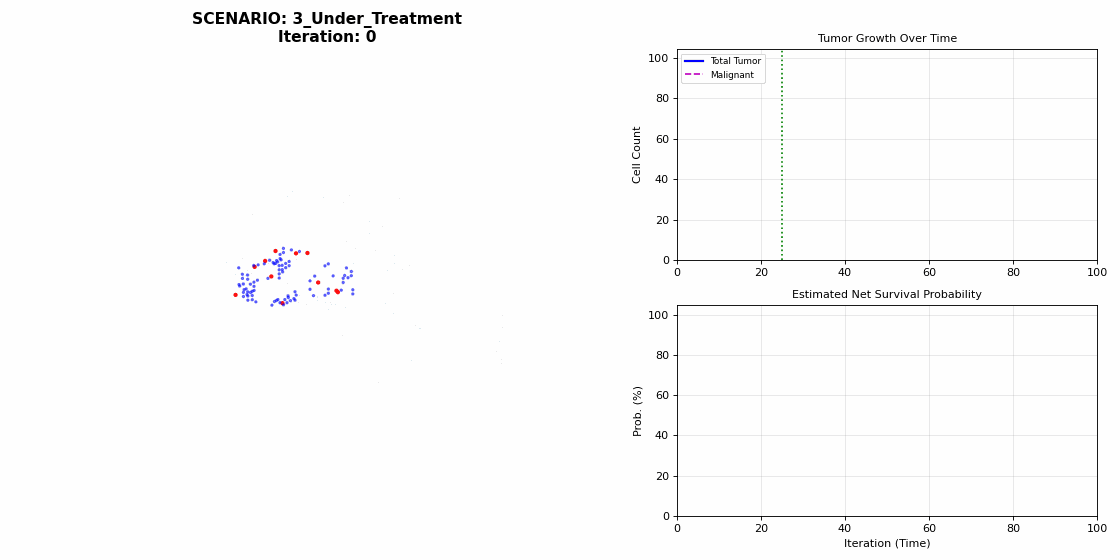

In [17]:
import base64
from IPython.display import HTML, display
from pathlib import Path

def display_three_scenarios_side_by_side(patient_id, output_dir):
    """
    Hiển thị 3 file GIF cạnh nhau sử dụng HTML Flexbox và Base64.
    """
    scenarios = [
        ("1_Control", "Phát triển tự nhiên"),
        ("2_Aggressive", "Ác tính cao"),
        ("3_Under_Treatment", "Có điều trị")
    ]
    
    html_code = """
    <style>
        .gif-container {
            display: flex;
            flex-direction: row;
            justify-content: space-between;
            width: 100%;
            overflow-x: auto;
        }
        .gif-box {
            flex: 1;
            margin: 5px;
            text-align: center;
            border: 1px solid #ddd;
            border-radius: 5px;
            padding: 5px;
            background-color: #f9f9f9;
            min-width: 300px; /* Đảm bảo không bị co quá nhỏ */
        }
        .gif-box h3 {
            margin: 5px 0;
            font-size: 16px;
            color: #333;
        }
        .gif-box img {
            width: 100%;
            height: auto;
            border-radius: 3px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }
    </style>
    <div class="gif-container">
    """
    
    print(f"🎬 Đang tải và hiển thị so sánh 3 kịch bản cho bệnh nhân: {patient_id}...")
    
    found_any = False
    
    for sc_key, sc_name in scenarios:
        filename = f"{patient_id}_{sc_key}_dashboard.gif"
        file_path = output_dir / filename
        
        if file_path.exists():
            found_any = True
            # Đọc file và mã hóa Base64
            with open(file_path, "rb") as f:
                b64_data = base64.b64encode(f.read()).decode("utf-8")
                
            html_code += f"""
            <div class="gif-box">
                <h3>{sc_key}<br><small>{sc_name}</small></h3>
                <img src="data:image/gif;base64,{b64_data}" alt="{sc_name}">
            </div>
            """
        else:
            html_code += f"""
            <div class="gif-box">
                <h3>{sc_key}</h3>
                <p style="color:red; padding: 50px 0;">Không tìm thấy file:<br>{filename}</p>
            </div>
            """
            
    html_code += "</div>"
    
    if found_any:
        display(HTML(html_code))
    else:
        print("⚠️ Không tìm thấy file GIF nào trong thư mục output.")

# --- GỌI HÀM HIỂN THỊ ---
# Đảm bảo bạn truyền đúng biến patient_id và OUTPUT_DIR đã dùng ở bước trước
display_three_scenarios_side_by_side(p['patient_id'], OUTPUT_DIR)


🔬 DIGITAL TWIN SURVIVAL ANALYSIS PIPELINE
🧹 Đang xử lý dữ liệu lâm sàng từ: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   -> Điền tuổi thiếu cho 22 bệnh nhân (Median = 68.6)
✅ Dữ liệu lâm sàng sạch: 422 bệnh nhân.

🔄 Bắt đầu chạy mô phỏng cho 15 bệnh nhân...
   [15/15] Simulating LUNG1-015...
✅ Đã mô phỏng thành công 15 bệnh nhân.

📊 Dữ liệu cuối cùng để chạy Cox Model (15 samples):
           time  event      age  Sim_Growth_Rate  Sim_Necrosis_Ratio  \
PatientID                                                              
LUNG1-001  2165      1  78.7515           143.54            0.053781   
LUNG1-002   155      1  83.8001           238.30            0.049096   
LUNG1-003   256      1  68.1807           215.26            0.044579   
LUNG1-004   141      1  70.8802           195.42            0.043888   
LUNG1-005   353      1  80.4819           243.96            0.049289   

           Sim_Prolif_Ratio  Sim_Final_Volume  
PatientID                                   

<lifelines.CoxPHFitter: fitted with 15 total observations, 1 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 15
number of events observed = 14
   partial log-likelihood = -23.15
         time fit was run = 2025-12-09 22:08:16 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Sim_Growth_Rate      0.03      1.03      0.02            0.00            0.07                1.00                1.07
Sim_Necrosis_Ratio -27.17      0.00    211.25         -441.20          386.87                0.00           1.04e+168
Sim_Prolif_Ratio   118.69  3.53e+51    107.10          -91.22          328.61                0.00           5.19e+142

                    cmp to     z    p  -log2(p)
covariate                                      
Sim_Growth_Rate       0.00  2.12 0.03      4.90
Sim_Necrosis_Ratio    0.00 -0.13 0.90      0.16
Sim_Prolif_Ratio      0.00  1.11 0.27      1.90
---
Concordance = 0.72
Partial AIC = 52.31
log-likelihood ratio test = 7.30 on 3 df
-log2(p) of ll-ratio test = 3.99


⭐ C-Index (Độ chính xác tiên lượng): 0.7184


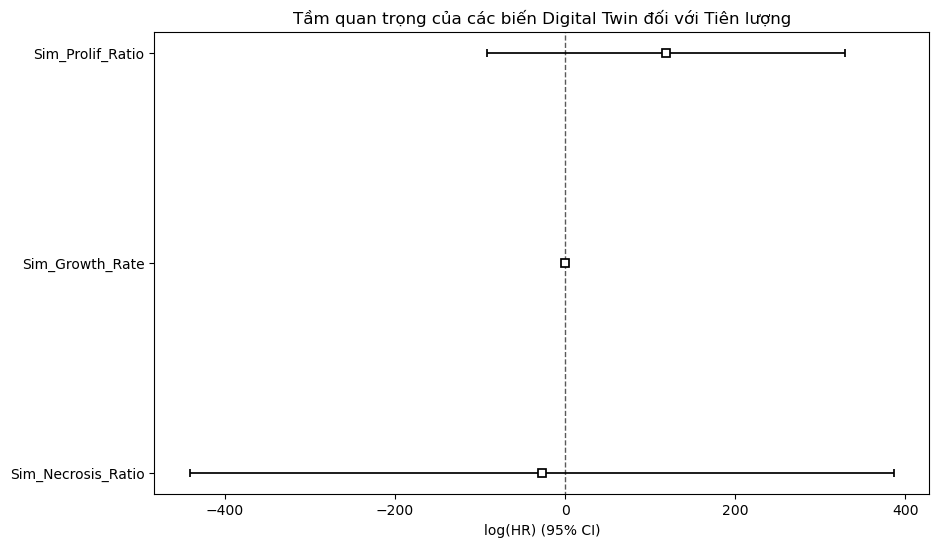

In [18]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
DIGITAL TWIN SURVIVAL ANALYSIS
================================================================================
Quy trình:
1. Load & Clean Clinical Data (Xử lý thiếu tuổi, stage...).
2. Batch Simulation (Chạy MLPA trên danh sách bệnh nhân).
3. Extract Bio-Features (Growth Rate, Necrosis Ratio...).
4. Cox Regression (Dự đoán sống sót chỉ dùng Bio-Features).

Author: Paul Nguyen
"""

import numpy as np
import pandas as pd
import pydicom
from pathlib import Path
from scipy.ndimage import zoom, binary_erosion, binary_dilation
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ============================================================================
# CẤU HÌNH
# ============================================================================
LUNG1_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")
CLINICAL_FILE = Path("./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv")
MAX_PATIENTS = None  # Số lượng bệnh nhân chạy demo (Tăng lên nếu máy mạnh)

MLPA_CONFIG = {
    'grid_size': 60,            # Grid nhỏ hơn chút để chạy batch cho nhanh
    'num_iterations': 50,       
    'alpha': 0.08,              
    'beta': 0.05,               
    'mutation_chance': 0.002,   
    'necrosis_chance': 0.02,
    'neighborhood_26': True, 
}

# ============================================================================
# 1. CLINICAL DATA PREPROCESSING (KẾ HOẠCH ĐÃ DUYỆT)
# ============================================================================

def load_and_clean_clinical_data(csv_path):
    print(f"🧹 Đang xử lý dữ liệu lâm sàng từ: {csv_path}")
    
    # 1. Load CSV
    df = pd.read_csv(csv_path)
    
    # Chuẩn hóa tên cột (loại bỏ khoảng trắng, chữ hoa)
    df.columns = [c.strip() for c in df.columns]
    
    # Tìm các cột quan trọng (Mapping tên cột có thể thay đổi tùy version file)
    col_map = {
        'PatientID': 'PatientID',
        'age': 'age',
        'overall_stage': 'stage', # Hoặc Overall Stage
        'Survival.time': 'time',
        'deadstatus.event': 'event'
    }
    
    # Đổi tên cột cho chuẩn
    df = df.rename(columns=col_map)
    df['PatientID'] = df['PatientID'].astype(str)
    
    # 2. Xử lý Survival Targets
    # Chuyển time sang số, loại bỏ NaN hoặc <= 0
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df = df[df['time'] > 0]
    
    # Chuyển event sang 0/1 (Giả sử 1=Dead)
    # Kiểm tra dữ liệu thực tế xem là 0/1 hay chuỗi
    if df['event'].dtype == object:
        df['event'] = df['event'].map({'Dead': 1, 'Alive': 0, '1': 1, '0': 0})
    df['event'] = pd.to_numeric(df['event'], errors='coerce').fillna(0).astype(int)
    
    # 3. Imputation Strategy (Điền dữ liệu thiếu)
    
    # --- AGE (Median Imputation) ---
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    median_age = df['age'].median()
    missing_age_count = df['age'].isna().sum()
    df['age'].fillna(median_age, inplace=True)
    print(f"   -> Điền tuổi thiếu cho {missing_age_count} bệnh nhân (Median = {median_age:.1f})")
    
    # --- STAGE (Mapping & Mode Imputation) ---
    # Map về dạng số: I->1, II->2, III->3
    stage_map = {
        'I': 1, 'Ia': 1, 'Ib': 1, 'IA': 1, 'IB': 1,
        'II': 2, 'IIa': 2, 'IIb': 2, 'IIA': 2, 'IIB': 2,
        'III': 3, 'IIIa': 3, 'IIIb': 3, 'IIIA': 3, 'IIIB': 3,
        'IV': 4
    }
    if 'stage' in df.columns:
        df['stage'] = df['stage'].astype(str).map(stage_map)
        mode_stage = df['stage'].mode()[0]
        missing_stage_count = df['stage'].isna().sum()
        df['stage'].fillna(mode_stage, inplace=True)
        print(f"   -> Điền giai đoạn thiếu cho {missing_stage_count} bệnh nhân (Mode = {mode_stage})")
    
    # Set Index
    df = df.set_index('PatientID')
    
    print(f"✅ Dữ liệu lâm sàng sạch: {len(df)} bệnh nhân.")
    return df[['time', 'event', 'age']] # Chỉ giữ lại cột cần thiết

# ============================================================================
# 2. DIGITAL TWIN ENGINE (SIMPLIFIED FOR BATCH)
# ============================================================================

def load_patient_data(patient_id, data_root):
    # Tìm thư mục bệnh nhân
    p_dir = data_root / patient_id
    if not p_dir.exists(): return None
    
    # Scan tìm CT và SEG
    ct_dirs = []
    seg_file = None
    
    for study in p_dir.glob("*"):
        if not study.is_dir(): continue
        for subdir in study.iterdir():
            if subdir.is_dir():
                # Check for Seg
                if subdir.name.startswith("300."): 
                    segs = list(subdir.glob("*.dcm"))
                    if segs: seg_file = segs[0]
                # Check for CT
                else:
                    dcm_count = len(list(subdir.glob("*.dcm")))
                    if dcm_count > 10: ct_dirs.append((subdir, dcm_count))
    
    if not ct_dirs or not seg_file: return None
    
    ct_dir = max(ct_dirs, key=lambda x: x[1])[0]
    
    # Load CT
    slices = [pydicom.dcmread(str(f)) for f in sorted(ct_dir.glob("*.dcm"))]
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    volume = np.stack([s.pixel_array for s in slices])
    slope = float(getattr(slices[0], 'RescaleSlope', 1))
    intercept = float(getattr(slices[0], 'RescaleIntercept', 0))
    volume = volume * slope + intercept
    
    # Load Mask (Simplified logic for batch)
    seg_ds = pydicom.dcmread(str(seg_file))
    sop_to_z = {ds.SOPInstanceUID: idx for idx, ds in enumerate(slices)}
    mask = np.zeros_like(volume, dtype=np.uint8)
    
    # Quick extraction of segment 1 (Tumor)
    frames = seg_ds.pixel_array
    if frames.ndim == 2: frames = frames[np.newaxis, ...]
    
    if hasattr(seg_ds, 'PerFrameFunctionalGroupsSequence'):
        for i, meta in enumerate(seg_ds.PerFrameFunctionalGroupsSequence):
            try:
                seg_num = int(meta.SegmentIdentificationSequence[0].ReferencedSegmentNumber)
                if seg_num != 1: continue # Chỉ lấy Tumor
                ref_uid = meta.DerivationImageSequence[0].SourceImageSequence[0].ReferencedSOPInstanceUID
                if ref_uid in sop_to_z:
                    z = sop_to_z[ref_uid]
                    mask[z] = np.maximum(mask[z], (frames[i]>0).astype(np.uint8))
            except: continue
            
    return volume, mask

class DigitalTwinSimulator:
    def __init__(self, config):
        self.cfg = config
        self.grid_size = config['grid_size']

    def extract_bio_features(self, grid, initial_tumor_cells, num_iters):
        """Trích xuất đặc trưng sinh học từ Digital Twin"""
        total_cells = np.sum((grid == 2) | (grid == 4) | (grid == 6))
        necrotic = np.sum(grid == 3)
        proliferating = np.sum(grid == 4)
        malignant = np.sum(grid == 6)
        
        # 1. Growth Rate: Tốc độ tăng trưởng trung bình (cell/iter)
        growth_rate = (total_cells - initial_tumor_cells) / num_iters
        
        # 2. Necrosis Ratio: Tỷ lệ hoại tử (Chỉ số ác tính/thiếu oxy)
        necrosis_ratio = necrotic / (total_cells + 1e-9)
        
        # 3. Proliferation Ratio: Tỷ lệ đang sinh sản (Chỉ số hoạt động)
        prolif_ratio = proliferating / (total_cells + 1e-9)
        
        return {
            'Sim_Growth_Rate': growth_rate,
            'Sim_Necrosis_Ratio': necrosis_ratio,
            'Sim_Prolif_Ratio': prolif_ratio,
            'Sim_Final_Volume': total_cells
        }

    def run_simulation(self, ct_volume, tumor_mask):
        # Resample
        scale = np.array([self.grid_size]*3) / np.array(tumor_mask.shape)
        tumor_grid = zoom(tumor_mask.astype(float), scale, order=0) > 0.5
        
        # Microenvironment
        ct_small = zoom(ct_volume, scale, order=1)
        microenv = np.clip((ct_small + 1000) / 1400, 0, 1)
        
        # Init Grid
        grid = np.zeros_like(tumor_grid, dtype=np.int8)
        grid[tumor_grid] = 2
        
        initial_cells = np.sum(grid == 2)
        if initial_cells == 0: return None # Lỗi mask rỗng
        
        # --- FAST MLPA LOOP ---
        for it in range(self.cfg['num_iterations']):
            tumor_cells = (grid == 2) | (grid == 4) | (grid == 6)
            boundary = binary_dilation(tumor_cells) & (grid == 0) # Không có lung mask -> mọc tự do ra ngoài (Simplified)
            
            candidates = np.argwhere(boundary)
            if len(candidates) > 0:
                n_grow = int(len(candidates) * self.cfg['alpha'])
                if n_grow > 0:
                    weights = microenv[tuple(candidates.T)]
                    p_vals = weights / (weights.sum() + 1e-9)
                    p_vals = p_vals / p_vals.sum()
                    indices = np.random.choice(len(candidates), size=n_grow, p=p_vals, replace=False)
                    for idx in indices: grid[tuple(candidates[idx])] = 4
            
            # State Update
            mask_4 = (grid == 4)
            grid[mask_4 & (np.random.rand(*grid.shape) < 0.2)] = 2
            
            mask_2 = (grid == 2)
            grid[mask_2 & (np.random.rand(*grid.shape) < self.cfg['mutation_chance'])] = 6
            
            if it > 10:
                eroded = binary_erosion(tumor_cells, iterations=1)
                grid[eroded & (grid == 2) & (np.random.rand(*grid.shape) < self.cfg['necrosis_chance'])] = 3
                
        return self.extract_bio_features(grid, initial_cells, self.cfg['num_iterations'])

# ============================================================================
# 3. MAIN PIPELINE
# ============================================================================

if __name__ == "__main__":
    print("\n🔬 DIGITAL TWIN SURVIVAL ANALYSIS PIPELINE")
    print("="*60)
    
    # 1. Clean Clinical Data
    clin_df = load_and_clean_clinical_data(CLINICAL_FILE)
    
    # 2. Batch Simulation
    simulator = DigitalTwinSimulator(MLPA_CONFIG)
    results = []
    
    print(f"\n🔄 Bắt đầu chạy mô phỏng cho {MAX_PATIENTS} bệnh nhân...")
    
    count = 0
    for pid in clin_df.index:
        if count >= MAX_PATIENTS: break
        
        # Load Image Data
        data = load_patient_data(pid, LUNG1_ROOT)
        if data is None: continue # Bỏ qua nếu không tìm thấy CT/Seg
        
        vol, mask = data
        
        # Run Simulation
        print(f"   [{count+1}/{MAX_PATIENTS}] Simulating {pid}...", end='\r')
        features = simulator.run_simulation(vol, mask)
        
        if features:
            features['PatientID'] = pid
            results.append(features)
            count += 1
            
    print(f"\n✅ Đã mô phỏng thành công {len(results)} bệnh nhân.")
    
    # 3. Merge & Analyze
    sim_df = pd.DataFrame(results).set_index('PatientID')
    
    # Ghép dữ liệu Mô phỏng với Dữ liệu Lâm sàng (Time, Event)
    final_df = clin_df.join(sim_df, how='inner')
    
    print(f"\n📊 Dữ liệu cuối cùng để chạy Cox Model ({len(final_df)} samples):")
    print(final_df.head())
    
    # 4. Cox Regression
    print("\n🧠 Huấn luyện mô hình Cox (Digital Twin Features Only)...")
    cph = CoxPHFitter()
    
    # Chỉ chọn các cột feature mô phỏng + time + event
    model_cols = ['Sim_Growth_Rate', 'Sim_Necrosis_Ratio', 'Sim_Prolif_Ratio', 'time', 'event']
    
    try:
        cph.fit(final_df[model_cols], duration_col='time', event_col='event')
        
        print("\n--- KẾT QUẢ MÔ HÌNH ---")
        cph.print_summary()
        
        c_index = concordance_index(final_df['time'], -cph.predict_partial_hazard(final_df), final_df['event'])
        print(f"\n⭐ C-Index (Độ chính xác tiên lượng): {c_index:.4f}")
        
        # Vẽ biểu đồ ảnh hưởng của các biến (Coefficients)
        plt.figure(figsize=(10, 6))
        cph.plot()
        plt.title("Tầm quan trọng của các biến Digital Twin đối với Tiên lượng")
        plt.show()
        
    except Exception as e:
        print(f"⚠️ Lỗi khi chạy Cox Model (có thể do dữ liệu quá ít): {e}")


🚀 PARALLEL DIGITAL TWIN SIMULATION (CPUs: -1)
🧹 Đang xử lý dữ liệu lâm sàng...
📊 Tổng số bệnh nhân cần xử lý: 422
🔄 Đang phân phối tác vụ cho các CPU...


Simulating: 100%|██████████| 422/422 [01:27<00:00,  4.85it/s]



✅ HOÀN THÀNH!
   - Thời gian: 1.6 phút
   - Thành công: 419/422

🧠 Huấn luyện mô hình Cox trên 419 bệnh nhân...


<lifelines.CoxPHFitter: fitted with 419 total observations, 48 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 419
number of events observed = 371
   partial log-likelihood = -1948.90
         time fit was run = 2025-12-09 22:24:02 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Sim_Growth_Rate     0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Sim_Necrosis_Ratio  8.72   6121.88     10.06          -11.00           28.44                0.00            2.25e+12
Sim_Prolif_Ratio   -0.14      0.87      2.62           -5.27            4.98                0.01              145.65
age                 0.02      1.02      0.01            0.01            0.03                1.01                1.03

                    cmp to     z      p  -log2(p)
covariate                                        
Sim_Growth_Rate       0.00  1.42   0.15      2.69
Sim_Necrosis_Ratio    0.00  0.87   0.39      1.37
Sim_Prolif_Ratio      0.00 -0.06   0.96      0.07
age                   0.00  3.10 <0.005      9.00
---
Concordance = 0.57
Partial AIC = 3905.80
log-likelihood ratio test = 16.62 on 4 df
-log2(p) of ll-ratio test = 8.77


⭐ C-Index: 0.5679


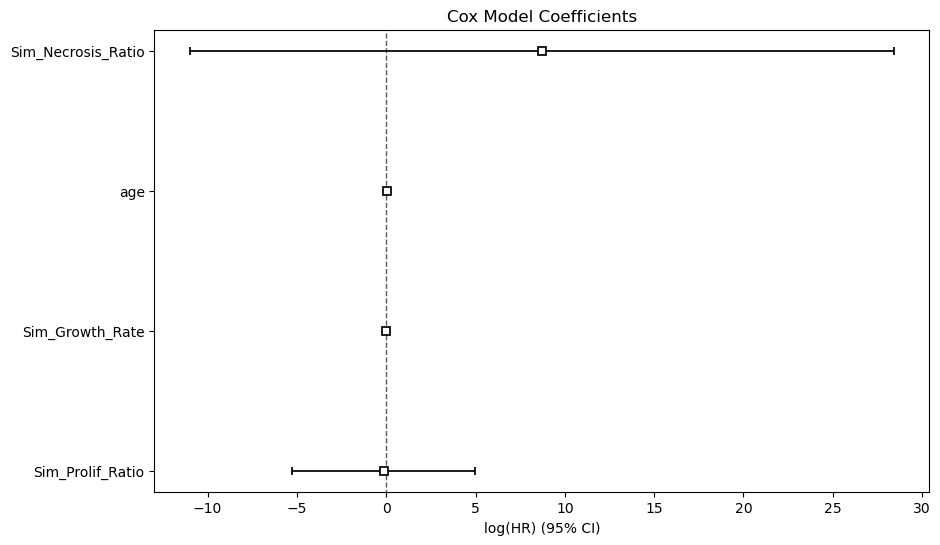

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
DIGITAL TWIN SURVIVAL ANALYSIS - MULTI-CPU PARALLEL VERSION
================================================================================
Cập nhật:
- Sử dụng Joblib để chạy song song trên TẤT CẢ CPU CORES.
- Tốc độ nhanh hơn 5-10 lần so với bản cũ.
- Thêm thanh tiến trình (Progress Bar).

Author: Paul Nguyen
"""

import numpy as np
import pandas as pd
import pydicom
from pathlib import Path
from scipy.ndimage import zoom, binary_erosion, binary_dilation
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
import warnings
import time

# --- THƯ VIỆN ĐA LUỒNG ---
from joblib import Parallel, delayed
from tqdm import tqdm # Thanh tiến trình

warnings.filterwarnings('ignore')

# ============================================================================
# CẤU HÌNH
# ============================================================================
LUNG1_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")
CLINICAL_FILE = Path("./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv")

# SỐ LƯỢNG CPU MUỐN DÙNG
# n_jobs = -1 : Dùng tất cả CPU (Nhanh nhất, máy sẽ full load)
# n_jobs = -2 : Dùng tất cả CPU trừ 1 (Để máy đỡ lag nếu làm việc khác)
# n_jobs = 4  : Chỉ dùng 4 CPU
N_JOBS = -1 

MLPA_CONFIG = {
    'grid_size': 50,
    'num_iterations': 50,       
    'alpha': 0.08,              
    'beta': 0.05,               
    'mutation_chance': 0.002,   
    'necrosis_chance': 0.02,
    'neighborhood_26': True, 
}

# ============================================================================
# 1. HELPER FUNCTIONS (Load Data & Sim Logic)
# ============================================================================
# (Các hàm này cần được định nghĩa global để Multiprocessing gọi được)

def load_patient_data_static(patient_id, data_root):
    """Hàm load dữ liệu tĩnh (được gọi bởi worker)"""
    p_dir = data_root / patient_id
    if not p_dir.exists(): return None
    
    ct_dirs = []
    seg_file = None
    
    for study in p_dir.glob("*"):
        if not study.is_dir(): continue
        for subdir in study.iterdir():
            if subdir.is_dir():
                if subdir.name.startswith("300."): 
                    segs = list(subdir.glob("*.dcm"))
                    if segs: seg_file = segs[0]
                else:
                    dcm_count = len(list(subdir.glob("*.dcm")))
                    if dcm_count > 10: ct_dirs.append((subdir, dcm_count))
    
    if not ct_dirs or not seg_file: return None
    ct_dir = max(ct_dirs, key=lambda x: x[1])[0]
    
    try:
        slices = [pydicom.dcmread(str(f)) for f in sorted(ct_dir.glob("*.dcm"))]
        slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
        volume = np.stack([s.pixel_array for s in slices])
        slope = float(getattr(slices[0], 'RescaleSlope', 1))
        intercept = float(getattr(slices[0], 'RescaleIntercept', 0))
        volume = volume * slope + intercept
        
        seg_ds = pydicom.dcmread(str(seg_file))
        sop_to_z = {ds.SOPInstanceUID: idx for idx, ds in enumerate(slices)}
        mask = np.zeros_like(volume, dtype=np.uint8)
        frames = seg_ds.pixel_array
        if frames.ndim == 2: frames = frames[np.newaxis, ...]
        
        if hasattr(seg_ds, 'PerFrameFunctionalGroupsSequence'):
            for i, meta in enumerate(seg_ds.PerFrameFunctionalGroupsSequence):
                try:
                    seg_num = int(meta.SegmentIdentificationSequence[0].ReferencedSegmentNumber)
                    if seg_num != 1: continue 
                    ref_uid = meta.DerivationImageSequence[0].SourceImageSequence[0].ReferencedSOPInstanceUID
                    if ref_uid in sop_to_z:
                        z = sop_to_z[ref_uid]
                        mask[z] = np.maximum(mask[z], (frames[i]>0).astype(np.uint8))
                except: continue
        
        if np.sum(mask) == 0: return None
        return volume, mask
    except:
        return None

def run_simulation_logic(ct_volume, tumor_mask, config):
    """Logic mô phỏng MLPA thuần túy"""
    # 1. Resample
    scale = np.array([config['grid_size']]*3) / np.array(tumor_mask.shape)
    tumor_grid = zoom(tumor_mask.astype(float), scale, order=0) > 0.5
    
    # 2. Microenvironment
    ct_small = zoom(ct_volume, scale, order=1)
    microenv = np.clip((ct_small + 1000) / 1400, 0, 1)
    
    # 3. Init
    grid = np.zeros_like(tumor_grid, dtype=np.int8)
    grid[tumor_grid] = 2
    initial_cells = np.sum(grid == 2)
    if initial_cells == 0: return None
    
    # 4. Loop
    for it in range(config['num_iterations']):
        tumor_cells = (grid == 2) | (grid == 4) | (grid == 6)
        boundary = binary_dilation(tumor_cells) & (grid == 0)
        
        candidates = np.argwhere(boundary)
        if len(candidates) > 0:
            n_grow = int(len(candidates) * config['alpha'])
            if n_grow > 0:
                n_grow = min(n_grow, len(candidates))
                weights = microenv[tuple(candidates.T)]
                p_vals = weights / (weights.sum() + 1e-9)
                p_vals = p_vals / p_vals.sum()
                indices = np.random.choice(len(candidates), size=n_grow, p=p_vals, replace=False)
                for idx in indices: grid[tuple(candidates[idx])] = 4
        
        mask_4 = (grid == 4)
        grid[mask_4 & (np.random.rand(*grid.shape) < 0.2)] = 2
        mask_2 = (grid == 2)
        grid[mask_2 & (np.random.rand(*grid.shape) < config['mutation_chance'])] = 6
        
        if it > 10:
            eroded = binary_erosion(tumor_cells, iterations=1)
            grid[eroded & (grid == 2) & (np.random.rand(*grid.shape) < config['necrosis_chance'])] = 3
            
    # 5. Extract Features
    total = np.sum((grid == 2) | (grid == 4) | (grid == 6))
    return {
        'Sim_Growth_Rate': (total - initial_cells) / config['num_iterations'],
        'Sim_Necrosis_Ratio': np.sum(grid == 3) / (total + 1e-9),
        'Sim_Prolif_Ratio': np.sum(grid == 4) / (total + 1e-9)
    }

# ============================================================================
# 2. WORKER FUNCTION (Hàm này sẽ chạy trên từng CPU core)
# ============================================================================

def process_single_patient(patient_id, root_dir, config):
    """
    Hàm xử lý trọn gói cho 1 bệnh nhân:
    Load -> Sim -> Return Features
    """
    try:
        # Load
        data = load_patient_data_static(patient_id, root_dir)
        if data is None: return None
        vol, mask = data
        
        # Sim
        feats = run_simulation_logic(vol, mask, config)
        if feats:
            feats['PatientID'] = patient_id
            return feats
        return None
    except Exception:
        return None

# ============================================================================
# 3. CLINICAL DATA CLEANING (Giữ nguyên)
# ============================================================================
def load_and_clean_clinical_data(csv_path):
    print(f"🧹 Đang xử lý dữ liệu lâm sàng...")
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    col_map = {'PatientID': 'PatientID', 'age': 'age', 'overall_stage': 'stage', 'Survival.time': 'time', 'deadstatus.event': 'event'}
    df = df.rename(columns=col_map)
    df['PatientID'] = df['PatientID'].astype(str)
    df['time'] = pd.to_numeric(df['time'], errors='coerce'); df = df[df['time'] > 0]
    if df['event'].dtype == object: df['event'] = df['event'].map({'Dead': 1, 'Alive': 0, '1': 1, '0': 0})
    df['event'] = pd.to_numeric(df['event'], errors='coerce').fillna(0).astype(int)
    df['age'] = pd.to_numeric(df['age'], errors='coerce'); df['age'].fillna(df['age'].median(), inplace=True)
    df = df.set_index('PatientID')
    return df[['time', 'event', 'age']]

# ============================================================================
# 4. MAIN PIPELINE (PARALLEL EXECUTION)
# ============================================================================

if __name__ == "__main__":
    print(f"\n🚀 PARALLEL DIGITAL TWIN SIMULATION (CPUs: {N_JOBS})")
    print("="*60)
    
    # 1. Load Clinical Data
    clin_df = load_and_clean_clinical_data(CLINICAL_FILE)
    patient_list = clin_df.index.tolist()
    
    print(f"📊 Tổng số bệnh nhân cần xử lý: {len(patient_list)}")
    print(f"🔄 Đang phân phối tác vụ cho các CPU...")
    
    start_time = time.time()
    
    # --- PARALLEL EXECUTION START ---
    # joblib.Parallel sẽ tự động chia việc
    results = Parallel(n_jobs=N_JOBS)(
        delayed(process_single_patient)(pid, LUNG1_ROOT, MLPA_CONFIG) 
        for pid in tqdm(patient_list, desc="Simulating")
    )
    # --- PARALLEL EXECUTION END ---
    
    # Lọc bỏ các kết quả None (bệnh nhân lỗi)
    valid_results = [r for r in results if r is not None]
    
    total_time = time.time() - start_time
    print(f"\n✅ HOÀN THÀNH!")
    print(f"   - Thời gian: {total_time/60:.1f} phút")
    print(f"   - Thành công: {len(valid_results)}/{len(patient_list)}")
    
    # 2. Cox Analysis
    if len(valid_results) > 5:
        sim_df = pd.DataFrame(valid_results).set_index('PatientID')
        final_df = clin_df.join(sim_df, how='inner')
        
        print(f"\n🧠 Huấn luyện mô hình Cox trên {len(final_df)} bệnh nhân...")
        cph = CoxPHFitter()
        model_cols = ['Sim_Growth_Rate', 'Sim_Necrosis_Ratio', 'Sim_Prolif_Ratio', 'age', 'time', 'event']
        
        try:
            cph.fit(final_df[model_cols], duration_col='time', event_col='event')
            cph.print_summary()
            
            c = concordance_index(final_df['time'], -cph.predict_partial_hazard(final_df), final_df['event'])
            print(f"\n⭐ C-Index: {c:.4f}")
            
            plt.figure(figsize=(10, 6))
            cph.plot()
            plt.title("Cox Model Coefficients")
            plt.show()
        except Exception as e:
            print(f"Error in Cox: {e}")
    else:
        print("⚠️ Không đủ dữ liệu thành công để chạy mô hình.")